**Table of contents**<a id='toc0_'></a>    
- [PROBLEM DESCRIPTION](#toc1_)    
    - [HGR approach](#toc1_1_1_)    
    - [Orthogonal To Bias approach](#toc1_1_2_)    
- [DATA GENERATION](#toc2_)    
    - [Not Joint Normal Data](#toc2_1_1_)    
      - [Only one features per time](#toc2_1_1_1_)    
    - [Joint Normal Data](#toc2_1_2_)    
    - [Real Data](#toc2_1_3_)    
- [DECORELLATION](#toc3_)    
  - [HGR approach](#toc3_1_)    
  - [GridSearch](#toc3_2_)    
  - [Loading](#toc3_3_)    
  - [OB approach](#toc3_4_)    
- [DISTRIBUTION](#toc4_)    
      - [NotNormal Data](#toc4_1_1_1_)    
      - [BiNormal Data](#toc4_1_1_2_)    
      - [Only one feature](#toc4_1_1_3_)    
    - [Real Data](#toc4_1_2_)    
- [CLASSIFICATION](#toc5_)    
- [ BASELINE FAIRNESS](#toc6_)    
- [RESULTS](#toc7_)    
  - [NotNormalData](#toc7_1_)    
    - [Decision Tree](#toc7_1_1_)    
    - [Logistic Classifier](#toc7_1_2_)    
    - [Random Forest](#toc7_1_3_)    
    - [AdaBoost](#toc7_1_4_)    
    - [Neural Network](#toc7_1_5_)    
  - [Normal Data](#toc7_2_)    
    - [Decision Tree](#toc7_2_1_)    
    - [Logistic Classifier](#toc7_2_2_)    
    - [Random Forest](#toc7_2_3_)    
    - [AdaBoost](#toc7_2_4_)    
    - [Neural Network](#toc7_2_5_)    
- [SOME CONSIDERATIONS AND FURTHER IMPROVMENTS](#toc8_)    
    - [HGR approach](#toc8_1_1_)    
    - [OB approach](#toc8_1_2_)    

<!-- vscode-jupyter-toc-config
	numbering=false
	anchor=true
	flat=false
	minLevel=1
	maxLevel=6
	/vscode-jupyter-toc-config -->
<!-- THIS CELL WILL BE REPLACED ON TOC UPDATE. DO NOT WRITE YOUR TEXT IN THIS CELL -->

In [1]:
from causalgen import Generator
from maxcorr import indicator

from scipy.stats import bernoulli

import numpy as np

import json

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

import lightning as L
from lightning.pytorch.callbacks.early_stopping import EarlyStopping
from lightning.pytorch.callbacks import ModelCheckpoint
from pytorch_lightning.loggers import TensorBoardLogger
import torch
from torch import nn
from torch import optim 
from torch.nn import functional as F 
from torch.nn.utils import clip_grad_norm_
from torch.utils.data import DataLoader, Dataset, Subset, WeightedRandomSampler
from torcheval.metrics.functional import binary_auprc
from torch.optim.lr_scheduler import ReduceLROnPlateau

import pandas as pd 
import seaborn as sns

import scipy.special as sc
from scipy.spatial.distance import jensenshannon

import random

import itertools

from sklearn.linear_model import LogisticRegression, LinearRegression, Ridge, Lasso
from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingRegressor
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import average_precision_score, accuracy_score, confusion_matrix, mean_absolute_error
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.neighbors import KernelDensity
from sklearn.multioutput import MultiOutputRegressor

from ucimlrepo import fetch_ucirepo 

In [114]:
def fix_random(seed: int) -> None:

    np.random.seed(seed)
    random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    L.seed_everything(seed, workers=True)

    torch.backends.cudnn.benchmark = False
    torch.backends.cudnn.deterministic = True

seed = 42
fix_random(seed=seed)

Seed set to 42


# <a id='toc1_'></a>[PROBLEM DESCRIPTION](#toc0_)

The main goal of this project is to establish a pre-processing fairness technique for a classification task that does not require the sensitive attribute during the classification phase. This is particularly relevant in scenarios where privacy regulations prohibit the use of sensitive attributes in the development of decision-making algorithms. Developing a methodology that does not rely on the presence of the sensitive attribute could therefore be highly beneficial.

First of all, it has been theoretically demonstrated that designing an accurate learning algorithm that is both $\epsilon$-differentially private and fair is impossible, and a trade-off is always necessary ([here the paper](https://projects.iq.harvard.edu/sites/projects.iq.harvard.edu/files/crcs/files/ai4sg-21_paper_23.pdf)).
It is important to clarify that this approach does not fall under the definition of differential privacy. Instead, it relates to the concept of privacy only in the sense that the sensitive attribute is hidden during the classification phase.

The assumptions underlying this approach are as follows:
- The values of the sensitive attribute are known during the training phase for learning the decorrelation model.
- The sensitive attribute has an indirect effect on the outcome, meaning that it influences only the non-sensitive features.
- The variables follow a joint normal distribution. In fact in the [linked paper](https://arxiv.org/abs/2403.17852) there is a theroetical demonstration that prove that, under this assumption, the model reach the counterfactual fair if the sensitive variable $B$ is uncorrelated with the not-sensitives variables $X$.

For what concern the last point I plan to test both this scenario and a case where this assumption does not hold.

### <a id='toc1_1_1_'></a>[HGR approach](#toc0_)

The underline idea of the decorrlational model is to solve this optimization constrained problem:
$$
\max_{W \in \real^{n\times m}}(HGR(X,W) | HGR(Z,W) < \epsilon)
$$
where:
- $X \in \real^{n \times m}$ is the $n \times m$ matrix of the $n$ samples of $m$ not-sensible features.
- $Z \in \real^n$ is the vector of the $n$ samples of the sensitive attribute. 
- $W \in \real^{n \times m}$ is the learned-projection of the not-sensible features that should be de-corellated from the sensitive attribute $Z$.

In order to implement this, I follow the **Lagrangian approach** for constrained optimization problems during the training process of a Neural Network. I have built four custom loss functions, which I will describe in detail later.

### <a id='toc1_1_2_'></a>[Orthogonal To Bias approach](#toc0_)

Following the idea of [this article](https://arxiv.org/abs/2403.17852) I implemented the Orthogonal To Bias algorithm in its closed-form. Since we assume that the sensitive-attribute is not present in the test-set what I've done is to compute the projection, $X_{new}$ of the not-sensitive features $X$ using the training data. Then I learned a Machine Learning alorithm such as $X_{new} = ML(X,\theta)$ and I use it to compute the projection for the test data.

# <a id='toc2_'></a>[DATA GENERATION](#toc0_)

### <a id='toc2_1_1_'></a>[Not Joint Normal Data](#toc0_)

In [115]:
# Trasformazione affine in B 
def f_e(UE, B):
    return UE+(B==0).astype(int)*2 + (B==1).astype(int)*(-2)

#Trasformazione affine in in B se e solo se UI è costante
def f_i(UI, B):
    return (UI*2)*(B==0).astype(int) + (UI/2)*(B==1).astype(int)

def f_y(UY, UI, UE):
    beta_e, beta_i = 0.5, 0.5
    u =  beta_e*UE + beta_i*UI
    val = 1/(1 + np.exp(-1*(u)))
    return (UY < val).astype(int)

In [116]:
#Not binormial
def data_generation(seed, num_train, num_test, hidden, load):
    if load:
        df_train = pd.read_csv('data_train.csv')
        df_test = pd.read_csv('data_test.csv')
    else:
        #TrainSet
        dg = Generator(seed=seed)   
        UY = dg.uniform(low=0, high=1, name='UY', hidden=True)
        UE = dg.normal(mu = 0, sigma = 1, name='UE', hidden = True)
        UI = dg.normal(mu = 0, sigma = 1, name='UI', hidden = True)
        B = dg.custom(lambda s : np.random.binomial(n = 1, p=0.5, size = s), name='B')
        E = dg.descendant(lambda B, UE: f_e(UE, B), name='E')  
        I = dg.descendant(lambda B, UI: f_i(UI, B), name='I')
        Y = dg.descendant(lambda UY, I, E : f_y(UY,I, E), name='Y')
        Y_hat = dg.descendant(lambda UY, UI, UE : f_y(UY,UI, UE), name='Y-hat', hidden = True)

        df_train = dg.generate(num=num_train, hidden=hidden)
        df_train.to_csv('data_train.csv', index=False)

        dg.visualize()

        #TestSet
        dg = Generator(seed=seed)   
        UY = dg.uniform(low=0, high=1, name='UY', hidden=True)
        UE = dg.normal(mu = 0, sigma = 1, name='UE', hidden = True)
        UI = dg.normal(mu = 0, sigma = 1, name='UI', hidden = True)
        B = dg.custom(lambda s : np.random.binomial(n = 1, p=0.5, size = s), name='B', hidden=True)
        E = dg.descendant(lambda B, UE: f_e(UE, B), name='E')  
        I = dg.descendant(lambda B, UI: f_i(UI, B), name='I')
        Y = dg.descendant(lambda UY, I, E : f_y(UY,I, E), name='Y')
        Y_hat = dg.descendant(lambda UY, UI, UE : f_y(UY,UI, UE), name='Y-hat', hidden = True)
    
        df_test = dg.generate(num=num_test, hidden=hidden)
        df_test.to_csv('data_test.csv', index=False)

        dg.visualize()

    return df_train, df_test

In [117]:
df_train = pd.read_csv('data/data_train.csv')
df_test = pd.read_csv('data/data_test.csv')

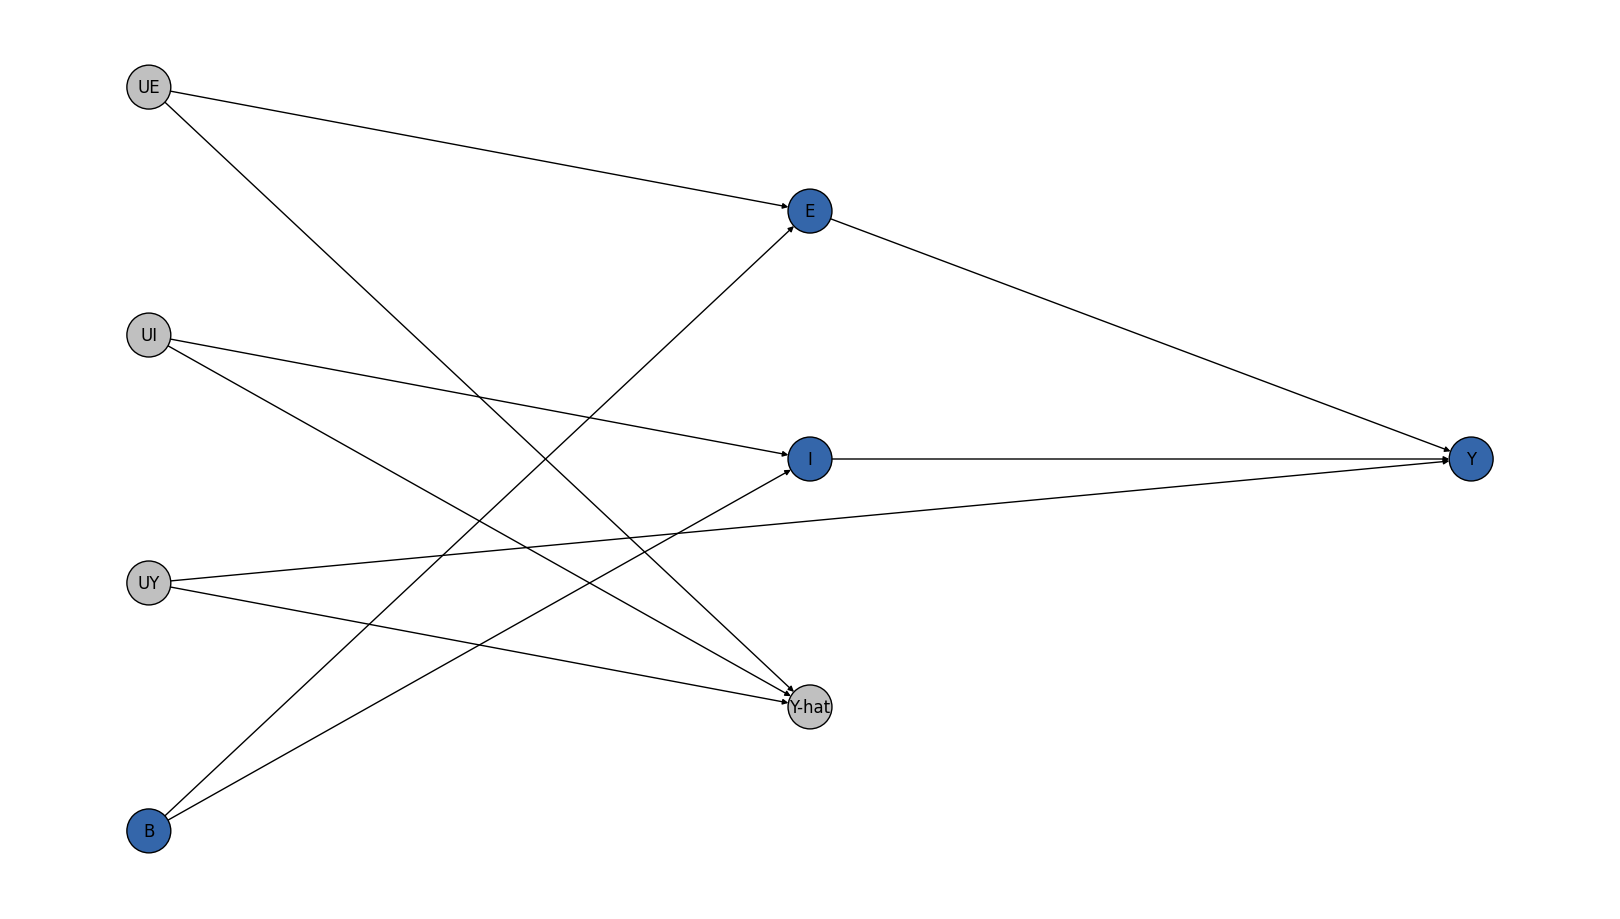

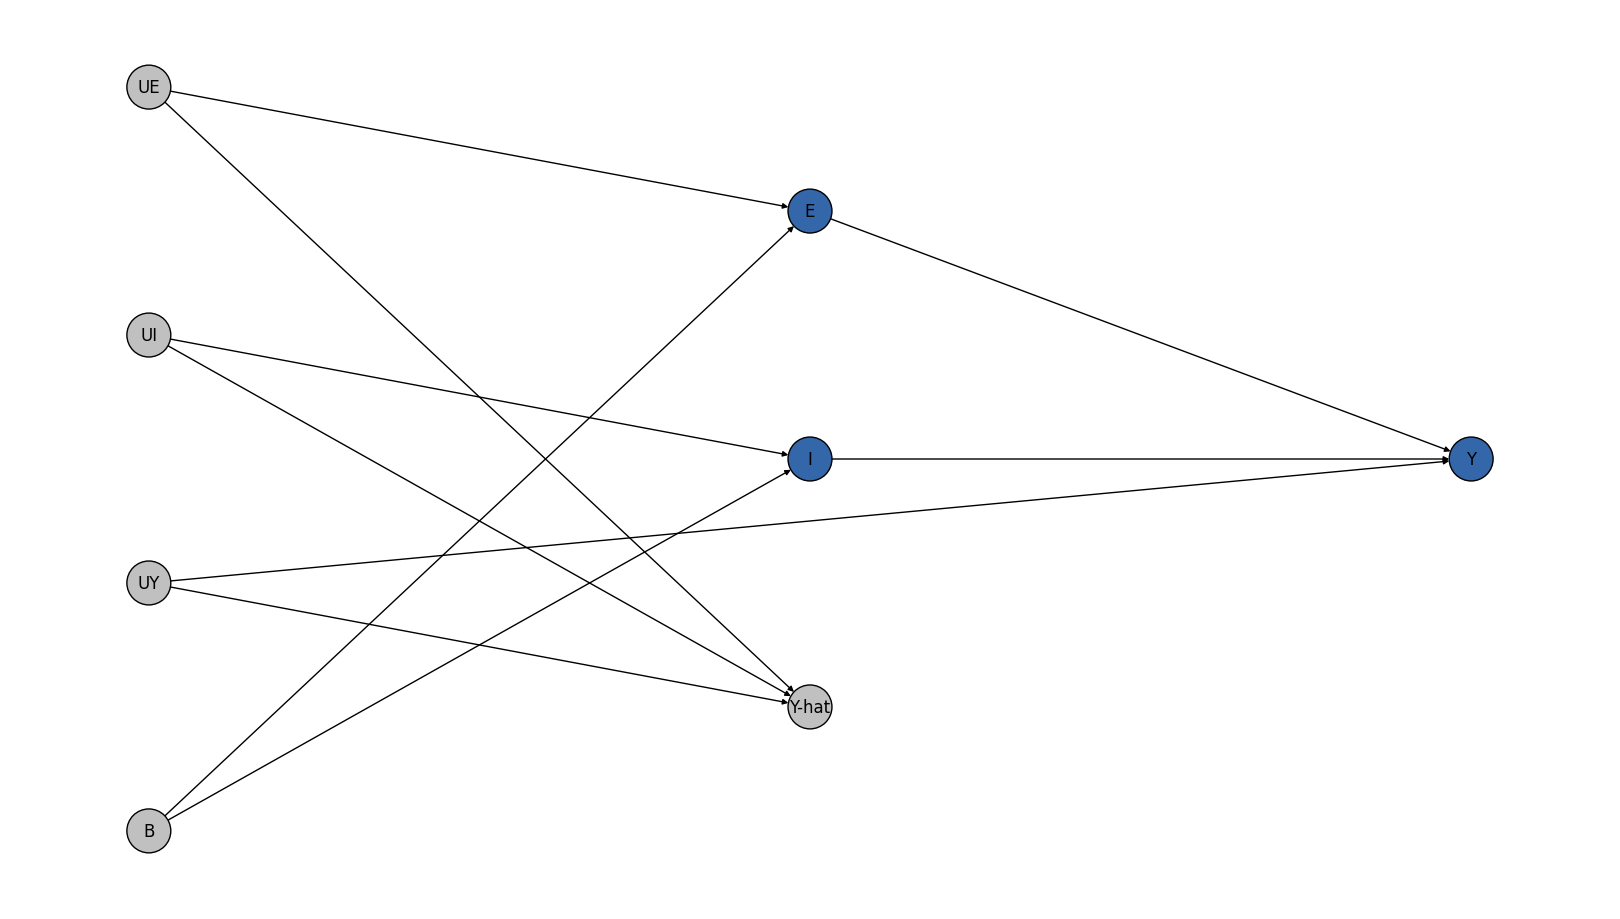

In [ ]:
#df_train, df_test = data_generation(seed, 5000, 1000, True, False)

In [6]:
df_train.head()

,UY,UE,UI,B,Y-hat,E,I,Y
0,0.773956,-1.098925,1.508077,0,0,0.901075,3.016154,1
1,0.438878,-0.541314,2.057802,0,1,1.458686,4.115604,1
2,0.858598,0.272001,0.234590,0,0,2.272001,0.469181,0
3,0.697368,-0.628320,-0.638429,1,0,-2.628320,-0.319215,0
4,0.094177,-0.278366,-0.221640,1,1,-2.278366,-0.110820,1


In [7]:
df_test.head()

,UY,UE,UI,B,Y-hat,E,I,Y
0,0.773956,-0.742192,-0.088614,1,0,-2.742192,-0.044307,0
1,0.438878,0.924358,-0.430458,1,1,-1.075642,-0.215229,0
2,0.858598,0.034612,0.796544,0,0,2.034612,1.593088,1
3,0.697368,-0.282796,-0.235834,1,0,-2.282796,-0.117917,0
4,0.094177,-0.106182,-0.306697,0,1,1.893818,-0.613395,1


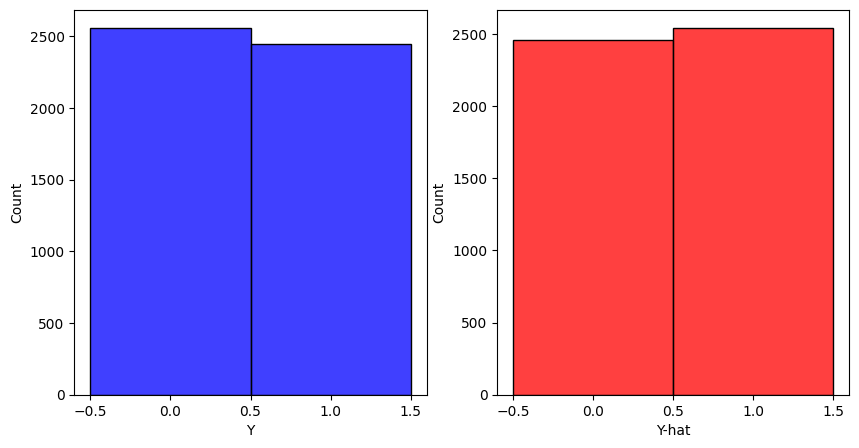

In [6]:
plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
sns.histplot(df_train['Y'], color='blue', discrete=True)
plt.subplot(1,2,2)
sns.histplot(df_train['Y-hat'], color='red', discrete=True)
plt.show()

In [ ]:
num_errors = np.sum(df_train['Y'] != df_train['Y-hat'])/len(df_train['Y'])
distance = jensenshannon(df_train['Y'], df_train['Y-hat'])
print(f'The normalize number of different values is: {num_errors:.4f}')
print(f'The Jensen-Shannon distance of the two distribution is {distance:.4f}')


The normalize number of different values is: 0.1964
The Jensen-Shannon distance of the two distribution is 0.3695


#### <a id='toc2_1_1_1_'></a>[Only one features per time](#toc0_)

In [ ]:
# Trasformazione affine in B 
def f_a_sum(UA, B):
    return UA+(B==0).astype(int)*2 + (B==1).astype(int)*(-2)

#Trasformazione affine in in B se e solo se UI è costante
def f_a_prod(UA, B):
    return (UA*2)*(B==0).astype(int) + (UA/2)*(B==1).astype(int)

def f_y(UY, UA):
    beta_a = 0.5
    u =  beta_a*UA
    val = 1/(1 + np.exp(-1*(u)))
    return (UY < val).astype(int)

In [64]:
def data_generation(seed, num_train, num_test, hidden, load):
    if load:
        df_train = pd.read_csv('data_train_one.csv')
        df_test = pd.read_csv('data_test_one.csv')
    else:
        #TrainSet
        dg = Generator(seed=seed)   
        UY = dg.uniform(low=0, high=1, name='UY', hidden=True)
        UA = dg.normal(mu = 0, sigma = 1, name='UA', hidden = True)
        B = dg.custom(lambda s : np.random.binomial(n = 1, p=0.5, size = s), name='B')
        A = dg.descendant(lambda B, UA: f_a_prod(UA, B), name='A')  
        Y = dg.descendant(lambda UY, A : f_y(UY,A), name='Y')
        Y_hat = dg.descendant(lambda UY, UA : f_y(UY,UA), name='Y-hat', hidden = True)

        df_train = dg.generate(num=num_train, hidden=hidden)
        df_train.to_csv('data_train_one.csv', index=False)

        dg.visualize()

        #TestSet
        dg = Generator(seed=seed)   
        UY = dg.uniform(low=0, high=1, name='UY', hidden=True)
        UA = dg.normal(mu = 0, sigma = 1, name='UA', hidden = True)
        B = dg.custom(lambda s : np.random.binomial(n = 1, p=0.5, size = s), name='B', hidden=True)
        A = dg.descendant(lambda B, UA: f_a_prod(UA, B), name='A')  
        Y = dg.descendant(lambda UY, A : f_y(UY,A), name='Y')
        Y_hat = dg.descendant(lambda UY, UA : f_y(UY,UA), name='Y-hat', hidden = True)

        df_test = dg.generate(num=num_test, hidden=hidden)
        df_test.to_csv('data_test_one.csv', index=False)

        dg.visualize()

    return df_train, df_test

In [ ]:
df_train = pd.read_csv('data/data_train_one.csv')
df_test = pd.read_csv('data/data_test_one.csv')

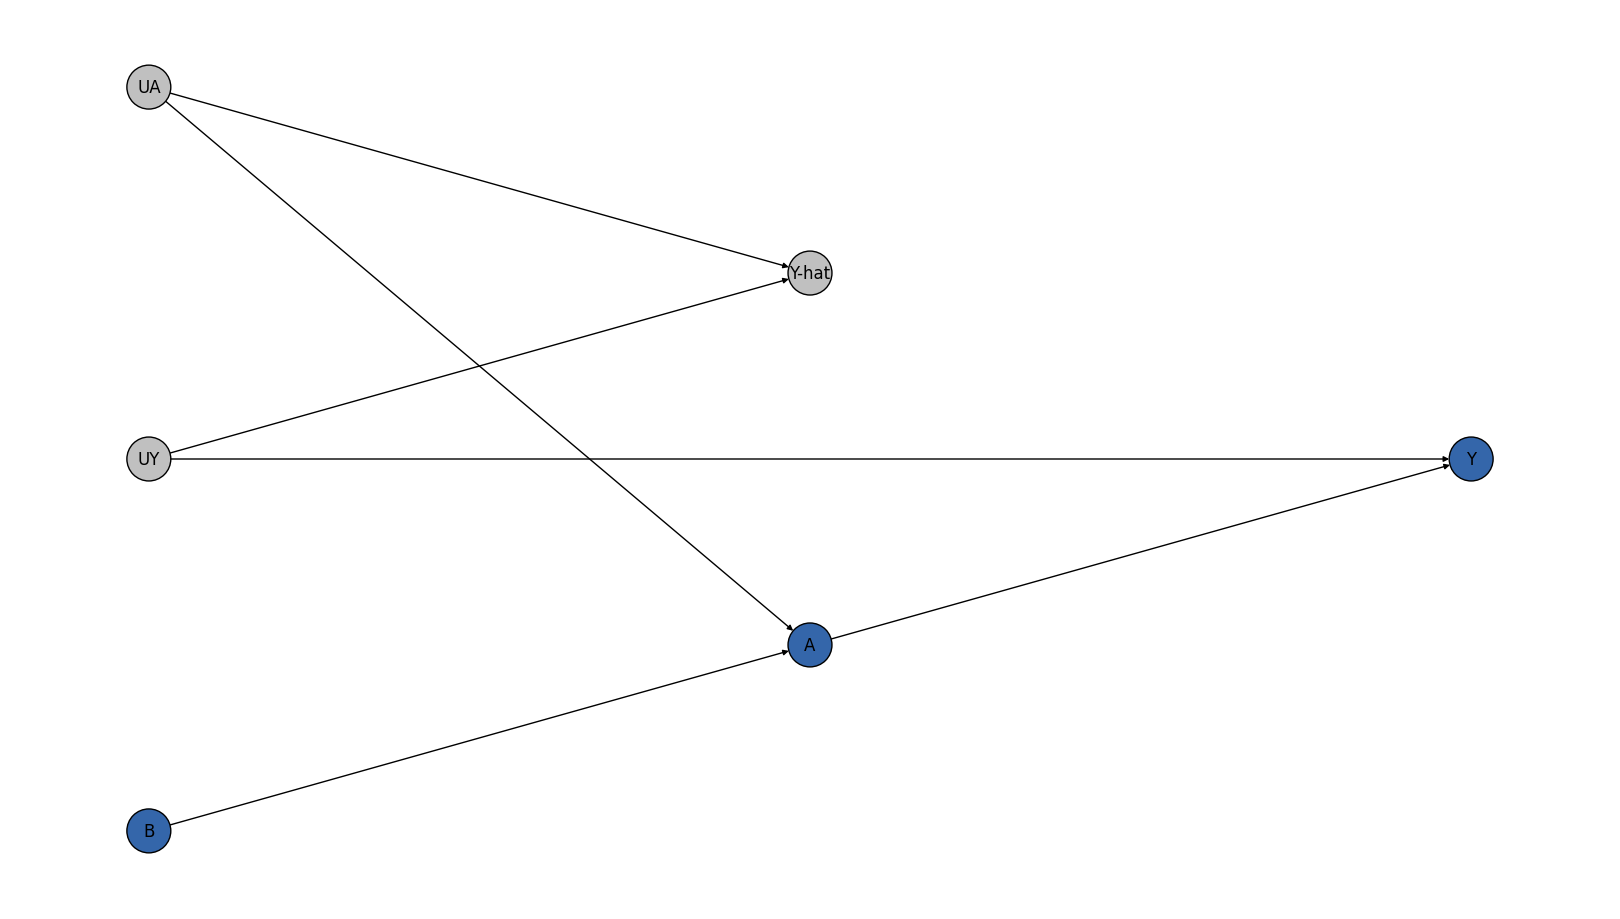

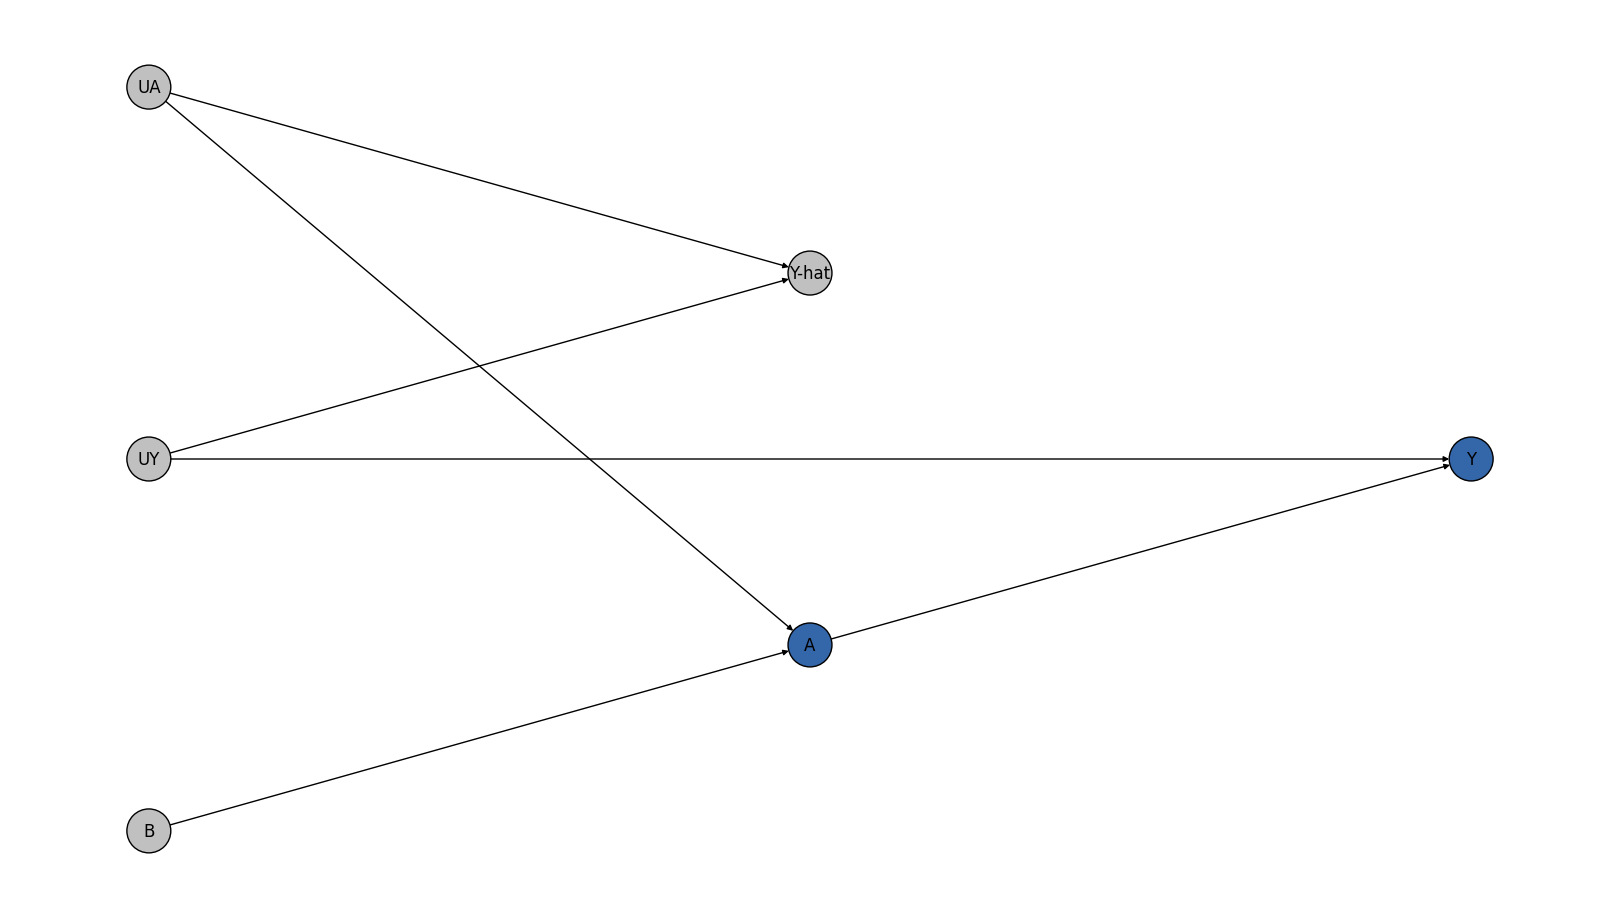

In [ ]:
#df_train, df_test = data_generation(seed, 5000, 1000, True, False)

In [66]:
df_train.head()

,UY,UA,B,Y-hat,A,Y
0,0.773956,-1.098925,1,0,-0.549462,0
1,0.438878,-0.541314,0,0,-1.082629,0
2,0.858598,0.272001,1,0,0.136001,0
3,0.697368,-0.628320,1,0,-0.314160,0
4,0.094177,-0.278366,0,1,-0.556733,1


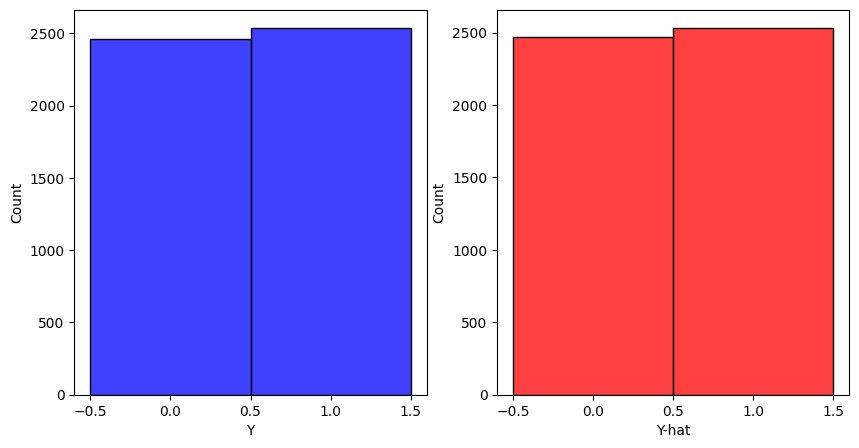

In [67]:
plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
sns.histplot(df_train['Y'], color='blue', discrete=True)
plt.subplot(1,2,2)
sns.histplot(df_train['Y-hat'], color='red', discrete=True)
plt.show()

In [ ]:
num_errors = np.sum(df_train['Y'] != df_train['Y-hat'])/len(df_train['Y'])
distance = jensenshannon(df_train['Y'], df_train['Y-hat'])
print(f'The normalize number of different values is: {num_errors:.4f}')
print(f'The Jensen-Shannon distance of the two distribution is {distance:.4f}')

The normalize number of different values is: 0.0576
The Jensen-Shannon distance of the two distribution is 0.1985


### <a id='toc2_1_2_'></a>[Joint Normal Data](#toc0_)

In [ ]:
def f_e(UE, B):
    a_e, b_e, c_e = 1.8, 1.5, 0
    return a_e*UE + b_e*B + c_e

def f_i(UI, B):
    a_i, b_i, c_i = 1.6, 1.7, 0
    return a_i*UI + b_i*B + c_i

def f_y(UY, UI, UE):
    beta_e, beta_i = 0.5, 0.5
    u =  beta_e*UE + beta_i*UI
    val = 1/(1 + np.exp(-1*(u)))
    return (UY < val).astype(int)

In [6]:
#Binormial
def data_generation(seed, num_train, num_test, hidden, load):
    if load:
        df_train = pd.read_csv('data_train_normal.csv')
        df_test = pd.read_csv('data_test_normal.csv')
    else:
        #TrainSet
        dg = Generator(seed=seed)   
        UY = dg.uniform(low=0, high=1, name='UY', hidden=True)
        UE = dg.normal(mu = 0, sigma = 1, name='UE', hidden = True)
        UI = dg.normal(mu = 0, sigma = 1, name='UI', hidden = True)
        B = dg.normal(mu = 0, sigma = 1, name='B')
        E = dg.descendant(lambda B, UE: f_e(UE, B), name='E')  
        I = dg.descendant(lambda B, UI: f_i(UI, B), name='I')
        Y = dg.descendant(lambda UY, I, E : f_y(UY,I, E), name='Y')
        Y_hat = dg.descendant(lambda UY, UI, UE : f_y(UY,UI, UE), name='Y-hat', hidden = True)

        df_train = dg.generate(num=num_train, hidden=hidden)
        df_train.to_csv('data_train_normal.csv', index=False)

        dg.visualize()

        #TestSet
        dg = Generator(seed=seed)   
        UY = dg.uniform(low=0, high=1, name='UY', hidden=True)
        UE = dg.normal(mu = 0, sigma = 1, name='UE', hidden = True)
        UI = dg.normal(mu = 0, sigma = 1, name='UI', hidden = True)
        B = dg.normal(mu = 0, sigma = 1, name='B', hidden = True)
        E = dg.descendant(lambda B, UE: f_e(UE, B), name='E')  
        I = dg.descendant(lambda B, UI: f_i(UI, B), name='I')
        Y = dg.descendant(lambda UY, I, E : f_y(UY,I, E), name='Y')
        Y_hat = dg.descendant(lambda UY, UI, UE : f_y(UY,UI, UE), name='Y-hat', hidden = True)
    
        df_test = dg.generate(num=num_test, hidden=hidden)
        df_test.to_csv('data_test_normal.csv', index=False)

        dg.visualize()

    return df_train, df_test

In [ ]:
df_train = pd.read_csv('data/data_train_normal.csv')
df_test = pd.read_csv('data/data_test_normal.csv')

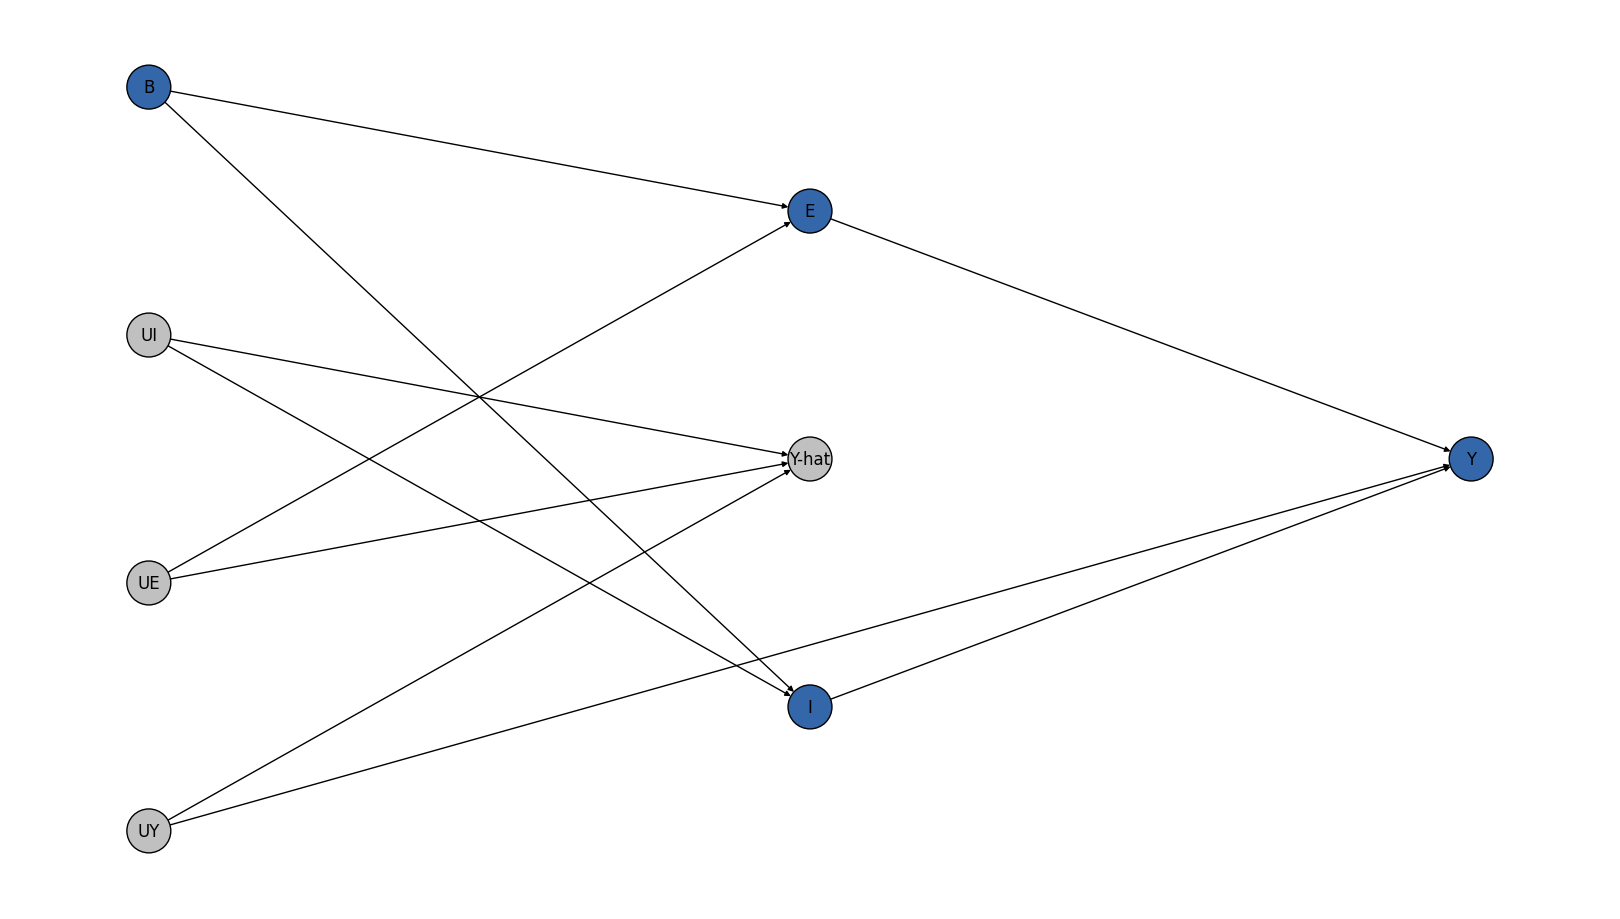

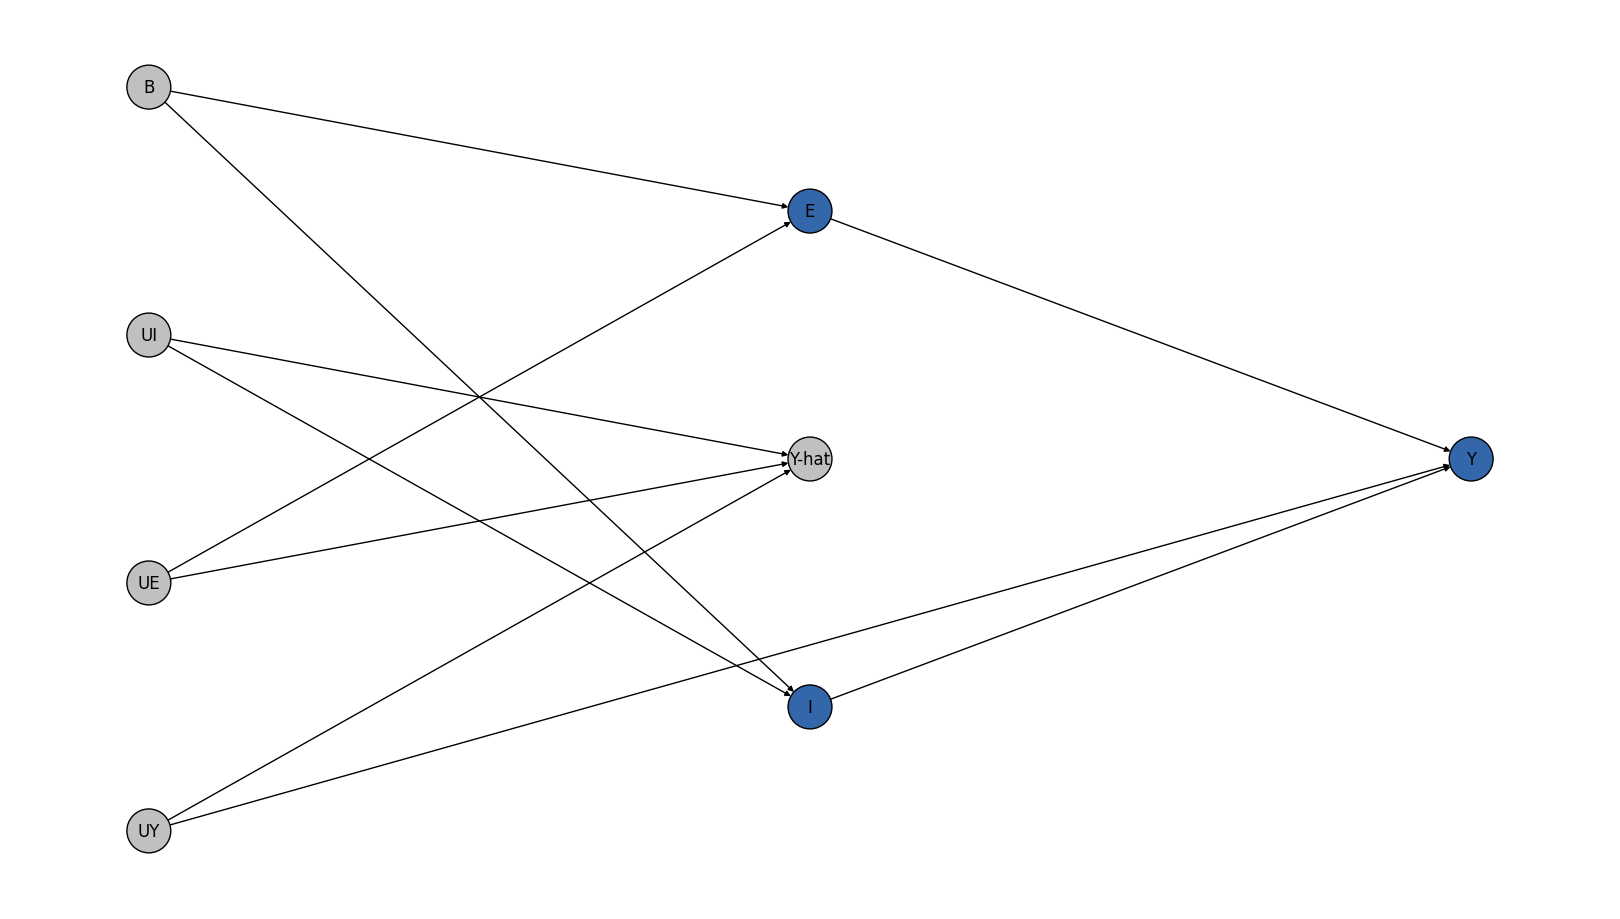

In [ ]:
#df_train, df_test = data_generation(seed, 5000, 1000, True, False)

In [9]:
df_train.head()

,UY,UE,UI,B,Y-hat,E,I,Y
0,0.773956,-1.098925,1.508077,-0.932890,0,-3.377400,0.827010,0
1,0.438878,-0.541314,2.057802,-0.054155,1,-1.055598,3.200420,1
2,0.858598,0.272001,0.234590,-0.378656,0,-0.078382,-0.268371,0
3,0.697368,-0.628320,-0.638429,0.819891,0,0.098860,0.372328,0
4,0.094177,-0.278366,-0.221640,0.847922,1,0.770823,1.086843,1


In [10]:
df_test.head()

,UY,UE,UI,B,Y-hat,E,I,Y
0,0.773956,-0.742192,-0.088614,-0.681615,0,-2.358368,-1.300527,0
1,0.438878,0.924358,-0.430458,2.031400,1,4.710944,2.764647,1
2,0.858598,0.034612,0.796544,-0.032474,0,0.013590,1.219264,0
3,0.697368,-0.282796,-0.235834,1.028054,0,1.033048,1.370356,1
4,0.094177,-0.106182,-0.306697,-0.053303,1,-0.271082,-0.581331,1


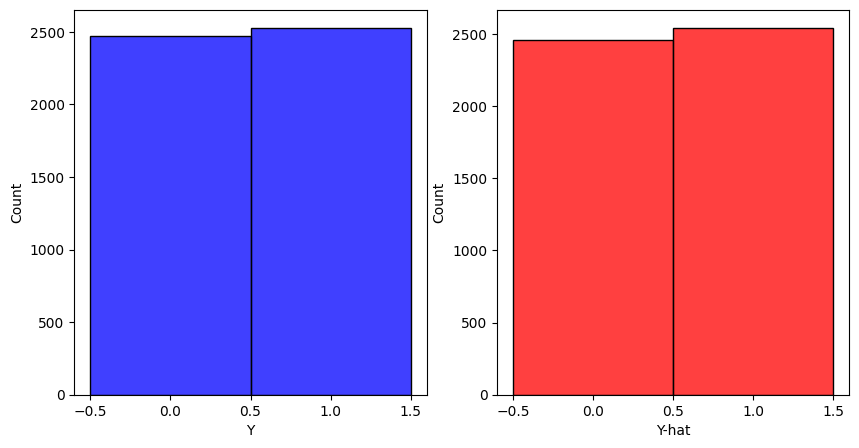

In [11]:
plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
sns.histplot(df_train['Y'], color='blue', discrete=True)
plt.subplot(1,2,2)
sns.histplot(df_train['Y-hat'], color='red', discrete=True)
plt.show()

In [ ]:
num_errors = np.sum(df_train['Y'] != df_train['Y-hat'])/len(df_train['Y'])
distance = jensenshannon(df_train['Y'], df_train['Y-hat'])
print(f'The normalize number of different values is: {num_errors:.4f}')
print(f'The Jensen-Shannon distance of the two distribution is {distance:.4f}')

The normalize number of different values is: 0.2136
The Jensen-Shannon distance of the two distribution is 0.3823


### <a id='toc2_1_3_'></a>[Real Data](#toc0_)

![Casual Graph Adult UCI](Screenshot_5-3-2025_173445_.jpeg)

In [7]:
# fetch dataset 
adult = fetch_ucirepo(id=2) 
  
# data (as pandas dataframes) 
X = adult.data.features 
y = adult.data.targets 

In [4]:
print(adult.variables)

              name     role         type      demographic  \
0              age  Feature      Integer              Age   
1        workclass  Feature  Categorical           Income   
2           fnlwgt  Feature      Integer             None   
3        education  Feature  Categorical  Education Level   
4    education-num  Feature      Integer  Education Level   
5   marital-status  Feature  Categorical            Other   
6       occupation  Feature  Categorical            Other   
7     relationship  Feature  Categorical            Other   
8             race  Feature  Categorical             Race   
9              sex  Feature       Binary              Sex   
10    capital-gain  Feature      Integer             None   
11    capital-loss  Feature      Integer             None   
12  hours-per-week  Feature      Integer             None   
13  native-country  Feature  Categorical            Other   
14          income   Target       Binary           Income   

                       

In [8]:
def clean(X,y):
    #Missing Values
    missing_indices = X.dropna().index
    X = X.loc[missing_indices].reset_index(drop=True)
    y = y.loc[missing_indices].reset_index(drop=True)
    #Label Encoding X
    X = X.drop(columns=['fnlwgt', 'capital-gain', 'capital-loss', 'education-num'])
    categorical_cols = X.select_dtypes(include=['object']).columns
    for col in categorical_cols:
        le = LabelEncoder()
        X[col] = le.fit_transform(X[col])
    #Label Encoding y
    one_encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
    y['income'] = y['income'].astype(str).str.rstrip('.')  
    y = pd.DataFrame(one_encoder.fit_transform(y[['income']]))
    y.columns = one_encoder.get_feature_names_out(['income'])
    y = pd.DataFrame(y['income_>50K'], columns=['income_>50K'])
    return X, y

In [25]:
X_clean, y_clean = clean(X,y)
df_clean = pd.concat([X_clean, y_clean], axis=1)

df_train, df_test = train_test_split(df_clean, test_size=0.2, random_state=seed, stratify=df_clean['income_>50K'])

In [26]:
df_train.head()

,age,workclass,education,marital-status,occupation,relationship,race,sex,hours-per-week,native-country,income_>50K
22858,37,2,9,4,10,1,4,0,45,39,0.0
46151,23,4,11,2,12,0,4,1,50,39,0.0
11979,34,4,11,2,14,0,1,1,40,39,1.0
23082,38,6,11,2,8,0,4,1,80,22,0.0
1102,39,5,6,2,4,0,4,1,40,26,0.0


In [27]:
df_test.head()

,age,workclass,education,marital-status,occupation,relationship,race,sex,hours-per-week,native-country,income_>50K
23076,23,4,11,4,3,3,4,1,37,26,0.0
2322,22,4,11,4,3,3,4,1,55,39,0.0
5043,44,7,9,0,10,1,4,0,40,39,0.0
22990,23,4,11,2,12,0,4,1,40,39,0.0
37206,26,5,9,4,4,3,4,1,80,39,0.0


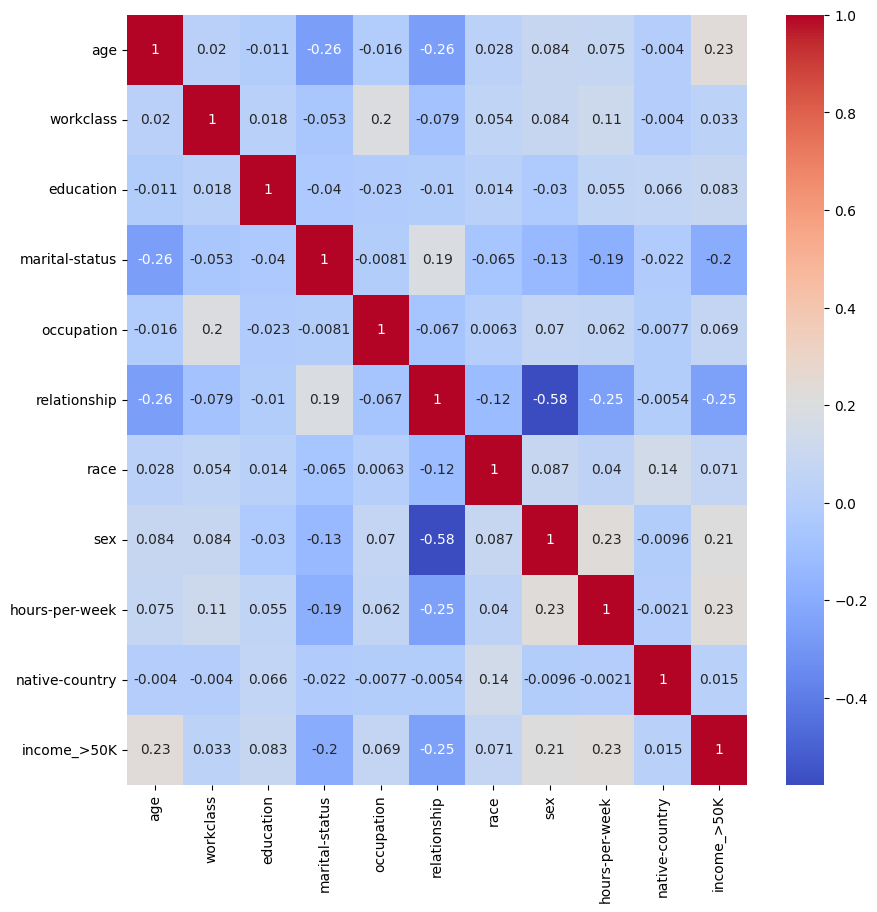

In [12]:
## Correltion map
corr = df_train.corr()
plt.figure(figsize=(10,10))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.show()

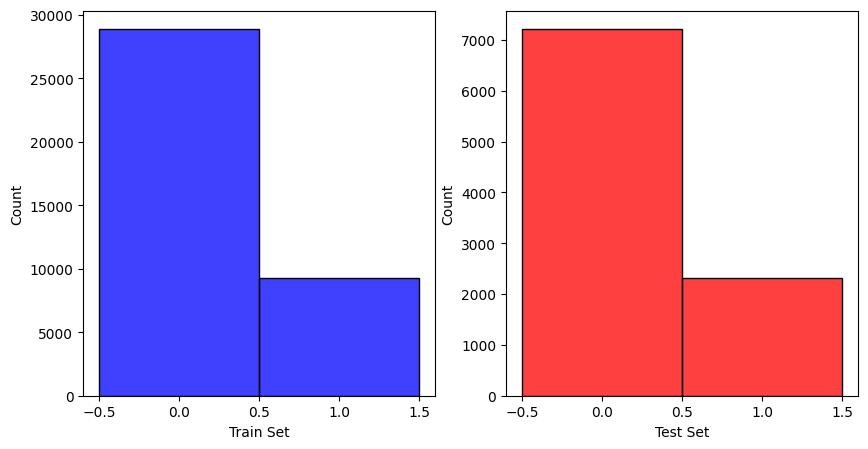

In [13]:
plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
sns.histplot(df_train['income_>50K'], color='blue', discrete=True)
plt.xlabel('Train Set')
plt.subplot(1,2,2)
sns.histplot(df_test['income_>50K'], color='red', discrete=True)
plt.xlabel('Test Set')
plt.show()

# <a id='toc3_'></a>[DECORELLATION](#toc0_)

## <a id='toc3_1_'></a>[HGR approach](#toc0_)

In [118]:
# Basic Neural Network with 2-layer for each block
class buidNNmodel(nn.Module):
    def __init__(self, input_shape, hidden_shape, output_shape):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_shape, 64),
            nn.ReLU(),
            nn.BatchNorm1d(64),
            nn.Linear(64,hidden_shape)

        )
        self.decoder = nn.Sequential(
            nn.Linear(hidden_shape, 64),
            nn.ReLU(),
            nn.BatchNorm1d(64),
            nn.Linear(64, output_shape) 
        )
    
    def forward(self, x):
        z = self.encoder(x)  
        transformed_x = self.decoder(z)  
        return transformed_x

To implement the HGR approach I chose a Encoder-Decoder Neural Network with two layers for each block. The costum losses chosen are:
$$
L_{1,2}(\theta, X, Z) = 1 - HGR(X, F(X, \theta)) + \lambda\max(0, HGR(Z, F(X, \theta)) - \epsilon)
$$ 
$$
L_{3,4}(\theta, X, Z) = HGR(Z, F(X, \theta)) + \lambda\max(0, \epsilon - HGR(X, F(X, \theta)))
$$
The difference between the two approaches lies in the swapped roles of the constraint and the function to minimize.
The distinction between 1 and 2, as well as between 3 and 4, depends on how the HGR is computed: in 1 and 3, it is calculated feature by feature, and then the mean is taken; in 2 and 4, it is computed in a single step.

In [15]:
#I compute the indicator term by term from the vector input
def costum_loss_1(x, x_hat, z, alpha, beta, epsilon, method='mean'):
    ind = indicator(semantics='hgr', algorithm='sk',backend='torch')
    original_correlation = []
    sensitive_correlation = []
    for i in range(len(x[1])):
        original_correlation.append(1-(ind.compute(x_hat[:, i],x[:, i])))
        sensitive_correlation.append(ind.compute(x_hat[:, i],z) - epsilon)
    original_correlation = torch.stack(original_correlation)
    sensitive_correlation = torch.stack(sensitive_correlation)
    if method == 'mean':
        constraint = torch.relu(torch.mean(sensitive_correlation))
        loss = alpha * torch.mean(original_correlation) + beta * constraint
    if method == 'max':
        constraint = torch.relu(torch.max(sensitive_correlation))
        loss = alpha * torch.max(original_correlation) + beta * constraint
    return loss, constraint

In [16]:
#I compute the indicator in one passagge
def costum_loss_2(x, x_hat, z, alpha, beta, epsilon):
    ind = indicator(semantics='hgr', algorithm='sk', backend='torch')
    original_correlation = 1-(ind.compute(x_hat,x))
    sensitive_correlation = ind.compute(x_hat,z) - epsilon
    constraint = torch.relu(sensitive_correlation)
    loss = alpha * original_correlation + beta * constraint
    return loss, constraint

In [17]:
#I switch the role of contraint and loss to minimize
def costum_loss_3(x, x_hat, z, alpha, beta, epsilon, method='mean'):
    ind = indicator(semantics='hgr', algorithm='sk', backend='torch')
    original_correlation = []
    sensitive_correlation = []
    for i in range(len(x[1])):
        original_correlation.append(epsilon-(ind.compute(x_hat[:, i],x[:, i])))
        sensitive_correlation.append(ind.compute(x_hat[:, i],z))
    original_correlation = torch.stack(original_correlation)
    sensitive_correlation = torch.stack(sensitive_correlation)
    if method == 'mean':
        constraint = torch.relu(torch.mean(original_correlation))
        loss = alpha * torch.mean(sensitive_correlation) + beta * constraint
    if method == 'max':
        constraint = torch.relu(torch.mean(original_correlation))
        loss = alpha * torch.max(sensitive_correlation) + beta * constraint
    return loss, constraint

In [18]:
def costum_loss_4(x, x_hat, z, alpha, beta, epsilon):
    ind = indicator(semantics='hgr', algorithm='sk', backend='torch')
    original_correlation = epsilon-(ind.compute(x_hat,x))
    sensitive_correlation = ind.compute(x_hat,z) 
    constraint = torch.relu(original_correlation)
    loss = alpha *sensitive_correlation + beta * constraint
    return loss, constraint

In [19]:
#Model that learn the projection of the new non-sensitive variables, with specific hyperparameters for the lagrangian
class LitNNModel(L.LightningModule):
    def __init__(self, model: nn.Module, lr : float, weight_decay: float, alpha : float, beta : float, epsilon : float, costum_loss: callable): 
        super().__init__()
        self.model = model
        self.lr = lr
        self.weight_decay = weight_decay
        self.alpha = alpha
        self.beta = beta
        self.epsilon = epsilon
        self.costum_loss = costum_loss
        #self.gradient_stats = {}
        #self.save_hyperparameters() 
    
    def training_step(self, batch, batch_idx):
        ind = indicator('hgr', 'sk', 'torch')
        z, x, _ = batch
        x_hat = self.model(x)
        lagrangian, constraint = self.costum_loss(x, x_hat, z, self.alpha, self.beta, self.epsilon)
        #correlation = ind.compute(x, x_hat)
        #fairness = ind.compute(z, x_hat)
        self.log('lagrangian_loss', lagrangian, on_step=False, on_epoch=True, prog_bar=True, logger=True) 
        self.log('constraint', constraint, on_step=False, on_epoch=True, prog_bar=True, logger=True)
        #self.log('correlation', correlation, on_step=False, on_epoch=True, prog_bar=False, logger=True)
        #self.log('fairness', fairness, on_step=False, on_epoch=True, prog_bar=False, logger=True)

        return lagrangian
    
    def validation_step(self, batch, batch_idx):
        ind = indicator('hgr', 'sk', 'torch')
        z, x, _ = batch
        x_hat = self.model(x)
        lagrangian, constraint = self.costum_loss(x, x_hat, z, self.alpha, self.beta, self.epsilon)
        correlation = ind.compute(x, x_hat)
        fairness = ind.compute(z, x_hat)
        self.log('lagrangian_loss_val', lagrangian, on_step=False, on_epoch=True, prog_bar=True, logger=True) 
        self.log('constraint_val', constraint, on_step=False, on_epoch=True, prog_bar=True, logger=True)
        self.log('correlation_val', correlation, on_step=False, on_epoch=True, prog_bar=False, logger=True)
        self.log('fairness_val', fairness, on_step=False, on_epoch=True, prog_bar=False, logger=True)

        return lagrangian


    def predict_step(self, batch, batch_idx):
        _, x, _ = batch
        return self.model(x)
    
    def configure_optimizers(self):
        optimizer = optim.AdamW(self.parameters(), lr=self.lr, weight_decay=self.weight_decay)
        scheduler = {
            'scheduler': ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5),
            'monitor': 'lagrangian_loss',  
            'interval': 'epoch'         
        }
        return {'optimizer' : optimizer, 'lr_scheduler' : scheduler}

In [17]:
# Qui ho invertito loss e constraint (senso è che se usassi come loss il mantenere la correlazione originale penso a sto punto non mi partirebbe nemmeno il grafico)
def loss_fn_1(z, x_new, method = 'mean'):
    ind = indicator(semantics='hgr', algorithm='sk', backend='torch')
    sensitive_correlation = []
    for i in range(len(x_new[1])):
        sensitive_correlation.append(ind.compute(x_new[:, i],z))
    sensitive_correlation = torch.stack(sensitive_correlation)
    if method == 'mean':
        loss = torch.mean(sensitive_correlation)
    if method == 'max':
        loss = torch.max(sensitive_correlation) 
    return loss
     
def constraint_fn_1(x_original, x_new, epsilon, method = 'mean'):
    ind = indicator(semantics='hgr', algorithm='sk', backend='torch')
    original_correlation = []
    for i in range(len(x_new[1])):
        original_correlation.append(epsilon-(ind.compute(x_new[:, i],x_original[:, i])))
    original_correlation = torch.stack(original_correlation)
    if method == 'mean':
        loss = torch.mean(torch.relu(original_correlation))
    if method == 'max':
        loss = torch.max(torch.relu(original_correlation)) 
    return loss

def loss_fn_2(x_original, x_new, method = 'mean'):
    ind = indicator(semantics='hgr', algorithm='sk', backend='torch')
    original_correlation = []
    for i in range(len(x_new[1])):
        original_correlation.append(ind.compute(x_new[:, i],x_original[:, i]))
    original_correlation = torch.stack(original_correlation)
    if method == 'mean':
        loss = torch.mean(original_correlation)
    if method == 'max':
        loss = torch.max(original_correlation) 
    return loss
     
def constraint_fn_2(z, x_new, epsilon, method = 'mean'):
    ind = indicator(semantics='hgr', algorithm='sk', backend='torch')
    sensitive_correlation = []
    for i in range(len(x_new[1])):
        sensitive_correlation.append(ind.compute(x_new[:, i],z) - epsilon)
    sensitive_correlation = torch.stack(sensitive_correlation)
    if method == 'mean':
        loss = torch.mean(torch.relu(sensitive_correlation))
    if method == 'max':
        loss = torch.max(torch.relu(sensitive_correlation)) 
    return loss

In [20]:
#Dual Ascent method for compute the lagrangian (Alcuni dubbi se ha senso) -> Non ha senso perchè lambda rimane sempre costante...da rivedere
class DualAscentLightningModule(L.LightningModule):
    def __init__(self, model : nn.Module, constraint_fn : callable, loss_fn : callable, epsilon : float =0.9, lambda_lr : float =1e-2, theta_lr : float =1e-3, weight_decay: float =1e-6):
        super().__init__()
        self.model = model
        self.lambda_ = torch.nn.Parameter(torch.tensor(3.0), requires_grad=True) 
        self.lambda_lr = lambda_lr
        self.theta_lr = theta_lr
        self.weight_decay = weight_decay
        self.epsilon = epsilon
        self.constraint_fn = constraint_fn 
        self.loss_fn = loss_fn
        self.automatic_optimization = False
    
    def compute_lagrangian(self, batch, batch_idx):
        z, x, _ = batch
        x_hat = self.model(x)
        loss = self.loss_fn(x, x_hat)  
        constraint = self.constraint_fn(z, x_hat, self.epsilon) 
        lagrangian = loss + self.lambda_ * constraint
        return loss, constraint, lagrangian

        
    def training_step(self, batch, batch_idx):
        
        torch.autograd.set_detect_anomaly(True)
        
        opt_theta, opt_lambda = self.optimizers()  
        _, _, lagrangian = self.compute_lagrangian(batch, batch_idx)
        opt_theta.zero_grad()
        self.manual_backward(lagrangian, retain_graph=True)
        opt_theta.step()
        
        loss, constraint, lagrangian = self.compute_lagrangian(batch, batch_idx)
        ascent_loss = -self.lambda_ * constraint  
        opt_lambda.zero_grad()
        self.manual_backward(-lagrangian)
        opt_lambda.step()
        self.lambda_.data.clamp_(min=0.0)

        self.log("train_loss", loss, on_step=False, on_epoch=True, prog_bar=True)
        self.log("ascent_loss", ascent_loss, on_step=False, on_epoch=True, prog_bar=True)
        self.log("constraint", constraint, on_step=False, on_epoch=True, prog_bar=True)
        self.log("lagrangian", lagrangian, on_step=False, on_epoch=True, prog_bar=True)
        

    def configure_optimizers(self):
        theta_optimizer = optim.AdamW(self.model.parameters(), lr=self.theta_lr, weight_decay=self.weight_decay)
        lambda_optimizer = optim.SGD([self.lambda_], lr=self.lambda_lr, momentum=0.9)
        return [theta_optimizer, lambda_optimizer]
    
    def predict_step(self, batch, batch_idx):
        _, x, _ = batch
        return self.model(x)

In [132]:
cfg = {
    'batch_size_train' : 1024,
    'batch_size_test' : 1024,
    'data' : 'experiment',
    'lr' : 1e-4,
    'weight_decay' : 1e-6,
    'alpha' : 1,
    'beta' : 3,
    'epsilon' : 0.05,
    'input_shape' : 1,
    'hidden_shape' : 128,
    'output_shape' : 1,
    'lambda_lr' : 1e-5,
    'theta_lr' : 1e-3,
    'epochs' : 500,
    'method' : 'costum_loss_1'
}

In [ ]:
#Syntetic data
if cfg['data'] == 'syntetic':
    class MyDataset(Dataset):
        def __init__(self, df):
            self.x = torch.tensor(
                np.array([(df['E'].values - df['E'].mean())/df['E'].std(), (df['I'].values - df['I'].mean())/df['I'].std()]).T,  
                dtype=torch.float32,
            )
            self.z = torch.tensor(df['B'].values, dtype=torch.float32).unsqueeze(1)  
            self.y = torch.tensor(df['Y'].values, dtype=torch.long).unsqueeze(1)  

        def __len__(self):
            return len(self.x)

        def __getitem__(self, idx):
            return self.z[idx], self.x[idx], self.y[idx]

#Syntetic data one-feature
if cfg['data'] == 'syntetic_one':    
    class MyDataset(Dataset):
        def __init__(self, df):
            self.x = torch.tensor(
                np.array((df['A'].values - df['A'].mean())/df['A'].std()),  
                dtype=torch.float32,
            ).unsqueeze(1)
            self.z = torch.tensor(df['B'].values, dtype=torch.float32).unsqueeze(1)  
            self.y = torch.tensor(df['Y'].values, dtype=torch.long).unsqueeze(1)  

        def __len__(self):
            return len(self.x)

        def __getitem__(self, idx):
            return self.z[idx], self.x[idx], self.y[idx]

#Real Data
if cfg['data'] == 'real':
    class MyDataset(Dataset):
        def __init__(self,df):
            self.x = torch.tensor(
                np.array(df.drop(columns=['race', 'sex', 'age', 'native-country', 'income_>50K']).values),  
                dtype=torch.float32,
            )
            self.z = torch.tensor(df['sex'].values, dtype=torch.float32).unsqueeze(1)
            self.y = torch.tensor(df['income_>50K'].values, dtype=torch.long).unsqueeze(1)
    
        def __len__(self):
            return len(self.x)
        
        def __getitem__(self, idx):
            return self.z[idx], self.x[idx], self.y[idx]
        

#Little test -> TO DO! Different models per different features
if cfg['data'] == 'experiment':
    class MyDataset(Dataset):
        def __init__(self, df, features_name, sensitive_name, target_name):
            self.x = torch.tensor(
                np.array((df[features_name].values - df[features_name].mean())/df[features_name].std()),  
                dtype=torch.float32,
            ).unsqueeze(1)
            self.z = torch.tensor(df[sensitive_name].values, dtype=torch.float32).unsqueeze(1)  
            self.y = torch.tensor(df[target_name].values, dtype=torch.long).unsqueeze(1)

        def __len__(self):
            return len(self.x)
        
        def __getitem__(self, idx):
            return self.z[idx], self.x[idx], self.y[idx]
            


In [ ]:
def prepare_train(cfg, model_net):
    if cfg['method'] == 'costum_loss_1':
        model = LitNNModel(model=model_net, lr=cfg['lr'], weight_decay=cfg['weight_decay'], alpha=cfg['alpha'], beta=cfg['beta'], epsilon=cfg['epsilon'], costum_loss=costum_loss_1)
    if cfg['method'] == 'costum_loss_2':
        model = LitNNModel(model=model_net, lr=cfg['lr'], weight_decay=cfg['weight_decay'], alpha=cfg['alpha'], beta=cfg['beta'], epsilon=cfg['epsilon'], costum_loss=costum_loss_2)
    if cfg['method'] == 'costum_loss_3':
        model = LitNNModel(model=model_net, lr=cfg['lr'], weight_decay=cfg['weight_decay'], alpha=cfg['alpha'], beta=cfg['beta'], epsilon=cfg['epsilon'], costum_loss=costum_loss_3)
    if cfg['method'] == 'costum_loss_4':
        model = LitNNModel(model=model_net, lr=cfg['lr'], weight_decay=cfg['weight_decay'], alpha=cfg['alpha'], beta=cfg['beta'], epsilon=cfg['epsilon'], costum_loss=costum_loss_4)
    if cfg['method'] == 'dual_ascent':
        model = DualAscentLightningModule(model=model_net, constraint_fn=constraint_fn_2, loss_fn=loss_fn_2, epsilon=cfg['epsilon'], lambda_lr=cfg['lambda_lr'], theta_lr=cfg['theta_lr'], weight_decay=cfg['weight_decay'])
    return model

def training_loop(train, cfg, model_train, trainer):
    train_data = MyDataset(train)
    train_loader = DataLoader(train_data, batch_size=cfg['batch_size_train'], shuffle=True)
    trainer.fit(model=model_train, train_dataloaders=train_loader)


In [129]:
early_stopping = EarlyStopping(monitor='lagrangian_loss', mode='min', patience=15,verbose=True)
model_checkpoint = ModelCheckpoint(dirpath="checkpoints/", filename="best_model_costum_loss_1", monitor="lagrangian_loss", mode="min", save_top_k=1)

model = buidNNmodel(cfg['input_shape'], cfg['hidden_shape'], cfg['output_shape'])
model_train = prepare_train(cfg, model)
logger = TensorBoardLogger("lightning_logs", name=cfg['method'])
trainer = L.Trainer(callbacks=[early_stopping], max_epochs=cfg['epochs'], logger=logger, deterministic=True, benchmark=False)
training_loop(df_train, cfg, model_train, trainer)


GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs

  | Name  | Type        | Params | Mode 
----------------------------------------------
0 | model | buidNNmodel | 17.2 K | train
----------------------------------------------
17.2 K    Trainable params
0         Non-trainable params
17.2 K    Total params
0.069     Total estimated model params size (MB)
11        Modules in train mode
0         Modules in eval mode


Epoch 0: 100%|██████████| 10/10 [00:00<00:00, 24.68it/s, v_num=12, lagrangian_loss=1.140, constraint=0.296]

Metric lagrangian_loss improved. New best score: 1.141


Epoch 1: 100%|██████████| 10/10 [00:00<00:00, 22.21it/s, v_num=12, lagrangian_loss=0.639, constraint=0.153]

Metric lagrangian_loss improved by 0.502 >= min_delta = 0.0. New best score: 0.639


...

Epoch 79: 100%|██████████| 10/10 [00:00<00:00, 24.53it/s, v_num=12, lagrangian_loss=0.117, constraint=0.0113]

Metric lagrangian_loss improved by 0.005 >= min_delta = 0.0. New best score: 0.117


Epoch 94: 100%|██████████| 10/10 [00:00<00:00, 23.92it/s, v_num=12, lagrangian_loss=0.135, constraint=0.0176]

Monitored metric lagrangian_loss did not improve in the last 15 records. Best score: 0.117. Signaling Trainer to stop.


Epoch 94: 100%|██████████| 10/10 [00:00<00:00, 22.95it/s, v_num=12, lagrangian_loss=0.135, constraint=0.0176]


## <a id='toc3_2_'></a>[GridSearch](#toc0_)

In [ ]:
def cost_function(logs, cfg, penality_factor):
    constraint = logs[-1]['constraint_val']
    correlation = (1-logs[-1]['correlation_val'])
    fairness = logs[-1]['fairness_val']
    if constraint <= cfg['epsilon']:
        cost = correlation + fairness
    else:
        cost = correlation + fairness + penality_factor * (constraint - cfg['epsilon'])
    return cost

In [ ]:
class LogCollectorCallback(L.Callback):
    def __init__(self):
        super().__init__()
        self.logs = []

    def on_train_epoch_end(self, trainer, pl_module):
        epoch_logs = {key: value.item() for key, value in trainer.callback_metrics.items()}
        self.logs.append(epoch_logs)
        

In [93]:
def GreedSearch(lrs, betas, epsilons, batch_sizes, model_net, train, cfg):
    train, val = train_test_split(train, test_size=0.3, random_state=42)
    train_data = MyDataset(train)
    val_data = MyDataset(val)
    best_config = None
    best_stability_metric = np.inf
    results = []
    for lr, beta, eps, bs in itertools.product(lrs, betas, epsilons, batch_sizes):
        print(f"Testing cfg: lr={lr}, beta={beta}, epsilon={eps}, batch_size={bs}")
        module =  LitNNModel(model=model_net, lr=lr, weight_decay=cfg['weight_decay'], alpha=cfg['alpha'], beta=beta, epsilon=eps, costum_loss=costum_loss_1)
        train_loader = DataLoader(train_data, batch_size=bs, shuffle=True)
        val_loader = DataLoader(val_data, batch_size=256, shuffle=False)
        early_stopping = EarlyStopping(monitor='lagrangian_loss', mode='min', patience=10,verbose=True)
        log_collector = LogCollectorCallback()
        trainer = L.Trainer(callbacks=[early_stopping, log_collector], max_epochs=50, logger=False, enable_checkpointing=False)
        trainer.fit(model=module, train_dataloaders=train_loader, val_dataloaders=val_loader)
        stability = cost_function(log_collector.logs, cfg, 5)
        results.append({
            "lr": lr,
            "beta": beta,
            "epsilon": eps,
            "batch_size": bs,
            "stability": stability,
    })
        print(f"Stability metric: {stability}")
        if stability < best_stability_metric:
            best_stability_metric = stability
            best_config = {"lr": lr, "beta": beta, "epsilon": eps, "batch_size": bs}
    return best_config, results

In [104]:
lrs=[1e-4]
betas = [1, 2, 3, 4, 5, 6, 7]
epsilons = [0.05]
batch_sizes = [512]
best_cfg, results = GreedSearch(lrs, betas, epsilons, batch_sizes, model, df_train, cfg)
print(f'La migliore configurazione per costum_loss_2 è : {best_cfg}')

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs

  | Name  | Type        | Params | Mode
---------------------------------------------
0 | model | buidNNmodel | 17.2 K | eval
---------------------------------------------
17.2 K    Trainable params
0         Non-trainable params
17.2 K    Total params
0.069     Total estimated model params size (MB)
0         Modules in train mode
11        Modules in eval mode


Testing cfg: lr=0.0001, beta=1, epsilon=0.05, batch_size=512
Sanity Checking DataLoader 0:   0%|          | 0/2 [00:00<?, ?it/s]

c:\Users\claud\AppData\Local\Programs\Python\Python312\Lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:425: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=7` in the `DataLoader` to improve performance.


Sanity Checking DataLoader 0:  50%|█████     | 1/2 [00:00<00:00,  1.55it/s]

c:\Users\claud\AppData\Local\Programs\Python\Python312\Lib\site-packages\lightning\pytorch\core\module.py:512: You called `self.log('lagrangian_loss_val', ..., logger=True)` but have no logger configured. You can enable one by doing `Trainer(logger=ALogger(...))`
c:\Users\claud\AppData\Local\Programs\Python\Python312\Lib\site-packages\lightning\pytorch\core\module.py:512: You called `self.log('constraint_val', ..., logger=True)` but have no logger configured. You can enable one by doing `Trainer(logger=ALogger(...))`
c:\Users\claud\AppData\Local\Programs\Python\Python312\Lib\site-packages\lightning\pytorch\core\module.py:512: You called `self.log('correlation_val', ..., logger=True)` but have no logger configured. You can enable one by doing `Trainer(logger=ALogger(...))`
c:\Users\claud\AppData\Local\Programs\Python\Python312\Lib\site-packages\lightning\pytorch\core\module.py:512: You called `self.log('fairness_val', ..., logger=True)` but have no logger configured. You can enable one 

...

Epoch 22: 100%|██████████| 7/7 [00:06<00:00,  1.06it/s, lagrangian_loss_val=0.853, constraint_val=0.116, lagrangian_loss=0.115, constraint=0.0107]

Metric lagrangian_loss improved by 0.011 >= min_delta = 0.0. New best score: 0.115


Epoch 32: 100%|██████████| 7/7 [00:05<00:00,  1.22it/s, lagrangian_loss_val=0.848, constraint_val=0.116, lagrangian_loss=0.138, constraint=0.0142]

Monitored metric lagrangian_loss did not improve in the last 10 records. Best score: 0.115. Signaling Trainer to stop.


Epoch 32: 100%|██████████| 7/7 [00:05<00:00,  1.22it/s, lagrangian_loss_val=0.848, constraint_val=0.116, lagrangian_loss=0.138, constraint=0.0142]
Stability metric: 0.6411994248628616
La migliore configurazione per costum_loss_2 è : {'lr': 0.0001, 'beta': 1, 'epsilon': 0.05, 'batch_size': 512}


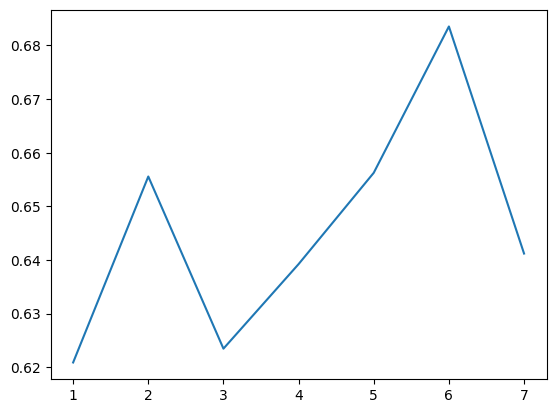

In [ ]:
plt.plot([r['beta'] for r in results],[r['stability'] for r in results])
plt.show()

## <a id='toc3_3_'></a>[Loading](#toc0_)

In [ ]:
LitModel_1 = LitNNModel.load_from_checkpoint('lightning_logs7costum_loss_17version_26/checkpoints/epoch=75-step=608.ckpt', model=model, lr=cfg['lr'], weight_decay=cfg['weight_decay'], alpha=cfg['alpha'], beta=cfg['beta'], epsilon=0.05, costum_loss=costum_loss_1)

In [766]:
LitModel_2 = LitNNModel.load_from_checkpoint('checkpoints/best_model_costum_loss_2.ckpt', model=model, lr=cfg['lr'], weight_decay=cfg['weight_decay'], alpha=cfg['alpha'], beta=cfg['beta'], epsilon=0.05, costum_loss=costum_loss_2)

In [770]:
LitModel_3 = LitNNModel.load_from_checkpoint('checkpoints/best_model_costum_loss_3.ckpt', model=model, lr=cfg['lr'], weight_decay=cfg['weight_decay'], alpha=cfg['alpha'], beta=cfg['beta'], epsilon=0.95, costum_loss=costum_loss_3)

In [774]:
LitModel_4 = LitNNModel.load_from_checkpoint('checkpoints/best_model_costum_loss_4.ckpt', model=model, lr=cfg['lr'], weight_decay=cfg['weight_decay'], alpha=cfg['alpha'], beta=cfg['beta'], epsilon=0.95, costum_loss=costum_loss_4)

In [ ]:
DualModel = DualAscentLightningModule.load_from_checkpoint('checkpoints/best_model_dual_ascent.ckpt', model=model, constraint_fn=constraint_fn_1, loss_fn=loss_fn_1, epsilon=0.95, lambda_lr=1e-2, theta_lr=1e-3, weight_decay=1e-6)

## <a id='toc3_4_'></a>[OB approach](#toc0_)

The main goal of the Orthogonal To Bias approach is to make the covariance bewteen two variables as zero. In order to do that I should:
1. Performing a standardization of the two variables A and B.
2. In that way: $COV(A,B) = E[(A - E[A])(B - E[B])] = \sum_{i = 1...n}a_{i}b_{i}^T = <A,B>$
3. Searching for rank $k$ approximation of $A$, call it $A_{k} = SU^T$, such that:
$$
argmin_{S,U} ||A - SU^T||_{F}^2
$$
$$
s.t. <SU^T, B> = 0,
$$
$$
U^TU = I_k
$$
The equation could be riformulated using a Lagrangian multipliers and this lead to a closed-form solution for $S$ and $U$ that is:
$$
U^* = [u_1^*, \dots, u_k^*]
$$
$$
S^* = \{s_{i,j}^*\}
$$
$$
\lambda_j^* = \frac {<Au_j^*, B>} {<B,B>}
$$
where $U^*$ consist of the $k$-right singular vectors of $A$ and $s_{i,j}^* = a_iu_j^{*T} - \lambda_j^*B_i$.

In [83]:
def create_A_orthogonal(df, columns, sensitive_column):
    A = np.array(df[columns])
    B = np.array(df[sensitive_column]).reshape(-1,1)

    scaler_A = StandardScaler()
    scaler_B = StandardScaler()
    A_std = scaler_A.fit_transform(A)
    B_std = scaler_B.fit_transform(B)

    _, _, Vt = np.linalg.svd(A_std, full_matrices=False)
    k = 6
    V_k = Vt[:k, :]  

    lambda_star = ((A @ V_k).T @ B_std) / (B_std.T @ B_std) 
    S_star = np.zeros((len(df),k))
    for j in range(k):
        S_star[:,j] = ((A @ V_k[:, j]).reshape(-1,1) - (lambda_star[j]*B_std).reshape(-1,1)).ravel()
    A_orthogonal = S_star @ V_k
    return A_orthogonal


# <a id='toc4_'></a>[DISTRIBUTION](#toc0_)

In [127]:
def check(model_train, train, test, trainer, cfg, method, data):

    if method == 'HGR': #For Test Data
        #Data preparation
        train_data = MyDataset(train)
        train_loader = DataLoader(train_data, batch_size=cfg['batch_size_train'], shuffle=False)
        test_data = MyDataset(test)
        test_loader = DataLoader(test_data, batch_size=cfg['batch_size_test'], shuffle=False)
        x_train_new = trainer.predict(model_train, dataloaders=train_loader)
        x_test_new = trainer.predict(model=model_train, dataloaders=test_loader)
        x_train_new = torch.cat(x_train_new, dim=0)
        x_test_new = torch.cat(x_test_new, dim=0)

        #HGR-value 
        ind = indicator(semantics='hgr', algorithm='dk', backend='torch')
        print('Correlation with the sensitive attribute:')
        print(f'Train set: {ind.compute(x_train_new, train_data.z):.4f}')
        print(f'Test set: {ind.compute(x_test_new, test_data.z):.4f}')
        print(f'Original_train: {ind.compute(train_data.x, train_data.z):.4f}')
        print(f'Original_test: {ind.compute(test_data.x, test_data.z):.4f}')
       
       #For distribution visualization
        gold_standard_UE = test['UE'] 
        E = test['E']
        E_new = x_test_new[:,0]
        gold_standard_UI = test['UI'] 
        I = test['I']
        I_new = x_test_new[:,1]
        
 
    if method == 'OB': #For Test Data
        #Data preparation
        if data == 'NotNormal':
            A_train = create_A_orthogonal(train)
            model_OB_base = GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, random_state=42)  #Da vedere altri...
            model_OB = MultiOutputRegressor(model_OB_base)
            model_OB.fit(train[['E', 'I']], A_train)
            A_orthogonal = model_OB.predict(test[['E', 'I']])
            #A_orthogonal = create_A_orthogonal(test)
        if data == 'Normal':
            A_train = create_A_orthogonal(train)
            model_OB = Lasso(alpha=1.0)
            model_OB.fit(train[['E', 'I']], A_train)
            A_orthogonal = model_OB.predict(test[['E', 'I']])
            #A_orthogonal = create_A_orthogonal(test)
        
        #HGR Value
        ind = indicator(semantics='hgr', algorithm='dk', backend='numpy')
        print('Correlation with the sensitive attribute:')
        print(f'Train set: {ind.compute(A_train, np.array(train['B'])):.4f}')
        print(f'Test set: {ind.compute(A_orthogonal, np.array(test['B'])):.4f}')
        print(f'Original_train: {ind.compute(np.array(train[['E','I']]),np.array(train['B'])):.4f}')
        print(f'Original_test: {ind.compute(np.array(test[['E','I']]),np.array(test['B'])):.4f}')

        #For Distribution visualization
        E_new = A_orthogonal[:,0]
        I_new = A_orthogonal[:,1]
        E = test['E']
        I = test['I']
        gold_standard_UE = test['UE']
        gold_standard_UI = test['UI']
        

    plt.figure(figsize=(15,5))
    plt.subplot(1, 2, 1)
    sns.histplot(E_new, kde=True, bins=30, color="blue", alpha=0.6, edgecolor="black")
    sns.histplot(gold_standard_UE, kde=True, bins=30, color="red", alpha=0.6, edgecolor="black")
    sns.histplot(E, kde=True, bins=30, color="green", alpha=0.6, edgecolor="black")
    plt.legend(['New-data', 'Gold Standard', 'Original-data'])
    plt.xlabel('Features E')
    
    plt.subplot(1, 2, 2)
    sns.histplot(I_new, kde=True, bins=30, color="blue", alpha=0.6, edgecolor="black")
    sns.histplot(gold_standard_UI, kde=True, bins=30, color="red", alpha=0.6, edgecolor="black")
    sns.histplot(I, kde=True, bins=30, color="green", alpha=0.6, edgecolor="black")
    plt.legend(['New-data', 'Gold Standard', 'Original-data'])
    plt.xlabel('Features I')
    
    plt.show()    

#### <a id='toc4_1_1_1_'></a>[NotNormal Data](#toc0_)

Predicting DataLoader 0:  30%|███       | 3/10 [00:00<00:00, 65.21it/s] 

Predicting DataLoader 0: 100%|██████████| 2/2 [00:00<00:00, 54.10it/s]
Correlation with the sensitive attribute:
Train set: 0.2163
Test set: 0.2744
Original_train: 0.9434
Original_test: 0.9445


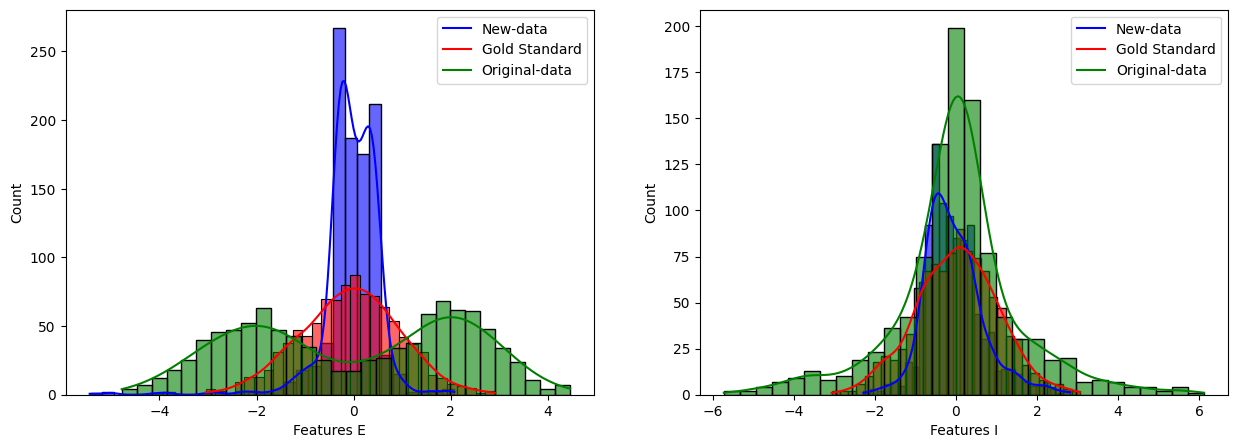

In [ ]:
check(model_train, df_train, df_test, trainer, cfg, 'HGR', 'NotNormal')

Correlation with the sensitive attribute:
Train set: 0.4328
Test set: 0.4753
Original_train: 0.9434
Original_test: 0.9445


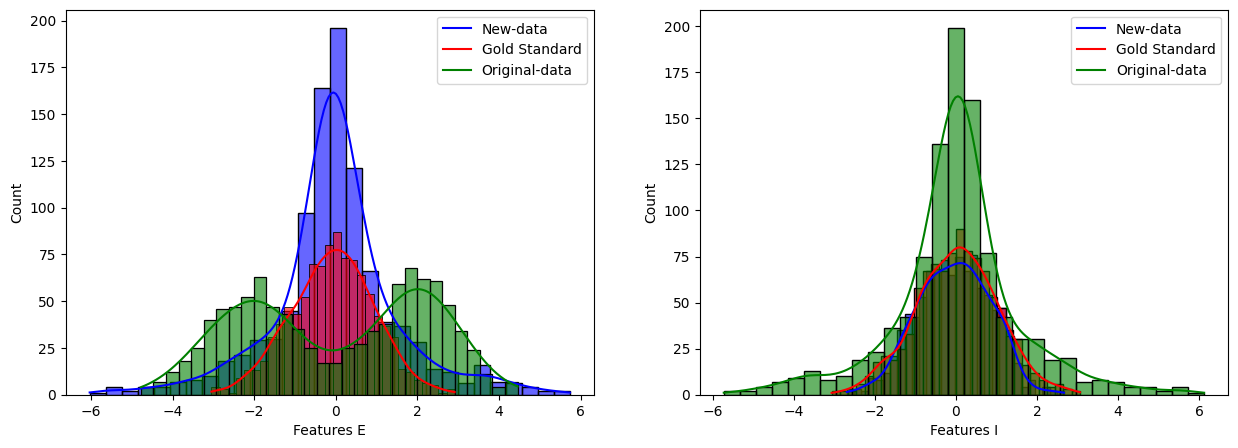

In [ ]:
check(model_train, df_train, df_test, trainer, cfg, 'OB', 'NotNormal')

#### <a id='toc4_1_1_2_'></a>[BiNormal Data](#toc0_)

c:\Users\claud\AppData\Local\Programs\Python\Python312\Lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:425: The 'predict_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=7` in the `DataLoader` to improve performance.


Predicting DataLoader 0: 100%|██████████| 2/2 [00:00<00:00, 46.16it/s]
Correlation with the sensitive attribute:
Train set: 0.3174
Test set: 0.4292
Original_train: 0.8045
Original_test: 0.8063


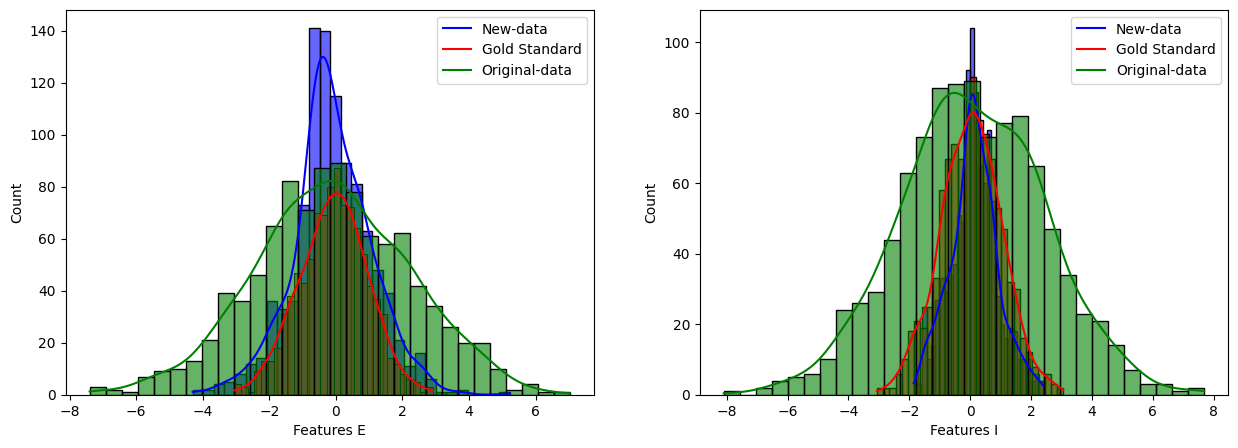

In [ ]:
check(model_train, df_train, df_test, trainer, cfg, 'HGR', 'Normal')

Correlation with the sensitive attribute:
Train set: 0.0532
Test set: 0.1138
Original_train: 0.8045
Original_test: 0.8063


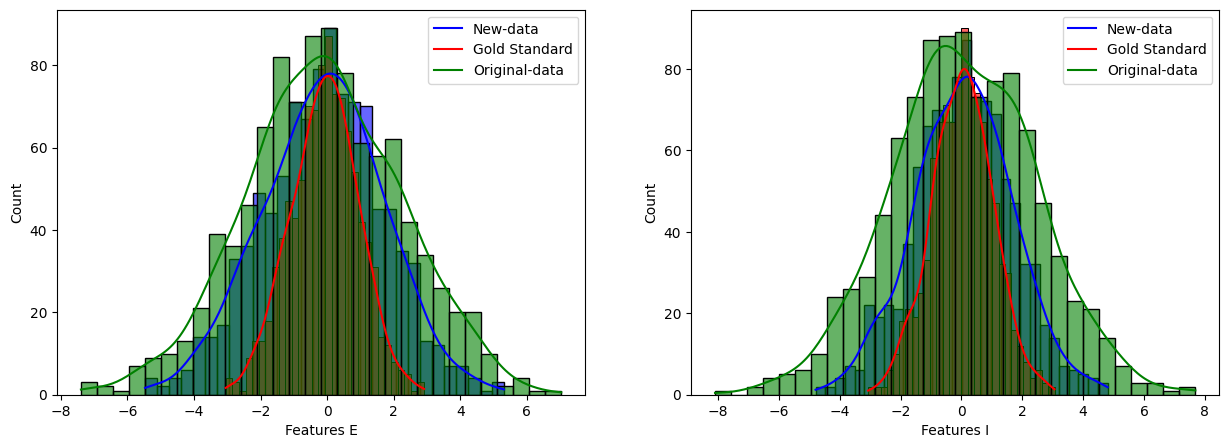

In [ ]:
check(model_train, df_train, df_test, trainer, cfg, 'OB', 'Normal')

#### <a id='toc4_1_1_3_'></a>[Only one feature](#toc0_)

In [ ]:
def check(model_train, train, test, trainer, cfg, method, data):

    if method == 'HGR': #For Test Data
        #Data preparation
        train_data = MyDataset(train)
        train_loader = DataLoader(train_data, batch_size=cfg['batch_size_train'], shuffle=False)
        test_data = MyDataset(test)
        test_loader = DataLoader(test_data, batch_size=cfg['batch_size_test'], shuffle=False)
        x_train_new = trainer.predict(model_train, dataloaders=train_loader)
        x_test_new = trainer.predict(model=model_train, dataloaders=test_loader)
        x_train_new = torch.cat(x_train_new, dim=0)
        x_test_new = torch.cat(x_test_new, dim=0)

        #HGR-value 
        ind = indicator(semantics='hgr', algorithm='dk', backend='torch')
        print('Correlation with the sensitive attribute:')
        print(f'Train set: {ind.compute(x_train_new, train_data.z):.4f}')
        print(f'Test set: {ind.compute(x_test_new, test_data.z):.4f}')
        print(f'Original_train: {ind.compute(train_data.x, train_data.z):.4f}')
        print(f'Original_test: {ind.compute(test_data.x, test_data.z):.4f}')
       
       #For distribution visualization
        gold_standard_UA = test['UA'] 
        A = test['A']
        A_new = x_test_new
        
    if method == 'OB': #For Test Data
        #Data preparation
        if data == 'NotNormal':
            A_train = create_A_orthogonal(train)
            model_OB_base = GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, random_state=42)  #Da vedere altri...
            model_OB = LinearRegression()
            model_OB.fit(train[['A']], A_train)
            A_orthogonal = model_OB.predict(test[['A']])
            #A_orthogonal = create_A_orthogonal(test)

        #HGR Value
        ind = indicator(semantics='hgr', algorithm='dk', backend='numpy')
        print('Correlation with the sensitive attribute:')
        print(f'Train set: {ind.compute(A_train, np.array(train['B'])):.4f}')
        print(f'Test set: {ind.compute(A_orthogonal, np.array(test['B'])):.4f}')
        print(f'Original_train: {ind.compute(np.array(train['A']),np.array(train['B'])):.4f}')
        print(f'Original_test: {ind.compute(np.array(test['A']),np.array(test['B'])):.4f}')

        #For Distribution visualization
        A_new = A_orthogonal
        A = test['A']
        gold_standard_UA = test['UA']
    
    sns.histplot(A_new, kde=True, bins=30, color="blue", alpha=0.6, edgecolor="black")
    sns.histplot(gold_standard_UA, kde=True, bins=30, color="red", alpha=0.6, edgecolor="black")
    sns.histplot(A, kde=True, bins=30, color="green", alpha=0.6, edgecolor="black")
    plt.legend(['New-data', 'Gold Standard', 'Original-data'])
    plt.xlabel('Features A')
    
    plt.show()    

When the correlation bewteen the non-sensitive feature $A$ and the sensitive feature $B$ is done by:
$$
A = f_{sum}(UA, B) =
\begin{cases} 
    UA + 2  & \text{if } B = 1 \\
    UA - 2  & \text{if } B = 0
\end{cases}
= UA - 2 + 4B

Correlation with the sensitive attribute:
Train set: 0.0143
Test set: 0.0207
Original_train: 0.9326
Original_test: 0.9403


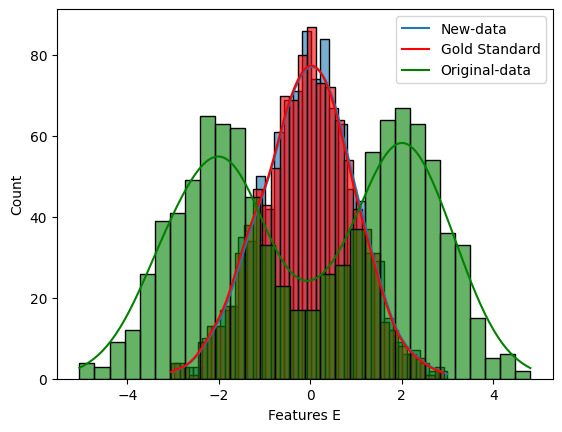

c:\Users\claud\AppData\Local\Programs\Python\Python312\Lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:425: The 'predict_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=7` in the `DataLoader` to improve performance.


Predicting DataLoader 0: 100%|██████████| 2/2 [00:00<00:00, 26.80it/s] 
Correlation with the sensitive attribute:
Train set: 0.0513
Test set: 0.0888
Original_train: 0.9326
Original_test: 0.9403


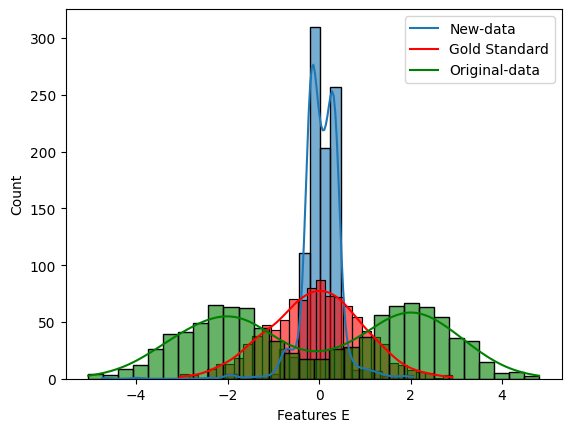

In [63]:
check(model_train, df_train, df_test, trainer, cfg, 'OB', 'NotNormal')
check(model_train, df_train, df_test, trainer, cfg, 'HGR', 'NotNormal')

When the correlation bewteen the non-sensitive feature $A$ and the sensitive feature $B$ is done by:
$$
A = f_{prod}(UA, B) = 
\begin{cases} 
    UA*2  & \text{if } B = 0 \\
    UA/2  & \text{if } B = 1
\end{cases} 
= UA(2 - \frac{3}{2}B)
$$

Correlation with the sensitive attribute:
Train set: 0.4090
Test set: 0.4268
Original_train: 0.4101
Original_test: 0.4323


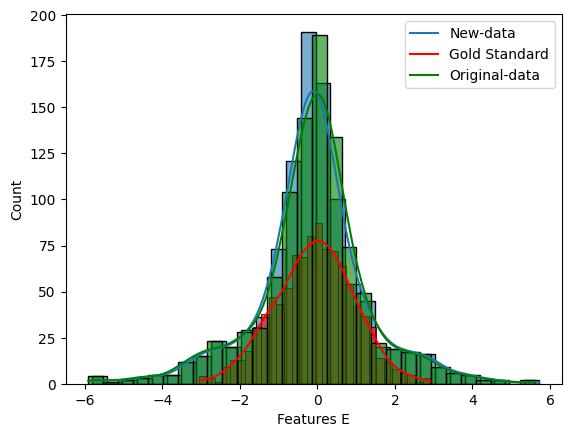

c:\Users\claud\AppData\Local\Programs\Python\Python312\Lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:425: The 'predict_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=7` in the `DataLoader` to improve performance.


Predicting DataLoader 0: 100%|██████████| 2/2 [00:00<00:00, 38.15it/s] 
Correlation with the sensitive attribute:
Train set: 0.0699
Test set: 0.1451
Original_train: 0.4101
Original_test: 0.4323


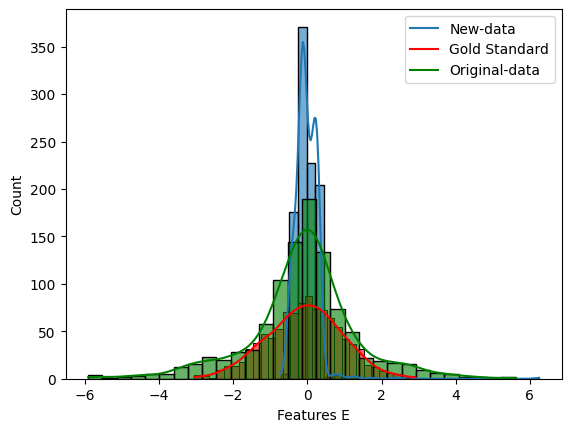

In [ ]:
check(model_train, df_train, df_test, trainer, cfg, 'OB', 'NotNormal')
check(model_train, df_train, df_test, trainer, cfg, 'HGR', 'NotNormal')

## <a id='toc4_1_2_'></a>[Real Data](#toc0_)

In [ ]:
#Data preparation
train_data = MyDataset(df_train)
train_loader = DataLoader(train_data, batch_size=cfg['batch_size_train'], shuffle=False)
test_data = MyDataset(df_test)
test_loader = DataLoader(test_data, batch_size=cfg['batch_size_test'], shuffle=False)
x_train_new = trainer.predict(model_train, dataloaders=train_loader)
x_test_new = trainer.predict(model=model_train, dataloaders=test_loader)
x_train_new = torch.cat(x_train_new, dim=0)
x_test_new = torch.cat(x_test_new, dim=0)
#HGR-value 
ind = indicator(semantics='hgr', algorithm='dk', backend='torch')
print('Correlation with the sensitive attribute with HGR approach:')
print(f'Train set: {ind.compute(x_train_new, train_data.z):.4f}')
print(f'Test set: {ind.compute(x_test_new, test_data.z):.4f}')
print(f'Original_train: {ind.compute(train_data.x, train_data.z):.4f}')
print(f'Original_test: {ind.compute(test_data.x, test_data.z):.4f}')
       

Predicting DataLoader 0: 100%|██████████| 10/10 [00:00<00:00, 28.10it/s]
Correlation with the sensitive attribute with HGR approach:
Train set: 0.3322
Test set: 0.4170
Original_train: 0.6800
Original_test: 0.7009


In [84]:
#Data preparation
train_data = MyDataset(df_train)
train_loader = DataLoader(train_data, batch_size=cfg['batch_size_train'], shuffle=False)
test_data = MyDataset(df_test)
test_loader = DataLoader(test_data, batch_size=cfg['batch_size_test'], shuffle=False)
x_train_new = trainer.predict(model_train, dataloaders=train_loader)
x_test_new = trainer.predict(model=model_train, dataloaders=test_loader)
x_train_new = torch.cat(x_train_new, dim=0)
x_test_new = torch.cat(x_test_new, dim=0)
#Check features per features
ind = indicator(semantics='hgr', algorithm='dk', backend='torch')
features = ['Workclass', 'Education', 'Marital Status', 'Occupation', 'Relationship', 'Hours per week']
new_correlation = []
original_correlation = []
for i in range(6):
    new_correlation.append(ind.compute(x_test_new[:, i], test_data.z))
    original_correlation.append(ind.compute(test_data.x[:, i], test_data.z))
    print(f'{features[i]} attribute: new correlation: {new_correlation[i]:.4f}, original correlation: {original_correlation[i]:.4f}')

print('\n')
print(f'Mean results: new_correlation {np.mean(new_correlation):.4f}, original_correlation {np.mean(original_correlation):.4f}')


Predicting: |          | 0/? [00:00<?, ?it/s]

Predicting DataLoader 0: 100%|██████████| 10/10 [00:00<00:00, 51.84it/s]
Workclass attribute: new correlation: 0.0267, original correlation: 0.1034
Education attribute: new correlation: 0.0246, original correlation: 0.0286
Marital Status attribute: new correlation: 0.0140, original correlation: 0.4520
Occupation attribute: new correlation: 0.0237, original correlation: 0.3070
Relationship attribute: new correlation: 0.0262, original correlation: 0.6400
Hours per week attribute: new correlation: 0.0254, original correlation: 0.2593


Mean results: new_correlation 0.0234, original_correlation 0.2984


In [85]:
#Data preparation
x_train_new = create_A_orthogonal(df_train, ['workclass', 'education', 'marital-status', 'occupation', 'relationship', 'hours-per-week'], 'sex')
x_test_new = create_A_orthogonal(df_test, ['workclass', 'education', 'marital-status', 'occupation', 'relationship', 'hours-per-week'], 'sex')

#Check features per features
features = ['Workclass', 'Education', 'Marital Status', 'Occupation', 'Relationship', 'Hours per week']
new_correlation = []
original_correlation = []
for i in range(6):
    new_correlation.append(ind.compute(x_test_new[:, i], np.array(df_test['sex'])))
    original_correlation.append(ind.compute(test_data.x[:, i], np.array(df_test['sex'])))
    print(f'{features[i]} attribute: new correlation: {new_correlation[i]:.4f}, original correlation: {original_correlation[i]:.4f}')

print('\n')
print(f'Mean results: new_correlation {np.mean(new_correlation):.4f}, original_correlation {np.mean(original_correlation):.4f}')



Workclass attribute: new correlation: 0.0560, original correlation: 0.1034
Education attribute: new correlation: 0.0702, original correlation: 0.0286
Marital Status attribute: new correlation: 0.0292, original correlation: 0.4520
Occupation attribute: new correlation: 0.0353, original correlation: 0.3070
Relationship attribute: new correlation: 0.0421, original correlation: 0.6400
Hours per week attribute: new correlation: 0.0235, original correlation: 0.2593


Mean results: new_correlation 0.0427, original_correlation 0.2984


# <a id='toc5_'></a>[CLASSIFICATION](#toc0_)

For the classification I experiment five different models of sickit-learn: **Decision Teee**, **Logistic Classifier**, **AdaBoost**, **RandomForest** and **Neural Network**.  

In [ ]:
def create_new_data(df_train, df_test, model_train, method):
    if method == 'HGR':
        train_data = MyDataset(df_train)
        train_loader = DataLoader(train_data, batch_size=cfg['batch_size_train'], shuffle=False)
        test_data = MyDataset(df_test)
        test_loader = DataLoader(test_data, batch_size=cfg['batch_size_test'], shuffle=False)
        x_train_new = trainer.predict(model=model_train, dataloaders=train_loader)
        x_test_new = trainer.predict(model=model_train, dataloaders=test_loader)
        X_train_new, X_test_new = np.array(torch.cat(x_train_new, dim=0)), np.array(torch.cat(x_test_new, dim=0))
        scaler = StandardScaler()
        X_train_new = scaler.fit_transform(X_train_new)
        X_test_new = scaler.transform(X_test_new)
    if method == 'OB':
        X_train_new = create_A_orthogonal(df_train, ['workclass', 'education', 'marital-status', 'occupation', 'relationship', 'hours-per-week'], 'sex')
        model_OB = MultiOutputRegressor(model_OB_base)
        model_OB_base = GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, random_state=42)
        model_OB.fit(df_train[['E', 'I']], X_train_new)
        X_test_new = model_OB.predict(df_test[['E', 'I']])
        X_test_new = create_A_orthogonal(df_test,  ['workclass', 'education', 'marital-status', 'occupation', 'relationship', 'hours-per-week'], 'sex')
        scaler = StandardScaler()
        X_train_new = scaler.fit_transform(X_train_new)
        X_test_new = scaler.transform(X_test_new)
    return X_train_new, X_test_new

def create_old_data(df_train, df_test, colums):
    X_train_old, X_test_old = np.array(df_train[colums]), np.array(df_test[colums])
    scaler = StandardScaler()
    X_train_old = scaler.fit_transform(X_train_old)
    X_test_old = scaler.transform(X_test_old)
    return X_train_old, X_test_old

def create_y(df_train, df_test, target):
    y_train, y_test = np.array(df_train[target]).reshape(-1), np.array(df_test[target]).reshape(-1)
    y_gold = np.array(df_test['Y-hat'])
    #y_gold = y_test
    return y_train, y_test, y_gold

#def create_y(df_train, df_test, model_train, method):
#    if method == 'HGR':
#        train_data = MyDataset(df_train)
#        train_loader = DataLoader(train_data, batch_size=cfg['batch_size_train'], shuffle=False)
#        test_data = MyDataset(df_test)
#        test_loader = DataLoader(test_data, batch_size=cfg['batch_size_test'], shuffle=False)
#        x_train_new = trainer.predict(model=model_train, dataloaders=train_loader)
#        x_test_new = trainer.predict(model=model_train, dataloaders=test_loader)
#        X_train_new, X_test_new = np.array(torch.cat(x_train_new, dim=0)), np.array(torch.cat(x_test_new, dim=0))
#        y_train_new = (X_train_new[:, -1] >= 0.5).astype(int)
#        y_test_new = (X_test_new[:, -1] >= 0.5).astype(int)
#        y_train_old = np.array(df_train['income_>50K'])
#        y_test_old = np.array(df_test['income_>50K'])
#        y_gold = y_test_old
#    if method == 'OB':
#        X_train_new = create_A_orthogonal(df_train, ['workclass', 'education', 'marital-status', 'occupation', 'relationship', 'hours-per-week', 'income_>50K'], 'sex')
#        #model_OB = MultiOutputRegressor(model_OB_base)
#        #model_OB_base = GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, random_state=42)
#        #model_OB.fit(df_train[['E', 'I']], X_train_new)
#        #X_test_new = model_OB.predict(df_test[['E', 'I']])
#        X_test_new = create_A_orthogonal(df_test,  ['workclass', 'education', 'marital-status', 'occupation', 'relationship', 'hours-per-week', 'income_>50K'], 'sex')
#        y_train_new = (X_train_new[:, -1] >= 0.5).astype(int)
#        y_test_new = (X_test_new[:, -1] >= 0.5).astype(int)
#        y_train_old = np.array(df_train['income_>50K'])
#        y_test_old = np.array(df_test['income_>50K'])
#        y_gold = y_test_old
#    return y_train_new, y_test_new, y_train_old, y_test_old, y_gold

    

In [86]:
def equalized_odds(y_true, y_pred, sensitive_attribute):
    groups = np.unique(sensitive_attribute)
    tpr_fpr_by_group = {}

    for group in groups:
        group_indices = sensitive_attribute.ravel() == group
        group_y_true = y_true[group_indices]
        group_y_pred = y_pred[group_indices]
        tn, fp, fn, tp = confusion_matrix(group_y_true, group_y_pred).ravel()
        tpr = tp / (tp + fn) if (tp + fn) > 0 else 0
        fpr = fp / (fp + tn) if (fp + tn) > 0 else 0
        tpr_fpr_by_group[group] = {'tpr': tpr, 'fpr': fpr}

    tprs = [tpr_fpr_by_group[group]['tpr'] for group in groups]
    fprs = [tpr_fpr_by_group[group]['fpr'] for group in groups]

    disparities = {
        'tpr_diff': max(tprs) - min(tprs),
        'fpr_diff': max(fprs) - min(fprs),
    }

    return disparities

def demographic_parity(y_true, y_pred, sensitive_attribute):
    groups = np.unique(sensitive_attribute)
    acceptance_rates = {}

    for group in groups:
        group_indices = sensitive_attribute.ravel() == group
        group_y_pred = y_pred[group_indices]
        group_y_true = y_true[group_indices]
        tn, fp, fn, tp = confusion_matrix(group_y_true, group_y_pred).ravel()
        acceptance_rate = (tp + fp)/(tp + fp + tn + fn) if (tp + fp + tn + fn) > 0 else 0
        acceptance_rates[group] = acceptance_rate
        
    disparities = np.abs(acceptance_rates[0] - acceptance_rates[1])

    return disparities

In [93]:
def classification(X_train, X_test, y_train, y_test, y_gold, clf_model, sensitive_attribute, normal):
    clf = clf_model
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    y_prob = clf.predict_proba(X_test)
    accuracy, aupr = {}, {}
    accuracy['Biased'] = accuracy_score(y_test, y_pred)
    aupr['Biased'] = average_precision_score(y_test, y_prob[:,1])
    accuracy['Gold'] = accuracy_score(y_gold, y_pred)
    aupr['Gold'] = average_precision_score(y_gold, y_prob[:,1])
    ind = indicator(semantics='hgr', algorithm='dk', backend='numpy')
    fairness = ind.compute(y_pred, sensitive_attribute)
    if normal == False: 
        eo = equalized_odds(y_test, y_pred, sensitive_attribute)
        dp = demographic_parity(y_test, y_pred, sensitive_attribute)
    if normal == True:
        eo = 0.0
        dp = 0.0
    return accuracy, aupr, fairness, eo, dp


In [91]:
def evaluate_clf(clf_dictionary, df_train, df_test, model_train, method):
    X_train_old, X_test_old = create_old_data(df_train, df_test, ['workclass', 'education', 'marital-status', 'occupation', 'relationship', 'hours-per-week'] )
    y_train, y_test, y_gold = create_y(df_train, df_test, 'income_>50K')
    X_train_new, X_test_new = create_new_data(df_train, df_test, model_train, method)
    
    accuracy = {}
    AUPR = {}
    HGR = {}
    EO = {}
    DP = {}
    
    for key, values in clf_dictionary.items():
        accuracy_new, aupr_new, fairness_new, equalized_odd_new, dem_parity_new = classification(X_train_new, X_test_new, y_train, y_test, y_gold, values, np.array(df_test['sex']), False)
        accuracy_old, aupr_old, fairness_old, equalize_odd_old, dem_parity_old  = classification(X_train_old, X_test_old, y_train, y_test, y_gold, values, np.array(df_test['sex']), False)
        tpr_odds_new, tpr_odds_old = equalized_odd_new['tpr_diff'], equalize_odd_old['tpr_diff']
        #tpr_odds_new, tpr_odds_old = equalized_odd_new, equalize_odd_old
        print('Model: ', key)
        print(f'Accuracy_new: {accuracy_new['Biased']:.4f}, AUPRC_new: {aupr_new['Biased']:.4f}, Accuracy_new_gold: {accuracy_new['Gold']:.4f}, AUPRC_new_gold: {aupr_new['Gold']:.4f}, Fairness_new: {fairness_new:.4f}, Equalized Odds: {tpr_odds_new:.4f}, Demographic Parity: {dem_parity_new:.4f}')
        print(f'Accuracy_old: {accuracy_old['Biased']:.4f}, AUPRC_old: {aupr_old['Biased']:.4f}, Accuracy_old_gold: {accuracy_old['Gold']:.4f}, AUPRC_old_gold: {aupr_old['Gold']:.4f}, Fairness_old: {fairness_old:.4f}, Equalized Odds: {tpr_odds_old:.4f}, Demographic Parity: {dem_parity_old:.4f}')
        
        accuracy[key] = accuracy_new
        AUPR[key] = aupr_new
        HGR[key] = fairness_new
        EO[key] = tpr_odds_new
        DP[key] = dem_parity_new
    print('\n')
    
    return accuracy, AUPR, HGR, EO, DP

In [94]:
import warnings
warnings.filterwarnings("ignore")

clf_tree = DecisionTreeClassifier(random_state=seed)
clf_log = LogisticRegression(random_state=seed)
clf_forest  = RandomForestClassifier(random_state=seed)
clf_boost = AdaBoostClassifier(random_state=seed)
clf_neural = MLPClassifier(random_state=seed)
clf_dictionary = {'DecisionTree': clf_tree, 'LogisticRegression': clf_log, 'RandomForest': clf_forest, 'AdaBoost': clf_boost, 'NeuralNetwork': clf_neural}
accuracy, AUPR, HGR, EO, DP = evaluate_clf(clf_dictionary, df_train, df_test, model_train, 'OB')


Model:  DecisionTree
Accuracy_new: 0.6772, AUPRC_new: 0.2448, Accuracy_new_gold: 0.6772, AUPRC_new_gold: 0.2448, Fairness_new: 0.0346, Equalized Odds: 0.1175, Demographic Parity: 0.0272
Accuracy_old: 0.8140, AUPRC_old: 0.5389, Accuracy_old_gold: 0.8140, AUPRC_old_gold: 0.5389, Fairness_old: 0.1952, Equalized Odds: 0.1046, Demographic Parity: 0.1673
Model:  LogisticRegression
Accuracy_new: 0.2508, AUPRC_new: 0.2925, Accuracy_new_gold: 0.2508, AUPRC_new_gold: 0.2925, Fairness_new: 0.0073, Equalized Odds: 0.0087, Demographic Parity: 0.0017
Accuracy_old: 0.7539, AUPRC_old: 0.4271, Accuracy_old_gold: 0.7539, AUPRC_old_gold: 0.4271, Fairness_old: 0.1341, Equalized Odds: 0.0911, Demographic Parity: 0.0615
Model:  RandomForest
Accuracy_new: 0.7577, AUPRC_new: 0.2203, Accuracy_new_gold: 0.7577, AUPRC_new_gold: 0.2203, Fairness_new: 0.0000, Equalized Odds: 0.0000, Demographic Parity: 0.0000
Accuracy_old: 0.8226, AUPRC_old: 0.6471, Accuracy_old_gold: 0.8226, AUPRC_old_gold: 0.6471, Fairness_old: 

In [38]:
def multiple_training(cfg, train ,test, num, filename):

    early_stopping = EarlyStopping(monitor='lagrangian_loss', mode='min', patience=15,verbose=True)
    model = buidNNmodel(cfg['input_shape'], cfg['hidden_shape'], cfg['output_shape'])
    model_train = prepare_train(cfg, model)
    logger = TensorBoardLogger("lightning_logs", name=cfg['method'])
    trainer = L.Trainer(callbacks=[early_stopping], max_epochs=cfg['epochs'], logger=logger)

    clf_tree = DecisionTreeClassifier(random_state=seed)
    clf_log = LogisticRegression(random_state=seed)
    clf_forest  = RandomForestClassifier(random_state=seed)
    clf_boost = AdaBoostClassifier(random_state=seed)
    clf_neural = MLPClassifier(random_state=seed)
    clf_dictionary = {'DecisionTree': clf_tree, 'LogisticRegression': clf_log, 'RandomForest': clf_forest, 'AdaBoost': clf_boost, 'NeuralNetwork': clf_neural}
    
    tree = {'accuracy_biased' : [], 'AUPR_biased' : [], 'accuracy_gold' : [], 'AUPR_gold' : [], 'HGR' : [], 'EO' : [], 'DP' : []}
    log = {'accuracy_biased' : [], 'AUPR_biased' : [], 'accuracy_gold' : [], 'AUPR_gold' : [], 'HGR' : [], 'EO' : [], 'DP' : []}
    forest = {'accuracy_biased' : [], 'AUPR_biased' : [], 'accuracy_gold' : [], 'AUPR_gold' : [], 'HGR' : [], 'EO' : [], 'DP' : []}
    boost = {'accuracy_biased' : [], 'AUPR_biased' : [], 'accuracy_gold' : [], 'AUPR_gold' : [], 'HGR' : [], 'EO' : [], 'DP' : []}
    neural = {'accuracy_biased' : [], 'AUPR_biased' : [], 'accuracy_gold' : [], 'AUPR_gold' : [], 'HGR' : [], 'EO' : [], 'DP' : []}


    for i in range(num):
        print(f'Run number: {i+1}')
        early_stopping = EarlyStopping(monitor='lagrangian_loss', mode='min', patience=15,verbose=True)
        model = buidNNmodel(cfg['input_shape'], cfg['hidden_shape'], cfg['output_shape'])
        model_train = prepare_train(cfg, model)
        logger = TensorBoardLogger("lightning_logs", name=cfg['method'])
        trainer = L.Trainer(callbacks=[early_stopping], max_epochs=cfg['epochs'], logger=logger)
        training_loop(train, cfg, model_train, trainer)
        accuracy, aupr, HGR, EO, DP = evaluate_clf(clf_dictionary, train, test, model_train, 'HGR')
        tree['accuracy_biased'].append(accuracy['DecisionTree']['Biased']), tree['AUPR_biased'].append(aupr['DecisionTree']['Biased']), tree['accuracy_gold'].append(accuracy['DecisionTree']['Gold']), tree['AUPR_gold'].append(aupr['DecisionTree']['Gold']), tree['HGR'].append(HGR['DecisionTree']), tree['EO'].append(EO['DecisionTree']), tree['DP'].append(DP['DecisionTree'])
        log['accuracy_biased'].append(accuracy['LogisticRegression']['Biased']), log['AUPR_biased'].append(aupr['LogisticRegression']['Biased']), log['accuracy_gold'].append(accuracy['LogisticRegression']['Gold']), log['AUPR_gold'].append(aupr['LogisticRegression']['Gold']), log['HGR'].append(HGR['LogisticRegression']), log['EO'].append(EO['LogisticRegression']), log['DP'].append(DP['LogisticRegression'])
        forest['accuracy_biased'].append(accuracy['RandomForest']['Biased']), forest['AUPR_biased'].append(aupr['RandomForest']['Biased']), forest['accuracy_gold'].append(accuracy['RandomForest']['Gold']), forest['AUPR_gold'].append(aupr['RandomForest']['Gold']), forest['HGR'].append(HGR['RandomForest']), forest['EO'].append(EO['RandomForest']), forest['DP'].append(DP['RandomForest'])
        boost['accuracy_biased'].append(accuracy['AdaBoost']['Biased']), boost['AUPR_biased'].append(aupr['AdaBoost']['Biased']), boost['accuracy_gold'].append(accuracy['AdaBoost']['Gold']), boost['AUPR_gold'].append(aupr['AdaBoost']['Gold']), boost['HGR'].append(HGR['AdaBoost']), boost['EO'].append(EO['AdaBoost']), boost['DP'].append(DP['AdaBoost'])
        neural['accuracy_biased'].append(accuracy['NeuralNetwork']['Biased']), neural['AUPR_biased'].append(aupr['NeuralNetwork']['Biased']), neural['accuracy_gold'].append(accuracy['NeuralNetwork']['Gold']), neural['AUPR_gold'].append(aupr['NeuralNetwork']['Gold']), neural['HGR'].append(HGR['NeuralNetwork']), neural['EO'].append(EO['NeuralNetwork']), neural['DP'].append(DP['NeuralNetwork'])

    with open(filename, 'w') as f:
        json.dump([tree, log, forest, boost, neural], f, indent=4)

    print('\n')
    print('Model: Tree')
    print(f'[Accuracy_new: {np.mean(tree['accuracy_biased']):.4f}, {np.std(tree['accuracy_biased'])}], [AUPRC_new: {np.mean(tree['AUPR_biased']):.4f}, {np.std(tree['AUPR_biased'])}], [Accuracy_new_gold : {np.mean(tree["accuracy_gold"]):.4f}, {np.std(tree['accuracy_gold']):.4f}], [AUPR_new_gold : {np.mean(tree['AUPR_gold']):.4f}, {np.std(tree["AUPR_gold"]):.4f}], [Fairness_new: {np.mean(tree['HGR']):.4f}, {np.std(tree['HGR']):.4f}], [Equalized Odds: {np.mean(tree['EO']):.4f}, {np.std(tree['EO']):.4f}], [Demographic Parity: {np.mean(tree['DP']):.4f}, {np.std(tree['DP']):.4f}]')
    print('Model: Log')
    print(f'[Accuracy_new: {np.mean(log['accuracy_biased']):.4f}, {np.std(log['accuracy_biased'])}], [AUPRC_new: {np.mean(log['AUPR_biased']):.4f}, {np.std(log['AUPR_biased'])}], [Accuracy_new_gold : {np.mean(log["accuracy_gold"]):.4f}, {np.std(log['accuracy_gold']):.4f}], [AUPR_new_gold : {np.mean(log['AUPR_gold']):.4f}, {np.std(log["AUPR_gold"]):.4f}], [Fairness_new: {np.mean(log['HGR']):.4f}, {np.std(log['HGR']):.4f}], [Equalized Odds: {np.mean(log['EO']):.4f}, {np.std(log['EO']):.4f}], [Demographic Parity: {np.mean(log['DP']):.4f}, {np.std(log['DP']):.4f}]')
    print('Model: Forest')
    print(f'[Accuracy_new: {np.mean(forest['accuracy_biased']):.4f}, {np.std(forest['accuracy_biased'])}], [AUPRC_new: {np.mean(forest['AUPR_biased']):.4f}, {np.std(forest['AUPR_biased'])}], [Accuracy_new_gold : {np.mean(forest["accuracy_gold"]):.4f}, {np.std(forest['accuracy_gold']):.4f}], [AUPR_new_gold : {np.mean(forest['AUPR_gold']):.4f}, {np.std(forest["AUPR_gold"]):.4f}], [Fairness_new: {np.mean(forest['HGR']):.4f}, {np.std(forest['HGR']):.4f}], [Equalized Odds: {np.mean(forest['EO']):.4f}, {np.std(forest['EO']):.4f}], [Demographic Parity: {np.mean(forest['DP']):.4f}, {np.std(forest['DP']):.4f}]')
    print('Model: Boost')
    print(f'[Accuracy_new: {np.mean(boost['accuracy_biased']):.4f}, {np.std(boost['accuracy_biased'])}], [AUPRC_new: {np.mean(boost['AUPR_biased']):.4f}, {np.std(boost['AUPR_biased'])}], [Accuracy_new_gold : {np.mean(boost["accuracy_gold"]):.4f}, {np.std(boost['accuracy_gold']):.4f}], [AUPR_new_gold : {np.mean(boost['AUPR_gold']):.4f}, {np.std(boost["AUPR_gold"]):.4f}], [Fairness_new: {np.mean(boost['HGR']):.4f}, {np.std(boost['HGR']):.4f}], [Equalized Odds: {np.mean(boost['EO']):.4f}, {np.std(boost['EO']):.4f}], [Demographic Parity: {np.mean(boost['DP']):.4f}, {np.std(boost['DP']):.4f}]')
    print('Model: Neuarl')
    print(f'[Accuracy_new: {np.mean(neural['accuracy_biased']):.4f}, {np.std(neural['accuracy_biased'])}], [AUPRC_new: {np.mean(neural['AUPR_biased']):.4f}, {np.std(neural['AUPR_biased'])}], [Accuracy_new_gold : {np.mean(neural["accuracy_gold"]):.4f}, {np.std(neural['accuracy_gold']):.4f}], [AUPR_new_gold : {np.mean(neural['AUPR_gold']):.4f}, {np.std(neural["AUPR_gold"]):.4f}], [Fairness_new: {np.mean(neural['HGR']):.4f}, {np.std(neural['HGR']):.4f}], [Equalized Odds: {np.mean(neural['EO']):.4f}, {np.std(neural['EO']):.4f}], [Demographic Parity: {np.mean(neural['DP']):.4f}, {np.std(neural['DP']):.4f}]')


In [39]:
cfg['method'] = 'costum_loss_1'
cfg['epsilon'] = 0.05
multiple_training(cfg, df_train, df_test, 5)

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs

  | Name  | Type        | Params | Mode 
----------------------------------------------
0 | model | buidNNmodel | 17.2 K | train
----------------------------------------------
17.2 K    Trainable params
0         Non-trainable params
17.2 K    Total params
0.069     Total estimated model params size (MB)
11        Modules in train mode
0         Modules in eval mode


Run number: 1
Epoch 0: 100%|██████████| 10/10 [00:00<00:00, 16.02it/s, v_num=28, lagrangian_loss=1.440, constraint=0.343]

Metric lagrangian_loss improved. New best score: 1.443


Epoch 1: 100%|██████████| 10/10 [00:00<00:00, 12.54it/s, v_num=28, lagrangian_loss=0.859, constraint=0.152]

Metric lagrangian_loss improved by 0.584 >= min_delta = 0.0. New best score: 0.859


...

Epoch 24: 100%|██████████| 10/10 [00:00<00:00, 16.17it/s, v_num=32, lagrangian_loss=0.515, constraint=0.028] 

Metric lagrangian_loss improved by 0.022 >= min_delta = 0.0. New best score: 0.515


Epoch 39: 100%|██████████| 10/10 [00:00<00:00, 15.59it/s, v_num=32, lagrangian_loss=0.557, constraint=0.043] 

Monitored metric lagrangian_loss did not improve in the last 15 records. Best score: 0.515. Signaling Trainer to stop.


Predicting DataLoader 0: 100%|██████████| 2/2 [00:00<00:00, 61.76it/s]
Model:  DecisionTree
Accuracy_new: 0.5850, AUPRC_new: 0.5498, Accuracy_new_gold: 0.5110, AUPRC_new_gold: 0.5036, Fairness_new: 0.2053, Equalized Odds: 0.0000, Demographic Parity: 0.0000
Accuracy_old: 0.6880, AUPRC_old: 0.6310, Accuracy_old_gold: 0.5620, AUPRC_old_gold: 0.5330, Fairness_old: 0.4402, Equalized Odds: 0.0000, Demographic Parity: 0.0000
Model:  LogisticRegression
Accuracy_new: 0.5250, AUPRC_new: 0.5478, Accuracy_new_gold: 0.5250, AUPRC_new_gold: 0.5230, Fairness_new: 0.1199, Equalized Odds: 0.0000, Demographic Parity: 0.0000
Accuracy_old: 0.7610, AUPRC_old: 0.8622, Accuracy_old_gold: 0.5690, AUPRC_old_gold: 0.6169, Fairness_old: 0.6653, Equalized Odds: 0.0000, Demographic Parity: 0.0000
Model:  RandomForest
Accuracy_new: 0.6290, AUPRC_new: 0.6447, Accuracy_new_gold: 0.5470, AUPRC_new_gold: 0.5442, Fairness_new: 0.2742, Equalized Odds: 0.0000, Demographic Parity: 0.0000
Accuracy_old: 0.7360, AUPRC_old: 0.

In [50]:
cfg['method'] = 'costum_loss_2'
cfg['epsilon'] = 0.05
multiple_training(cfg, df_train, df_test, 5)

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs

  | Name  | Type        | Params | Mode 
----------------------------------------------
0 | model | buidNNmodel | 17.2 K | train
----------------------------------------------
17.2 K    Trainable params
0         Non-trainable params
17.2 K    Total params
0.069     Total estimated model params size (MB)
11        Modules in train mode
0         Modules in eval mode


Run number: 1
Epoch 0: 100%|██████████| 10/10 [00:12<00:00,  0.83it/s, v_num=11, lagrangian_loss=1.050, constraint=0.327]

Metric lagrangian_loss improved. New best score: 1.050


Epoch 1: 100%|██████████| 10/10 [00:11<00:00,  0.85it/s, v_num=11, lagrangian_loss=0.792, constraint=0.249]

Metric lagrangian_loss improved by 0.258 >= min_delta = 0.0. New best score: 0.792


...

Epoch 46: 100%|██████████| 10/10 [00:15<00:00,  0.67it/s, v_num=15, lagrangian_loss=0.156, constraint=0.0493]

Metric lagrangian_loss improved by 0.026 >= min_delta = 0.0. New best score: 0.156


Epoch 61: 100%|██████████| 10/10 [00:13<00:00,  0.71it/s, v_num=15, lagrangian_loss=0.175, constraint=0.0556]

Monitored metric lagrangian_loss did not improve in the last 15 records. Best score: 0.156. Signaling Trainer to stop.


Predicting DataLoader 0: 100%|██████████| 2/2 [00:00<00:00, 119.58it/s]
Model:  DecisionTree
Accuracy_new: 0.5740, AUPRC_new: 0.5423, Accuracy_new_gold: 0.4940, AUPRC_new_gold: 0.4951, Fairness_new: 0.2457, Equalized Odds: 0.0000, Demographic Parity: 0.0000
Accuracy_old: 0.6880, AUPRC_old: 0.6310, Accuracy_old_gold: 0.5620, AUPRC_old_gold: 0.5330, Fairness_old: 0.4402, Equalized Odds: 0.0000, Demographic Parity: 0.0000
Model:  LogisticRegression
Accuracy_new: 0.5390, AUPRC_new: 0.5572, Accuracy_new_gold: 0.5170, AUPRC_new_gold: 0.5324, Fairness_new: 0.0489, Equalized Odds: 0.0000, Demographic Parity: 0.0000
Accuracy_old: 0.7610, AUPRC_old: 0.8622, Accuracy_old_gold: 0.5690, AUPRC_old_gold: 0.6169, Fairness_old: 0.6653, Equalized Odds: 0.0000, Demographic Parity: 0.0000
Model:  RandomForest
Accuracy_new: 0.6010, AUPRC_new: 0.6476, Accuracy_new_gold: 0.5090, AUPRC_new_gold: 0.5111, Fairness_new: 0.2705, Equalized Odds: 0.0000, Demographic Parity: 0.0000
Accuracy_old: 0.7360, AUPRC_old: 0

In [254]:
cfg['method'] = 'costum_loss_3'
cfg['epsilon'] = 0.95
multiple_training(cfg, df_train, df_test, 5)

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs

  | Name  | Type        | Params | Mode 
----------------------------------------------
0 | model | buidNNmodel | 17.2 K | train
----------------------------------------------
17.2 K    Trainable params
0         Non-trainable params
17.2 K    Total params
0.069     Total estimated model params size (MB)
11        Modules in train mode
0         Modules in eval mode


Run number: 1
Epoch 0: 100%|██████████| 10/10 [00:00<00:00, 19.20it/s, v_num=5, lagrangian_loss=0.888, constraint=0.0783]

Metric lagrangian_loss improved. New best score: 0.888


Epoch 1: 100%|██████████| 10/10 [00:00<00:00, 17.99it/s, v_num=5, lagrangian_loss=0.617, constraint=0.00132]

Metric lagrangian_loss improved by 0.271 >= min_delta = 0.0. New best score: 0.617


...

Epoch 48: 100%|██████████| 10/10 [00:00<00:00, 23.09it/s, v_num=9, lagrangian_loss=0.0827, constraint=0.00128] 

Metric lagrangian_loss improved by 0.004 >= min_delta = 0.0. New best score: 0.083


Epoch 63: 100%|██████████| 10/10 [00:00<00:00, 21.82it/s, v_num=9, lagrangian_loss=0.0926, constraint=0.000873]

Monitored metric lagrangian_loss did not improve in the last 15 records. Best score: 0.083. Signaling Trainer to stop.


Predicting DataLoader 0: 100%|██████████| 2/2 [00:00<00:00, 162.87it/s]
Model:  DecisionTree
Accuracy_new: 0.5610, AUPRC_new: 0.5303, Accuracy_new_gold: 0.5410, AUPRC_new_gold: 0.5202, Fairness_new: 0.0861, Equalized Odds: 0.1758, Demographic Parity: 0.0861
Accuracy_old: 0.6340, AUPRC_old: 0.5822, Accuracy_old_gold: 0.5280, AUPRC_old_gold: 0.5128, Fairness_old: 0.4311, Equalized Odds: 0.4389, Demographic Parity: 0.4302
Model:  LogisticRegression
Accuracy_new: 0.5880, AUPRC_new: 0.5525, Accuracy_new_gold: 0.5740, AUPRC_new_gold: 0.5812, Fairness_new: 0.0820, Equalized Odds: 0.1672, Demographic Parity: 0.0817
Accuracy_old: 0.7340, AUPRC_old: 0.8104, Accuracy_old_gold: 0.5600, AUPRC_old_gold: 0.6223, Fairness_old: 0.7897, Equalized Odds: 0.8205, Demographic Parity: 0.7809
Model:  RandomForest
Accuracy_new: 0.5810, AUPRC_new: 0.5936, Accuracy_new_gold: 0.5530, AUPRC_new_gold: 0.5379, Fairness_new: 0.1313, Equalized Odds: 0.1862, Demographic Parity: 0.1313
Accuracy_old: 0.7040, AUPRC_old: 0

In [ ]:
cfg['method'] = 'costum_loss_4'
cfg['epsilon'] = 0.95
multiple_training(cfg, df_train, df_test, 5)

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs

  | Name  | Type        | Params | Mode 
----------------------------------------------
0 | model | buidNNmodel | 17.2 K | train
----------------------------------------------
17.2 K    Trainable params
0         Non-trainable params
17.2 K    Total params
0.069     Total estimated model params size (MB)
11        Modules in train mode
0         Modules in eval mode


Run number: 1
Epoch 0: 100%|██████████| 10/10 [00:02<00:00,  3.67it/s, v_num=5, lagrangian_loss=0.475, constraint=0.0141]

Metric lagrangian_loss improved. New best score: 0.475


Epoch 1: 100%|██████████| 10/10 [00:02<00:00,  4.42it/s, v_num=5, lagrangian_loss=0.243, constraint=0.000391]

Metric lagrangian_loss improved by 0.232 >= min_delta = 0.0. New best score: 0.243


...

Epoch 61: 100%|██████████| 10/10 [00:02<00:00,  4.30it/s, v_num=9, lagrangian_loss=0.0927, constraint=0.000]

Metric lagrangian_loss improved by 0.004 >= min_delta = 0.0. New best score: 0.093


Epoch 76: 100%|██████████| 10/10 [00:02<00:00,  4.48it/s, v_num=9, lagrangian_loss=0.100, constraint=0.000]  

Monitored metric lagrangian_loss did not improve in the last 15 records. Best score: 0.093. Signaling Trainer to stop.


Predicting DataLoader 0: 100%|██████████| 2/2 [00:00<00:00, 107.17it/s]
Model:  DecisionTree
Accuracy_new: 0.5700, AUPRC_new: 0.5359, Accuracy_new_gold: 0.5100, AUPRC_new_gold: 0.5031, Fairness_new: 0.1756, Equalized Odds: 0.2317, Demographic Parity: 0.1757
Accuracy_old: 0.6340, AUPRC_old: 0.5822, Accuracy_old_gold: 0.5280, AUPRC_old_gold: 0.5128, Fairness_old: 0.4311, Equalized Odds: 0.4389, Demographic Parity: 0.4302
Model:  LogisticRegression
Accuracy_new: 0.5400, AUPRC_new: 0.5258, Accuracy_new_gold: 0.5560, AUPRC_new_gold: 0.5869, Fairness_new: 0.0423, Equalized Odds: 0.0254, Demographic Parity: 0.0422
Accuracy_old: 0.7340, AUPRC_old: 0.8104, Accuracy_old_gold: 0.5600, AUPRC_old_gold: 0.6223, Fairness_old: 0.7897, Equalized Odds: 0.8205, Demographic Parity: 0.7809
Model:  RandomForest
Accuracy_new: 0.6030, AUPRC_new: 0.6534, Accuracy_new_gold: 0.5130, AUPRC_new_gold: 0.5395, Fairness_new: 0.3147, Equalized Odds: 0.3890, Demographic Parity: 0.3148
Accuracy_old: 0.7040, AUPRC_old: 0

# <a id='toc6_'></a>[ BASELINE FAIRNESS](#toc0_)
As a baseline approach to fairness, I experiment with the 'classical' knowledge injection during the training of the classifier, thanks to a fairness constraint implemented with a Lagrangian method. The specific loss to training the clasifier is: 
$$
L(\theta, X, Z, Y) = CrossEntropy(F(\theta, X), Y) + \lambda\max(0, HGR(F(\theta,X), Z) - \epsilon)
$$
Of course for this approach the knowledge of the sensitive attribute to training the classifier is required.

In [ ]:
#Pytoch classificator (perchè effettivamente come posso implementare la baseline di feirness con sklearn?)
class ClassifierModel(nn.Module):
    def __init__(self, input_shape, hidden_shape, num_classes, dropout_rate=0.3):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(input_shape, hidden_shape),
            nn.BatchNorm1d(hidden_shape),  
            nn.ReLU(),
            nn.Dropout(dropout_rate),  
            nn.Linear(hidden_shape, num_classes)
        )

    def forward(self, x):
        return self.model(x)

    
class NewDataset(Dataset):
    def __init__(self, df, x_new):
        self.z =  torch.tensor(df['B'].values, dtype=torch.float32).unsqueeze(1) 
        self.x = (x_new - torch.mean(x_new, dim = 0))/torch.std(x_new, dim=0)
        self.y = torch.tensor(df['Y'].values, dtype=torch.long).unsqueeze(1)

    def __len__(self):
        return len(self.z)
    
    def __getitem__(self, idx):
        return self.z[idx], self.x[idx], self.y[idx]        

In [40]:
def create_data(train, test, model_train, cfg):
    train_data, test_data = MyDataset(train), MyDataset(test)
    train_loader_test = DataLoader(train_data, batch_size=cfg['batch_size_train'], shuffle=False)
    test_loader = DataLoader(test_data, batch_size=cfg['batch_size_test'], shuffle=False)
    x_train_new, x_test_new = trainer.predict(model=model_train, dataloaders=train_loader_test), trainer.predict(model=model_train, dataloaders=test_loader)
    train_new_data, test_new_data = NewDataset(train, torch.cat(x_train_new)), NewDataset(test, torch.cat(x_test_new))
    train_loader_new, test_loader_new = DataLoader(train_new_data, batch_size = cfg['batch_size_train'], shuffle=True), DataLoader(test_new_data, batch_size=cfg['batch_size_test'], shuffle=False)
    train_loader_old, test_loader_old = DataLoader(train_data, batch_size = cfg['batch_size_train'], shuffle=True), DataLoader(test_data, batch_size=cfg['batch_size_test'], shuffle=False)
    return train_loader_new, test_loader_new, train_loader_old, test_loader_old

In [41]:
class TrainModelFairness(L.LightningModule):
    def __init__(self, model: nn.Module, lr : float, weight_decay: float, alpha : int, beta : int, epsilon : float, costum_loss: callable): 
        super().__init__()
        self.model = model
        self.lr = lr
        self.weight_decay = weight_decay
        self.alpha = alpha
        self.beta = beta 
        self.epsilon = epsilon 
        self.costum_loss = costum_loss
        #self.gradient_stats = {}
        #self.save_hyperparameters() 
    
    def training_step(self, batch, batch_idx):
        _, x, y = batch
        y_pred = self.model(x)
        loss = self.costum_loss(y_pred, y.squeeze(1), self.alpha, self.beta, self.epsilon)
        self.log('train_loss', loss, on_step=False, on_epoch=True, prog_bar=True, logger=True) 
        return loss
    
    def predict_step(self, batch, batch_idx):
        _, x, _ = batch
        return self.model(x)
    
    def configure_optimizers(self):
        optimizer = optim.AdamW(self.parameters(), lr=self.lr, weight_decay=self.weight_decay)
        return optimizer
    

class TrainModelOwn(L.LightningModule):
    def __init__(self, model: nn.Module, lr : float, weight_decay: float, costum_loss: callable): 
        super().__init__()
        self.model = model
        self.lr = lr
        self.weight_decay = weight_decay
        self.costum_loss = costum_loss
        #self.gradient_stats = {}
        #self.save_hyperparameters() 
    
    def training_step(self, batch, batch_idx):
        _, x, y = batch
        y_pred = self.model(x)
        loss = self.costum_loss(y_pred, y.squeeze(1))
        self.log('train_loss', loss, on_step=False, on_epoch=True, prog_bar=True, logger=True) 
        return loss
    
    def predict_step(self, batch, batch_idx):
        _, x, _ = batch
        return self.model(x)
    
    def configure_optimizers(self):
        optimizer = optim.AdamW(self.parameters(), lr=self.lr, weight_decay=self.weight_decay)
        return optimizer
    

#Same Problem of the prevous one 
class DualAscentModuleTrain(L.LightningModule):
    def __init__(self, model : nn.Module, constraint_fn : callable, loss_fn : callable, epsilon : float =0.05, lambda_lr : float =1e-2, theta_lr : float =1e-3, weight_decay: float =1e-6):
        super().__init__()
        self.model = model
        self.lambda_ = torch.nn.Parameter(torch.tensor(1.0), requires_grad=True) 
        self.lambda_lr = lambda_lr
        self.theta_lr = theta_lr
        self.weight_decay = weight_decay
        self.epsilon = epsilon
        self.constraint_fn = constraint_fn 
        self.loss_fn = loss_fn
        self.automatic_optimization = False
    
    def compute_lagrangian(self, batch, batch_idx):
        z, x, y = batch
        y_pred = self.model(x)
        loss = self.loss_fn(y_pred, y.squeeze(1))  
        constraint = self.constraint_fn(y_pred, z, self.epsilon) 
        lagrangian = loss + self.lambda_ * constraint
        return loss, constraint, lagrangian

        
    def training_step(self, batch, batch_idx):
        
        torch.autograd.set_detect_anomaly(True)
        
        opt_theta, opt_lambda = self.optimizers()
        #first step  
        _, _, lagrangian = self.compute_lagrangian(batch, batch_idx)
        opt_theta.zero_grad()
        self.manual_backward(lagrangian, retain_graph=True)
        opt_theta.step()
        #second step
        train_loss, constraint, lagrangian = self.compute_lagrangian(batch, batch_idx)
        ascent_loss = -self.lambda_*constraint  
        opt_lambda.zero_grad()
        self.manual_backward(ascent_loss)
        opt_lambda.step()

        self.log("train_loss", train_loss, on_step=False, on_epoch=True, prog_bar=True)
        self.log("constraint", constraint, on_step=False, on_epoch=True, prog_bar=True)
        self.log("lagrangian", lagrangian, on_step=False, on_epoch=True, prog_bar=True)

    def configure_optimizers(self):
        theta_optimizer = optim.AdamW(self.model.parameters(), lr=self.theta_lr, weight_decay=self.weight_decay)
        lambda_optimizer = optim.SGD([self.lambda_], lr=self.lambda_lr)
        return [theta_optimizer, lambda_optimizer]
    
    def predict_step(self, batch, batch_idx):
        _, x, _ = batch
        return self.model(x)

In [42]:
def constraint_fn(y_pred, sensitive_attributes, epsilon):
    ind = indicator(semantics='hgr', algorithm='sk', backend='torch')
    sensitive_correlation = ind.compute(y_pred, sensitive_attributes)
    constraint = torch.relu(sensitive_correlation - epsilon)
    return constraint

def loss_fn(logit, y_true):
    ce_loss = nn.CrossEntropyLoss()
    ce_loss_result = ce_loss(logit, y_true)
    return ce_loss_result

def costum_loss(logit, y_true, alpha, beta, epsilon):
    ind = indicator(semantics='hgr', algorithm='sk', backend='torch')
    sensitive_correlation = ind.compute(logit, y_true)
    ce_loss = nn.CrossEntropyLoss()
    ce_loss_result = ce_loss(logit, y_true)
    lagrangian = alpha * ce_loss_result + beta * torch.relu(sensitive_correlation - epsilon)
    return lagrangian

clf_model = ClassifierModel(input_shape=2, hidden_shape=64, num_classes=2)
#dual_model = DualAscentModuleTrain(model=clf_model, constraint_fn=constraint_fn, loss_fn=loss_fn, epsilon=0.05, lambda_lr=1e-2, theta_lr=1e-3, weight_decay=1e-6)
train_model_own = TrainModelOwn(model=clf_model, lr=1e-3, weight_decay=1e-5, costum_loss=loss_fn)
train_model_fairness = TrainModelFairness(model=clf_model, lr=1e-3, weight_decay=1e-5, alpha=1, beta=5, epsilon=0.05, costum_loss=costum_loss)

In [50]:
def training(train, test, own_method, baseline_method, train_model_own, cfg):
    
    train_loader_new, test_loader_new, train_loader_old, test_loader_old = create_data(train, test, own_method, cfg)

    logger_own_fairness = TensorBoardLogger('lightning_logs', name='own_fairness')
    trainer = L.Trainer(callbacks=[EarlyStopping(monitor='train_loss', mode='min', patience=10, verbose=True)], max_epochs=50, logger=logger_own_fairness)
    trainer.fit(model=train_model_own, train_dataloaders=train_loader_new)
    logit_own = trainer.predict(model=train_model_own, dataloaders=test_loader_new)
    y_pred_own = torch.argmax(torch.cat(logit_own), dim=1)

    logger_old_data = TensorBoardLogger("lightning_logs", name="old_data")
    trainer = L.Trainer(callbacks=[EarlyStopping(monitor='train_loss', mode='min', patience=10,verbose=True)], max_epochs=30, logger=logger_old_data)
    trainer.fit(model=train_model_own, train_dataloaders=train_loader_old)
    logit_old = trainer.predict(model=train_model_own, dataloaders=test_loader_old)
    y_pred_old = torch.argmax(torch.cat(logit_old), dim=1)
    
    logger_baseline_fairness = TensorBoardLogger("lightning_logs", name="baseline_fairness")
    trainer = L.Trainer(callbacks=[EarlyStopping(monitor='train_loss', mode='min', patience=10,verbose=True)], max_epochs=50, logger=logger_baseline_fairness)
    trainer.fit(model=baseline_method, train_dataloaders=train_loader_old)
    logit_baseline = trainer.predict(model=baseline_method, dataloaders=test_loader_old)
    y_pred_baseline = torch.argmax(torch.cat(logit_baseline), dim=1)

    return y_pred_own, y_pred_old, y_pred_baseline
    

    
def evaluate(y_pred_own, y_pred_old, y_pred_baseline, train, test, normal): 
    train_data, test_data = MyDataset(train), MyDataset(test)
    sensitve_attribute = np.array(test_data.z)  
    y_true = np.array(test_data.y).reshape(-1)
    y_gold = np.array(test['Y-hat'])
    y_pred_baseline = np.array(y_pred_baseline)
    y_pred_own = np.array(y_pred_own)
    y_pred_old = np.array(y_pred_old)
    ind = indicator(semantics='hgr', algorithm='dk', backend='numpy')

    accuracy_baseline = accuracy_score(y_true, y_pred_baseline)
    accuracy_baseline_gold = accuracy_score(y_gold, y_pred_baseline)
    fairness_baseline = ind.compute(sensitve_attribute, y_pred_baseline)
    if normal == False:
        equalize_odd_baseline = equalized_odds(y_true, y_pred_baseline, sensitve_attribute)
        tpr_odds_baseline = equalize_odd_baseline['tpr_diff']
        dem_parity_baseline = demographic_parity(y_true, y_pred_baseline, sensitve_attribute)
    if normal == True:
        tpr_odds_baseline = 0.0
        dem_parity_baseline = 0.0

    accuracy_own = accuracy_score(y_true, y_pred_own)
    accuracy_own_gold = accuracy_score(y_gold, y_pred_own)
    fairness_own = ind.compute(sensitve_attribute, y_pred_own)
    if normal == False:
        equalize_odd_own = equalized_odds(y_true, y_pred_own, sensitve_attribute)
        tpr_odds_own = equalize_odd_own['tpr_diff']
        dem_parity_own = demographic_parity(y_true, y_pred_own, sensitve_attribute)
    if normal == True:
        tpr_odds_own = 0.0
        dem_parity_own = 0.0
    
    accuracy_old = accuracy_score(y_true, y_pred_old)
    accuracy_old_gold = accuracy_score(y_gold, y_pred_old)
    fairness_old = ind.compute(sensitve_attribute, y_pred_old)
    if normal == False: 
        equalize_odd_old = equalized_odds(y_true, y_pred_old, sensitve_attribute)
        tpr_odds_old = equalize_odd_old['tpr_diff']
        dem_parity_old = demographic_parity(y_true, y_pred_old, sensitve_attribute)
    if normal == True:
        tpr_odds_old = 0.0
        dem_parity_old = 0.0

    print(f'Accuracy_baseline: {accuracy_baseline:.4f}, Fairness_baseline: {fairness_baseline:.4f}, Equalized Odds: {tpr_odds_baseline:.4f}, Demographic Parity: {dem_parity_baseline:.4f}, Accuracy_baseline_gold : {accuracy_baseline_gold:.4f}')
    print(f'Accuracy_own: {accuracy_own:.4f}, Fairness_own: {fairness_own:.4f}, Equalized Odds: {tpr_odds_own:.4f}, Demographic Parity: {dem_parity_own:.4f}, Accuracy_own_gold : {accuracy_own_gold:.4f}')
    print(f'Accuracy_old: {accuracy_old:.4f}, Fairness_old: {fairness_old:.4f}, Equalized Odds: {tpr_odds_old:.4f}, Demographic Parity: {dem_parity_old:.4f}, Accuracy_old_gold : {accuracy_old_gold:.4f}')

    return accuracy_baseline, accuracy_baseline_gold, fairness_baseline, tpr_odds_baseline, dem_parity_baseline, accuracy_own, accuracy_own_gold, fairness_own, tpr_odds_own, dem_parity_own, accuracy_old, accuracy_old_gold, fairness_old, tpr_odds_old, dem_parity_old

In [51]:
results_baseline = {'accuracy_biased' : [], 'accuracy_gold' : [],  'HGR' : [], 'EO' : [], 'DP' : []}
results_old = {'accuracy_biased' : [], 'accuracy_gold' : [],  'HGR' : [], 'EO' : [], 'DP' : []}
results_own = {'accuracy_biased' : [], 'accuracy_gold' : [],  'HGR' : [], 'EO' : [], 'DP' : []}
for i in range(5):
    y_pred_own, y_pred_old, y_pred_baseline = training(df_train, df_test, model_train, train_model_fairness, train_model_own, cfg)
    accuracy_baseline, accuracy_baseline_gold, fairness_baseline, tpr_odds_baseline, dem_parity_baseline, accuracy_own, accuracy_own_gold, fairness_own, tpr_odds_own, dem_parity_own, accuracy_old, accuracy_old_gold, fairness_old, tpr_odds_old, dem_parity_old = evaluate(y_pred_own, y_pred_old, y_pred_baseline, df_train, df_test, True)
    results_baseline['accuracy_biased'].append(accuracy_baseline), results_baseline['accuracy_gold'].append(accuracy_baseline_gold), results_baseline['HGR'].append(fairness_baseline), results_baseline['EO'].append(tpr_odds_baseline), results_baseline['DP'].append(dem_parity_baseline)
    results_own['accuracy_biased'].append(accuracy_own), results_own['accuracy_gold'].append(accuracy_own_gold), results_own['HGR'].append(fairness_own), results_own['EO'].append(tpr_odds_own), results_own['DP'].append(dem_parity_own)
    results_old['accuracy_biased'].append(accuracy_old), results_old['accuracy_gold'].append(accuracy_old_gold), results_old['HGR'].append(fairness_old), results_old['EO'].append(tpr_odds_old), results_old['DP'].append(dem_parity_old)
    

c:\Users\claud\AppData\Local\Programs\Python\Python312\Lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:425: The 'predict_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=7` in the `DataLoader` to improve performance.


Predicting DataLoader 0:  10%|█         | 1/10 [00:00<00:00, 70.87it/s]

Predicting DataLoader 0: 100%|██████████| 2/2 [00:00<00:00, 60.52it/s]


GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs

  | Name  | Type            | Params | Mode 
--------------------------------------------------
0 | model | ClassifierModel | 450    | train
--------------------------------------------------
450       Trainable params
0         Non-trainable params
450       Total params
0.002     Total estimated model params size (MB)
7         Modules in train mode
0         Modules in eval mode
c:\Users\claud\AppData\Local\Programs\Python\Python312\Lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:425: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=7` in the `DataLoader` to improve performance.
c:\Users\claud\AppData\Local\Programs\Python\Python312\Lib\site-packages\lightning\pytorch\loops\fit_loop.py:310: The number of training batches (10) is smaller than the

Epoch 0: 100%|██████████| 10/10 [00:00<00:00, 22.08it/s, v_num=15, train_loss=0.685]

...

Epoch 14: 100%|██████████| 10/10 [00:00<00:00, 17.40it/s, v_num=19, train_loss=1.120]

Metric train_loss improved by 0.048 >= min_delta = 0.0. New best score: 1.116


Epoch 24: 100%|██████████| 10/10 [00:00<00:00, 17.61it/s, v_num=19, train_loss=1.190]

Monitored metric train_loss did not improve in the last 10 records. Best score: 1.116. Signaling Trainer to stop.


Predicting DataLoader 0: 100%|██████████| 2/2 [00:00<00:00, 82.22it/s] 
Accuracy_baseline: 0.4860, Fairness_baseline: 0.1002, Equalized Odds: 0.0000, Demographic Parity: 0.0000, Accuracy_baseline_gold : 0.4860
Accuracy_own: 0.6020, Fairness_own: 0.2385, Equalized Odds: 0.0000, Demographic Parity: 0.0000, Accuracy_own_gold : 0.5220
Accuracy_old: 0.7630, Fairness_old: 0.6631, Equalized Odds: 0.0000, Demographic Parity: 0.0000, Accuracy_old_gold : 0.5690


In [52]:
for key, values in results_baseline.items():
    print(f'Metric : {key}')
    print(f'Mean : {np.mean(values):.4f}, Std : {np.std(values):.4f}')

Metric : accuracy_biased
Mean : 0.4982, Std : 0.0075
Metric : accuracy_gold
Mean : 0.5018, Std : 0.0121
Metric : HGR
Mean : 0.1008, Std : 0.0137
Metric : EO
Mean : 0.0000, Std : 0.0000
Metric : DP
Mean : 0.0000, Std : 0.0000


In [53]:
for key, values in results_own.items():
    print(f'Metric : {key}')
    print(f'Mean : {np.mean(values):.4f}, Std : {np.std(values):.4f}')

Metric : accuracy_biased
Mean : 0.6044, Std : 0.0019
Metric : accuracy_gold
Mean : 0.5236, Std : 0.0019
Metric : HGR
Mean : 0.2448, Std : 0.0098
Metric : EO
Mean : 0.0000, Std : 0.0000
Metric : DP
Mean : 0.0000, Std : 0.0000


In [ ]:
for key, values in results_old.items():
    print(f'Metric : {key}')
    print(f'Mean : {np.mean(values):.4f}, Std : {np.std(values):.4f}')

Metric : accuracy_biased
Mean : 0.7630, Std : 0.0014
Metric : accuracy_gold
Mean : 0.5702, Std : 0.0012
Metric : HGR
Mean : 0.6598, Std : 0.0021
Metric : EO
Mean : 0.0000, Std : 0.0000
Metric : DP
Mean : 0.0000, Std : 0.0000


# <a id='toc7_'></a>[RESULTS](#toc0_)

In order to deal with the instability of HGR I perform multiple run and then I take the average of the metrics.

## <a id='toc7_1_'></a>[NotNormalData](#toc0_)

### <a id='toc7_1_1_'></a>[Decision Tree](#toc0_)

| Metric        | Old Data      | New Data 1    | New Data 2 | New Data 3 | New Data 4 | OB      |
| ------------- | ------------- | --------------| -----------| -----------| -----------|---------|
| Accuracy      | **63.40**     | 55.46 $\pm$ 3.22      | 54.88 $\pm$ 0.94      | 55.62 $\pm$ 1.05      | 56.56 $\pm$ 1.52      | 57.00   |
| Accuracy-Gold | 52.80              | 53.74 $\pm$ 2.59      | 53.28 $\pm$ 1.95      | 52.54 $\pm$ 0.91      | 51.60 $\pm$ 0.99 | **55.20** |
| AUPR          | **58.22**     | 52.75 $\pm$ 2.04      | 52.29 $\pm$  0.57     | 52.75 $\pm$ 0.63      | 53.33 $\pm$ 0.97      | 53.59   |
| HGR           | 43.11         | 12.33 $\pm$ 10.20     | **8.01**  $\pm$ 1.77    | 10.44 $\pm$ 4.81      | 15.48 $\pm$ 1.82      | 14.73   |
| EO            | 43.89         | 14.69 $\pm$ 9.38      | **5.81** $\pm$ 1.71      | 12.72 $\pm$ 5.26      | 18.57 $\pm$ 3.48      | 15.65   |
| DP            | 43.02         | 12.32 $\pm$ 10.19     | **8.02** $\pm$ 1.77      | 10.43 $\pm$ 4.81      | 15.49 $\pm$ 1.83      | 14.73   |


### <a id='toc7_1_2_'></a>[Logistic Classifier](#toc0_)

| Metric        | Old Data      | New Data 1    | New Data 2 | New Data 3 | New Data 4 | OB       |
| ------------- | ------------- | --------------| -----------|------------| -----------| ---------|
| Accuracy      | **73.40**     | 54.38 $\pm$ 3.42         | 54.38 $\pm$ 2.93     | 56.42 $\pm$ 3.68      | 53.20 $\pm$ 3.50      | 64.20    |
| Accuracy-Gold | 56.00           | 56.62 $\pm$ 1.71         | 52.86 $\pm$ 2.05     | 56.53 $\pm$ 1.97      | 54.96 $\pm$ 2.68    | **60.20** |
| AUPR          | **81.04**     | 56.81 $\pm$ 1.50         | 54.67 $\pm$ 3.09      | 55.74 $\pm$ 2.21      | 53.83 $\pm$ 2.23      | 70.95    |
| HGR           | 78.97         | 8.39 $\pm$ 8.02          | **2.85** $\pm$ 2.35       | 6.79 $\pm$ 1.76      | 9.12 $\pm$ 6.55     | 10.66    |
| EO            | 82.05         | 5.84 $\pm$ 4.40          | **6.78** $\pm$ 5.43      | 9.78 $\pm$ 4.58      | 13.78 $\pm$ 10.82      | 9.76    |
| DP            | 78.09         | 8.23 $\pm$ 7.71          | **2.69** $\pm$ 2.15       | 6.69 $\pm$ 1.75       | 9.01 $\pm$ 6.61    | 10.63     |

### <a id='toc7_1_3_'></a>[Random Forest](#toc0_)

| Metric        | Old Data      | New Data 1    | New Data 2 | New Data 3 | New Data 4 | OB        |
| ------------- | ------------- | --------------| -----------|------------| -----------| ----------|
| Accuracy      | **70.40**     | 57.86 $\pm$ 3.97         | 56.66 $\pm$ 1.09      | 58.10 $\pm$ 2.65      | 59.50 $\pm$  1.14      | 61.80     |
| Accuracy Gold | **57.78**              | 53.90 $\pm$ 1.39         | 53.82 $\pm$ 1.33      | 54.18 $\pm$ 1.44     | 52.98 $\pm$  1.55  | 57.60 |
| AUPR          | **74.79**     | 59.70 $\pm$ 5.57         | 58.64 $\pm$ 2.10     | 61.49 $\pm$ 2.22      | 62.50 $\pm$  2.92      | 67.72     |
| HGR           | 62.05         | 19.96 $\pm$ 16.35        | **15.85** $\pm$ 3.92      | 16.24 $\pm$ 7.45      | 24.06 $\pm$  4.05 | 23.29     |
| EO            | 62.02         | 22.06 $\pm$ 15.43         | **15.11** $\pm$ 6.07      | 18.31 $\pm$ 5.59      | 24.96 $\pm$ 8.63  | 25.92     |
| DP            | 61.87         | 19.92 $\pm$ 16.33         | **15.84** $\pm$ 3.93      | 16.22 $\pm$ 7.44      | 24.05 $\pm$ 4.06  | 23.14     |


### <a id='toc7_1_4_'></a>[AdaBoost](#toc0_)

| Metric        | Old Data      | New Data 1    | New Data 2 | New Data 3 | New Data 4 | OB       |
| ------------- | ------------- | --------------| -----------|------------| -----------| ---------|
| Accuracy      | **73.60**     | 60.08 $\pm$ 4.20       | 57.26 $\pm$ 2.83      | 59.76 $\pm$ 3.16      | 60.22 $\pm$ 1.24     | 64.20    |
| Accuracy-Gold | 60.66              | 54.68 $\pm$ 1.68       | 52.10 $\pm$ 1.79      | 54.40 $\pm$ 1.87      | 52.90 $\pm$ 2.24 | **61.36**  |
| AUPR          | **79.55**     | 62.23 $\pm$ 4.37       | 58.73 $\pm$ 3.82      | 62.73 $\pm$ 3.48      | 61.61 $\pm$ 1.93      | 72.69   |
| HGR           | 80.63         | 24.26 $\pm$ 24.02      | **10.70** $\pm$ 10.19      | 18.49 $\pm$ 9.40      | 30.25 $\pm$ 8.32      | 37.38   |
| EO            | 82.25         | 29.48 $\pm$ 22.44      | **10.24** $\pm$ 8.79      | 22.04 $\pm$ 9.52      | 34.05 $\pm$ 11.19   | 37.48    |
| DP            | 80.32         | 24.18 $\pm$ 24.08      | **10.72** $\pm$ 10.20      | 18.33 $\pm$ 9.25      | 29.90 $\pm$ 8.40       | 35.67    |

### <a id='toc7_1_5_'></a>[Neural Network](#toc0_)

| Metric        | Old Data      | New Data 1    | New Data 2 | New Data 3 | New Data 4 | Baseline | OB     |
| ------------- | ------------- | --------------| -----------|------------| -----------|----------|--------|
| Accuracy      | **72.90**     | 61.26 $\pm$ 4.25    | 58.46 $\pm$ 1.94      | 60.86 $\pm$ 1.76      | 61.58 $\pm$ 1.85  | 48.30 $\pm$ 2.78     | 66.00  |
| Accuracy-Gold | **61.91**              | 55.38 $\pm$ 1.35    | 53.98 $\pm$ 2.82      | 56.14 $\pm$ 0.76  | 52.98 $\pm$ 1.83     | 53.22 $\pm$ 1.83 | 58.00 |
| AUPR          | **80.89**     | 64.08 $\pm$ 4.10    | 62.56 $\pm$ 2.42      | 66.12 $\pm$ 2.54      | 65.07 $\pm$ 2.23   | -        | 74.02  |
| HGR           | 78.28         | 23.59  $\pm$ 26.71      | 18.24 $\pm$ 9.07      | **18.18** $\pm$ 13.90  | 34.27 $\pm$ 4.28  | 33.68 $\pm$ 7.45    | 39.78  |
| EO            | 81.77         | 27.92  $\pm$ 25.94      | **18.43** $\pm$ 9.57| 21.30 $\pm$ 13.27  | 39.68 $\pm$ 6.77    | 22.78 $\pm$ 4.74    | 37.39 |
| DP            | 77.47         | 23.52  $\pm$ 26.66      | 18.13 $\pm$ 9.08     | **18.12** $\pm$ 13.80 | 33.82 $\pm$ 4.82 | 33.54 $\pm$ 7.43    | 38.99  |

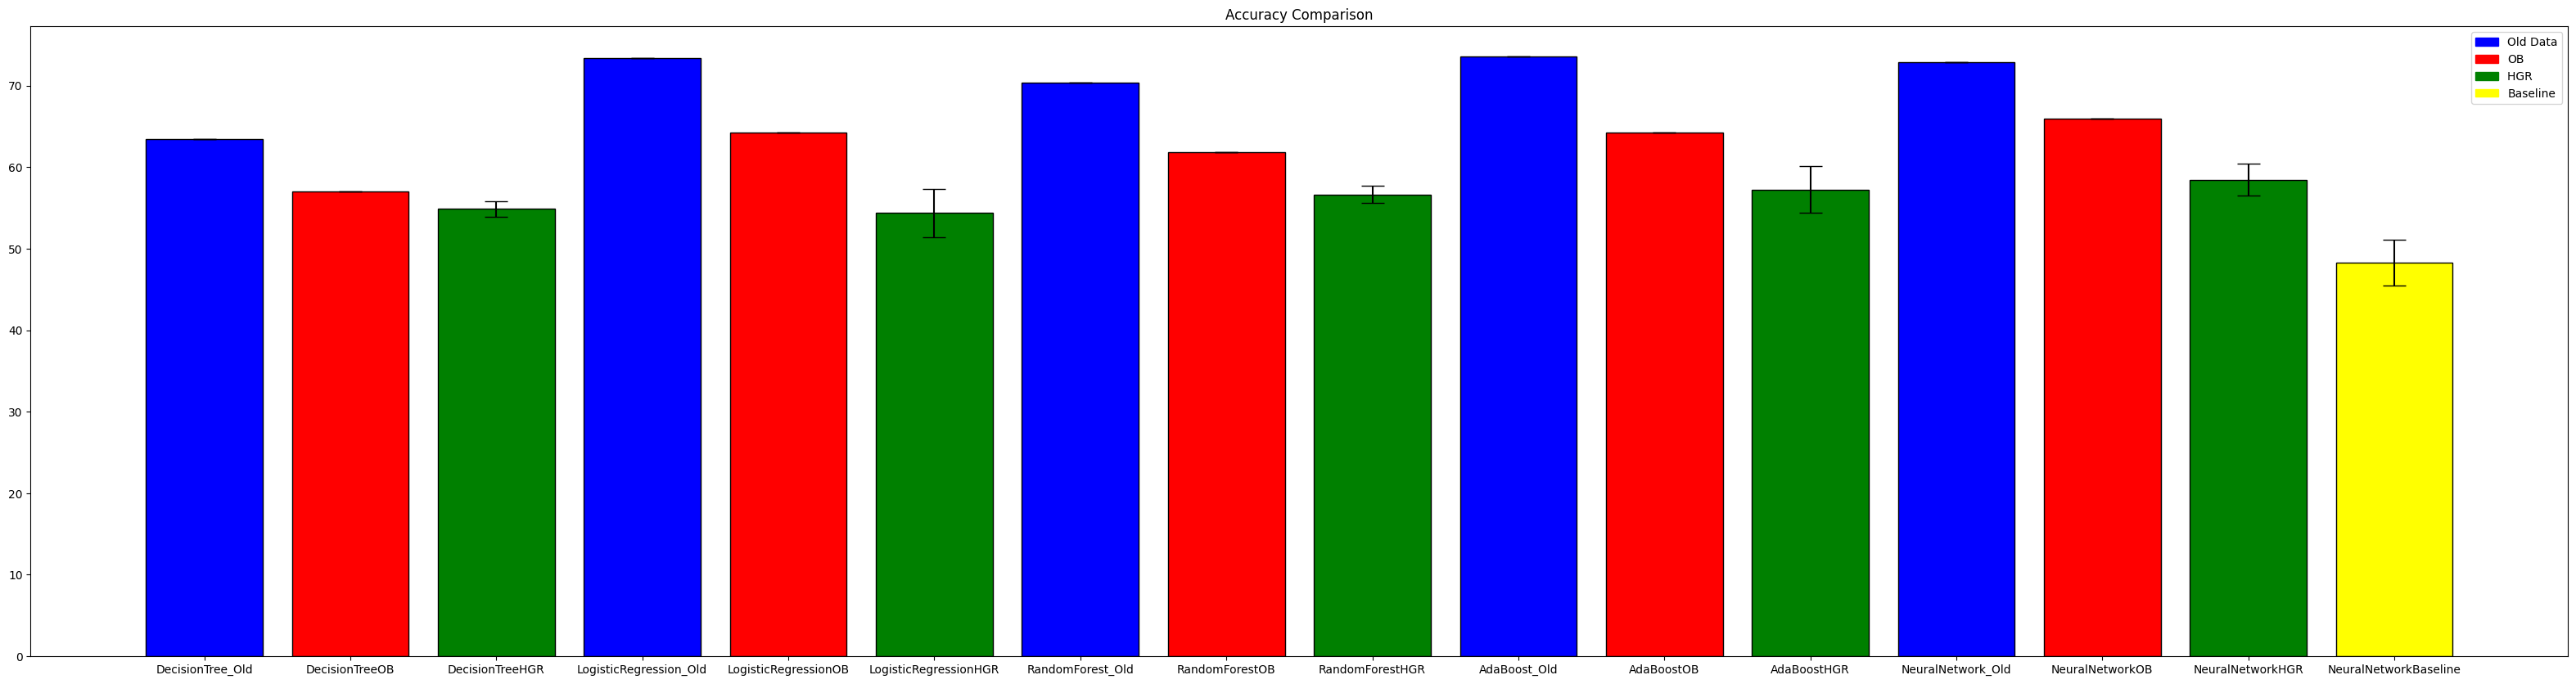

In [ ]:
#Accuracy Results 
categories = ['DecisionTree_Old', 'DecisionTreeOB', 'DecisionTreeHGR', 'LogisticRegression_Old', 'LogisticRegressionOB', 'LogisticRegressionHGR', 'RandomForest_Old', 'RandomForestOB', 'RandomForestHGR', 'AdaBoost_Old', 'AdaBoostOB', 'AdaBoostHGR', 'NeuralNetwork_Old', 'NeuralNetworkOB', 'NeuralNetworkHGR', 'NeuralNetworkBaseline']
means = [63.40, 57.00, 54.88, 73.40, 64.20, 54.38, 70.40, 61.80, 56.66, 73.60, 64.20, 57.26, 72.90, 66.00, 58.46, 48.30]
stds = [0, 0, 0.94, 0, 0, 2.93, 0, 0, 1.09, 0, 0, 2.83, 0, 0, 1.94, 2.78]
colors = ['blue'] + ['red'] + ['green'] + ['blue'] + ['red'] + ['green'] + ['blue'] + ['red'] + ['green'] + ['blue'] + ['red'] + ['green'] + ['blue'] + ['red'] + ['green'] + ['yellow']

df_accuracy = pd.DataFrame({'Accuracy': categories, 'Mean': means, 'Std': stds})

plt.figure(figsize=(40,10))
plt.bar(df_accuracy["Accuracy"], df_accuracy["Mean"], yerr=df_accuracy["Std"], capsize=10, color=colors, edgecolor="black")
blue_patch = mpatches.Patch(color="blue", label="Old Data")
red_patch = mpatches.Patch(color="red", label="OB")
green_patch = mpatches.Patch(color="green", label="HGR ")
yellow_patch = mpatches.Patch(color="yellow", label="Baseline")
plt.legend(handles=[blue_patch, red_patch, green_patch, yellow_patch])
plt.title("Accuracy Comparison")
plt.show()

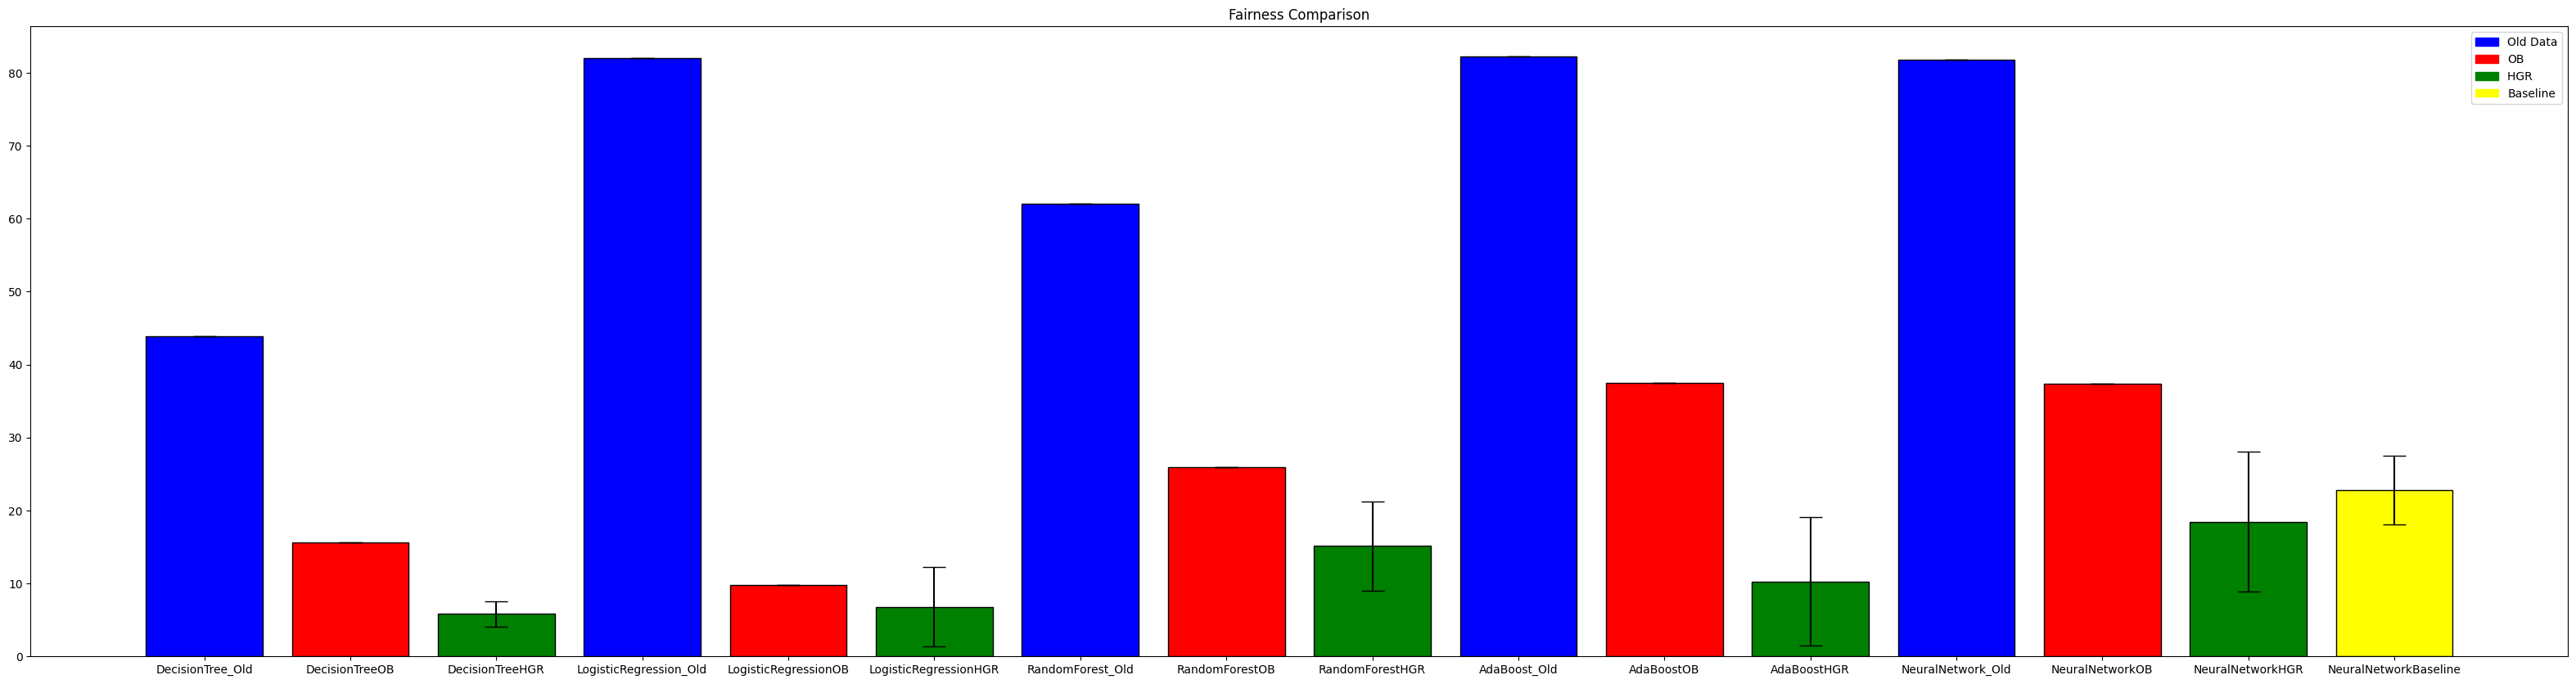

In [59]:
#Fairness Results
categories = ['DecisionTree_Old', 'DecisionTreeOB', 'DecisionTreeHGR', 'LogisticRegression_Old', 'LogisticRegressionOB', 'LogisticRegressionHGR', 'RandomForest_Old', 'RandomForestOB', 'RandomForestHGR', 'AdaBoost_Old', 'AdaBoostOB', 'AdaBoostHGR', 'NeuralNetwork_Old', 'NeuralNetworkOB', 'NeuralNetworkHGR', 'NeuralNetworkBaseline']
means = [43.89, 15.65, 5.81, 82.05, 9.76, 6.78, 62.02, 25.92, 15.11, 82.25, 37.48, 10.24, 81.77, 37.39, 18.43, 22.78]
stds = [0, 0, 1.71, 0, 0, 5.43, 0, 0, 6.07, 0, 0, 8.79, 0, 0, 9.57, 4.74]
colors = ['blue'] + ['red'] + ['green'] + ['blue'] + ['red'] + ['green'] + ['blue'] + ['red'] + ['green'] + ['blue'] + ['red'] + ['green'] + ['blue'] + ['red'] + ['green'] + ['yellow']

df_fairness = pd.DataFrame({'Fairness': categories, 'Mean': means, 'Std': stds})    

plt.figure(figsize=(40,10))
plt.bar(df_fairness["Fairness"], df_fairness["Mean"], yerr=df_fairness["Std"], capsize=10, color=colors, edgecolor="black")
blue_patch = mpatches.Patch(color="blue", label="Old Data")
red_patch = mpatches.Patch(color="red", label="OB")
green_patch = mpatches.Patch(color="green", label="HGR ")
yellow_patch = mpatches.Patch(color="yellow", label="Baseline")
plt.legend(handles=[blue_patch, red_patch, green_patch, yellow_patch])
plt.title("Fairness Comparison")
plt.show()

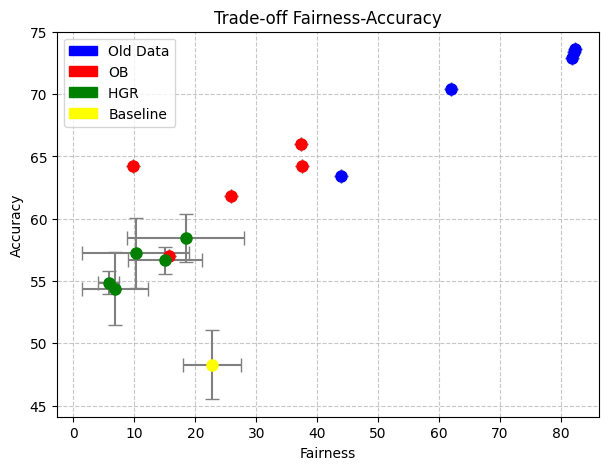

In [ ]:
#Combination results 

fairness = np.array([43.89, 15.65, 5.81, 82.05, 9.76, 6.78, 62.02, 25.92, 15.11, 82.25, 37.48, 10.24, 81.77, 37.39, 18.43, 22.78])
std_fairness = np.array([0, 0, 1.71, 0, 0, 5.43, 0, 0, 6.07, 0, 0, 8.79, 0, 0, 9.57, 4.74])
accuracy = np.array([63.40, 57.00, 54.88, 73.40, 64.20, 54.38, 70.40, 61.80, 56.66, 73.60, 64.20, 57.26, 72.90, 66.00, 58.46, 48.30])
std_accuracy = np.array([0, 0, 0.94, 0, 0, 2.93, 0, 0, 1.09, 0, 0, 2.83, 0, 0, 1.94, 2.78])
colors = ['blue'] + ['red'] + ['green'] + ['blue'] + ['red'] + ['green'] + ['blue'] + ['red'] + ['green'] + ['blue'] + ['red'] + ['green'] + ['blue'] + ['red'] + ['green'] + ['yellow']

plt.figure(figsize=(7, 5))
for i in range(len(fairness)):
    plt.errorbar(fairness[i], accuracy[i], xerr=std_fairness[i], yerr=std_accuracy[i], fmt='o', 
             ecolor='gray', capsize=5, capthick=1, markersize=8, color=colors[i])

plt.xlabel("Fairness")
plt.ylabel("Accuracy")
plt.title("Trade-off Fairness-Accuracy")

blue_patch = mpatches.Patch(color="blue", label="Old Data")
red_patch = mpatches.Patch(color="red", label="OB")
green_patch = mpatches.Patch(color="green", label="HGR ")
yellow_patch = mpatches.Patch(color="yellow", label="Baseline")
plt.legend(handles=[blue_patch, red_patch, green_patch, yellow_patch])
plt.grid(True, linestyle="--", alpha=0.7)

plt.show()


## <a id='toc7_2_'></a>[Normal Data](#toc0_)

### <a id='toc7_2_1_'></a>[Decision Tree](#toc0_)

| Metric        | Old Data      |  New Data 2 | OB   |
| ------------- | ------------- | --------------| -----------| 
| Accuracy      | 68.80     | 56.65 $\pm$ 0.83   | 57.60   |
| Accuracy-Gold | 56.20              | 51.16 $\pm$ 1.10     | 56.20 |
| AUPR          | 63.10     | 53.71 $\pm$ 0.52         | 54.41   |
| HGR           | 44.02         | 19.84 $\pm$ 4.88     | 2.22   |



### <a id='toc7_2_2_'></a>[Logistic Classifier](#toc0_)

| Metric        | Old Data      | New Data 2 |  OB       |
| ------------- | ------------- | --------------| -----------|
| Accuracy      | 76.10     | 52.54 $\pm$ 2.00         | 63.20    |
| Accuracy-Gold | 56.90           | 51.34 $\pm$ 1.17       | 60.00 |
| AUPR          | 86.22*     | 53.72 $\pm$ 1.30         | 71.25    |
| HGR           | 66.53         | 5.59 $\pm$ 3.49         | 5.85    |


### <a id='toc7_2_3_'></a>[Random Forest](#toc0_)

| Metric        | Old Data      |   New Data 2  | OB        |
| ------------- | ------------- | --------------| -----------|
| Accuracy      | 73.60     | 60.90 $\pm$ 2.27           | 60.40     |
| Accuracy Gold | 56.60              | 52.78 $\pm$ 1.50      | 57.80 |
| AUPR          | 81.91     | 64.54 $\pm$ 3.19         | 64.94     |
| HGR           | 57.86         | 27.02 $\pm$ 6.18    | 2.51    |


### <a id='toc7_2_4_'></a>[AdaBoost](#toc0_)

| Metric        | Old Data      | New Data 2 | OB       |
| ------------- | ------------- | --------------| -----------|
| Accuracy      | 77.00     | 56.54 $\pm$ 1.94        | 63.40    |
| Accuracy-Gold | 57.80              | 52.50 $\pm$ 0.91    | 60.40  |
| AUPR          | 85.11     | 57.98 $\pm$ 1.76           | 70.06   |
| HGR           | 63.19         | 15.37 $\pm$ 6.38     | 1.77   |


### <a id='toc7_2_5_'></a>[Neural Network](#toc0_)

| Metric        | Old Data      |   New Data 2 |  Baseline | OB     |
| ------------- | ------------- | --------------| ----------- | --------|
| Accuracy      | 76.30     | 60.60 $\pm$ 2.67    | 49.82 $\pm$ 0.75    | 63.10  |
| Accuracy-Gold | 57.10              | 53.48 $\pm$ 0.96    | 50.18 $\pm$ 1.21    | 59.90 |
| AUPR          | 86.07     | 63.18 $\pm$ 3.90    | -     | 74.02  |
| HGR           | 66.10         | 26.85  $\pm$ 7.61      | 10.08 $\pm$ 1.37   | 6.58  |

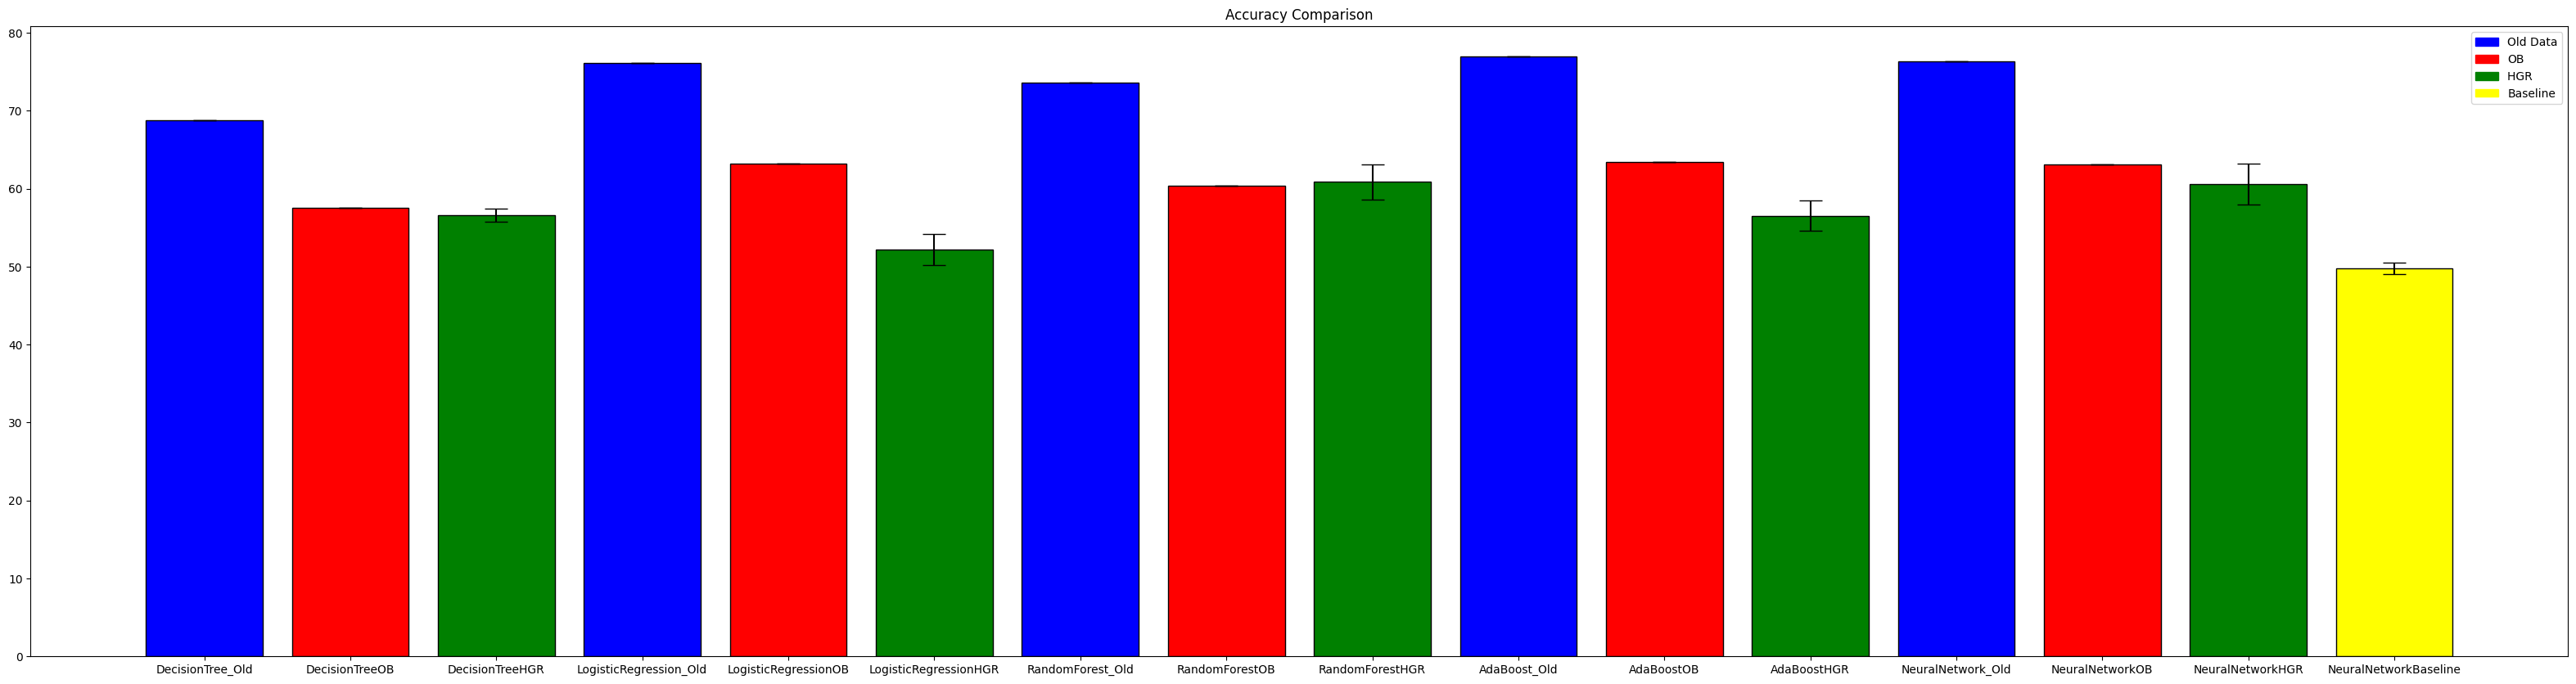

In [ ]:
#Accuracy Results 
categories = ['DecisionTree_Old', 'DecisionTreeOB', 'DecisionTreeHGR', 'LogisticRegression_Old', 'LogisticRegressionOB', 'LogisticRegressionHGR', 'RandomForest_Old', 'RandomForestOB', 'RandomForestHGR', 'AdaBoost_Old', 'AdaBoostOB', 'AdaBoostHGR', 'NeuralNetwork_Old', 'NeuralNetworkOB', 'NeuralNetworkHGR', 'NeuralNetworkBaseline']
means = np.array([68.80, 57.60, 56.65, 76.10, 63.20, 52.24, 73.60, 60.40, 60.90, 77.00, 63.40, 56.54, 76.30, 63.10, 60.60, 49.82])
stds = np.array([0, 0, 0.83, 0, 0, 2.00, 0, 0, 2.27, 0, 0, 1.94, 0, 0, 2.67, 0.75])
colors = ['blue'] + ['red'] + ['green'] + ['blue'] + ['red'] + ['green'] + ['blue'] + ['red'] + ['green'] + ['blue'] + ['red'] + ['green'] + ['blue'] + ['red'] + ['green'] + ['yellow']

df_accuracy = pd.DataFrame({'Accuracy': categories, 'Mean': means, 'Std': stds})

plt.figure(figsize=(40,10))
plt.bar(df_accuracy["Accuracy"], df_accuracy["Mean"], yerr=df_accuracy["Std"], capsize=10, color=colors, edgecolor="black")
blue_patch = mpatches.Patch(color="blue", label="Old Data")
red_patch = mpatches.Patch(color="red", label="OB")
green_patch = mpatches.Patch(color="green", label="HGR ")
yellow_patch = mpatches.Patch(color="yellow", label="Baseline")
plt.legend(handles=[blue_patch, red_patch, green_patch, yellow_patch])
plt.title("Accuracy Comparison")
plt.show()

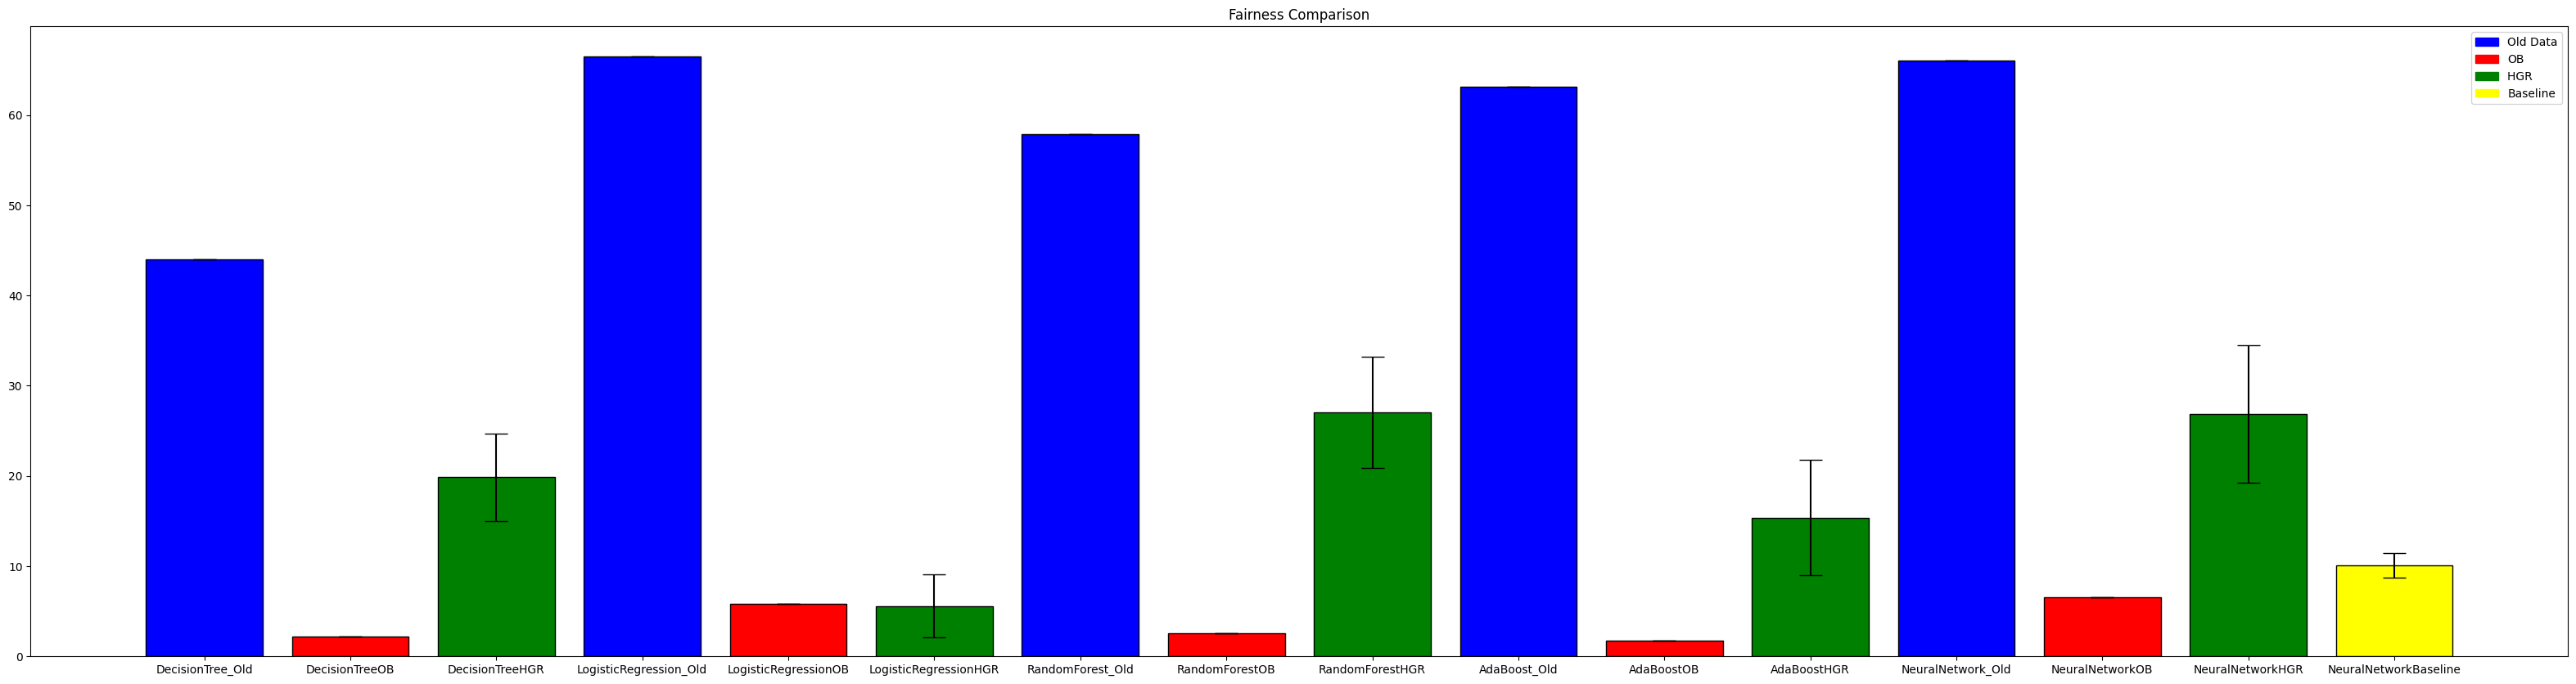

In [58]:
#Fairness Results
categories = ['DecisionTree_Old', 'DecisionTreeOB', 'DecisionTreeHGR', 'LogisticRegression_Old', 'LogisticRegressionOB', 'LogisticRegressionHGR', 'RandomForest_Old', 'RandomForestOB', 'RandomForestHGR', 'AdaBoost_Old', 'AdaBoostOB', 'AdaBoostHGR', 'NeuralNetwork_Old', 'NeuralNetworkOB', 'NeuralNetworkHGR', 'NeuralNetworkBaseline']
means = np.array([44.02, 2.22, 19.84, 66.53, 5.85, 5.59, 57.86, 2.51, 27.02, 63.19, 1.77, 15.37, 66.10, 6.58, 26.85, 10.08])
stds = np.array([0, 0, 4.88, 0, 0, 3.49, 0, 0, 6.18, 0, 0, 6.38, 0, 0, 7.61, 1.37])
colors = ['blue'] + ['red'] + ['green'] + ['blue'] + ['red'] + ['green'] + ['blue'] + ['red'] + ['green'] + ['blue'] + ['red'] + ['green'] + ['blue'] + ['red'] + ['green'] + ['yellow']

df_fairness = pd.DataFrame({'Fairness': categories, 'Mean': means, 'Std': stds})    

plt.figure(figsize=(40,10))
plt.bar(df_fairness["Fairness"], df_fairness["Mean"], yerr=df_fairness["Std"], capsize=10, color=colors, edgecolor="black")
blue_patch = mpatches.Patch(color="blue", label="Old Data")
red_patch = mpatches.Patch(color="red", label="OB")
green_patch = mpatches.Patch(color="green", label="HGR ")
yellow_patch = mpatches.Patch(color="yellow", label="Baseline")
plt.legend(handles=[blue_patch, red_patch, green_patch, yellow_patch])
plt.title("Fairness Comparison")
plt.show()

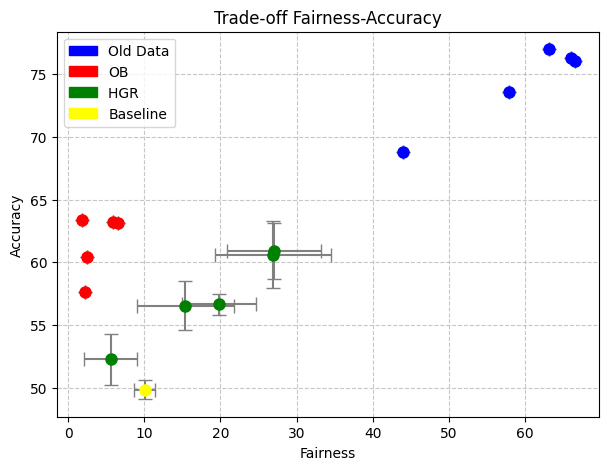

In [ ]:
#Combination results 

fairness = np.array([44.02, 2.22, 19.84, 66.53, 5.85, 5.59, 57.86, 2.51, 27.02, 63.19, 1.77, 15.37, 66.10, 6.58, 26.85, 10.08])
std_fairness = np.array([0, 0, 4.88, 0, 0, 3.49, 0, 0, 6.18, 0, 0, 6.38, 0, 0, 7.61, 1.37])
accuracy = np.array([68.80, 57.60, 56.65, 76.10, 63.20, 52.24, 73.60, 60.40, 60.90, 77.00, 63.40, 56.54, 76.30, 63.10, 60.60, 49.82])
std_accuracy = np.array([0, 0, 0.83, 0, 0, 2.00, 0, 0, 2.27, 0, 0, 1.94, 0, 0, 2.67, 0.75])
colors = ['blue'] + ['red'] + ['green'] + ['blue'] + ['red'] + ['green'] + ['blue'] + ['red'] + ['green'] + ['blue'] + ['red'] + ['green'] + ['blue'] + ['red'] + ['green'] + ['yellow']

plt.figure(figsize=(7, 5))
for i in range(len(fairness)):
    plt.errorbar(fairness[i], accuracy[i], xerr=std_fairness[i], yerr=std_accuracy[i], fmt='o', 
             ecolor='gray', capsize=5, capthick=1, markersize=8, color=colors[i])

plt.xlabel("Fairness")
plt.ylabel("Accuracy")
plt.title("Trade-off Fairness-Accuracy")

blue_patch = mpatches.Patch(color="blue", label="Old Data")
red_patch = mpatches.Patch(color="red", label="OB")
green_patch = mpatches.Patch(color="green", label="HGR ")
yellow_patch = mpatches.Patch(color="yellow", label="Baseline")
plt.legend(handles=[blue_patch, red_patch, green_patch, yellow_patch])
plt.grid(True, linestyle="--", alpha=0.7)

plt.show()


# <a id='toc8_'></a>[SOME CONSIDERATIONS AND FURTHER IMPROVMENTS](#toc0_)

### <a id='toc8_1_1_'></a>[HGR approach](#toc0_)
Regarding the HGR approach to the problem, I found that the main issue lies in the high instability of the training process. After conducting several experiments and modifying the hyperparameter configuration, particularly the batch size, I am convinced that this instability is primarily due to the actual computation of HGR rather than the choice of hyperparameters or the model architecture.
For instance, the training becomes more stable when I adjust the HGR computation by reducing the kernel degree (effectively reverting to Pearson's coefficient). However, this significantly degrades performance.
Possible future directions for this approach include:
- Experimenting with models other than neural networks, such as XGBoost.
- Implementing a Dual Ascent training strategy to avoid fixing the $\lambda$ value.
- Enhancing the stability of HGR computation while preserving its fundamental non-linearity.
- Testing it on Real-Data

### <a id='toc8_1_2_'></a>[OB approach](#toc0_)

Regarding the OB approach to the problem, we can see that it is most effective under the assumption of joint-normal correlation, as expected. In fact, according to its definition, the OB approach works perfectly for linear dependencies but fails to capture non-linear ones. Therefore, although it is much more stable compared to the HGR approach, it may not perform well in the presence of non-linear dependencies.

In [8]:
%reload_ext tensorboard
%tensorboard --logdir=lightning_logs/ --port=6005

Reusing TensorBoard on port 6005 (pid 15356), started 0:00:03 ago. (Use '!kill 15356' to kill it.)